# Project: Water Quality Prediction

## Project Overview

This project analyzes a water-quality dataset to predict whether a water sample is classified as safe or unsafe. The dataset contains physicochemical water-quality indicators such as pH, iron, nitrate, chloride, lead, turbidity, fluoride, copper, sulfate, conductivity, chlorine, manganese, total dissolved solids, water temperature, air temperature, and categorical source information.

The target variable is `Target`, where:

- `0` represents Safe water
- `1` represents Unsafe water

The project combines data cleaning, exploratory data analysis, domain knowledge, statistical interpretation, and machine learning models to identify important predictors of unsafe water quality.

## Research Objective

The main objective of this project is to investigate which variables are most important for predicting the dataset's `Target` variable. Rather than claiming legal drinking-water certification or causal effects, this project focuses on predictive relationships between water-quality indicators and the safe/unsafe classification.

Specifically, the project aims to:

- clean and prepare the raw water-quality dataset;
- explore variable distributions and differences between safe and unsafe samples;
- examine possible relationships among physicochemical variables;
- train and compare multiple machine learning models;
- evaluate model performance using consistent classification metrics;
- identify important predictors using model coefficients, tree-based feature importance, and permutation importance.

## Dataset

The dataset used in this project is the Water Quality Prediction dataset from Kaggle.

The raw dataset is stored in:

`../data/raw/Water Quality Prediction.csv`

The cleaned dataset used for modeling is stored in:

`../data/processed/water_quality_cleaned.csv`

The dataset includes both numerical variables and categorical variables. The categorical variable `Source` describes the type of water source, while the numerical variables describe chemical, physical, and environmental water-quality characteristics.

## Models Used

This project compares several supervised classification models:

1. **Logistic Regression**

   Used as an interpretable linear baseline model. Interaction features and hyperparameter tuning are also included.

2. **Decision Tree**

   Used as a non-linear single-tree model and as a baseline for comparison with ensemble models.

3. **K-Nearest Neighbors**

   Used as a distance-based classification model after feature scaling.

4. **Neural Network**

   Used as a non-linear model with class weighting and early stopping.

5. **Ensemble Models**

   Random Forest and HistGradientBoosting are used to represent bagging and boosting approaches. These models are also used for feature-importance analysis.

## Evaluation Metrics

Because the target variable is a binary classification problem and unsafe water is the more important class from a public-health perspective, the models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In the final comparison table, precision, recall, and F1-score refer to the positive class, where `Target = 1` means Unsafe water.

## Notebook Structure

This merged notebook follows the full project workflow:

1. **Data Cleaning**

   Load the raw dataset, inspect missing values, handle invalid or unreasonable values, and save the cleaned dataset.

2. **Exploratory Data Analysis**

   Explore distributions, target balance, relationships between variables, categorical patterns, correlations, and outliers.

3. **Logistic Regression**

   Train baseline and tuned Logistic Regression models, including interaction features and coefficient-based interpretation.

4. **Decision Tree**

   Train and tune a Decision Tree model, evaluate performance, and analyze feature importance.

5. **K-Nearest Neighbors**

   Train and tune a KNN classifier, including feature scaling and full test-set evaluation.

6. **Neural Network**

   Train a neural network with early stopping and class weighting, followed by feature-importance analysis.

7. **Ensemble Models**

   Train Random Forest and HistGradientBoosting models, perform light hyperparameter tuning, compare bagging and boosting methods, and analyze feature importance.

8. **Final Model Comparison**

   Combine the results from all models into one standardized comparison table.

## Important Interpretation Note

A model trained on this dataset predicts the dataset's `Target` variable. It does not certify that a water sample is legally potable under WHO, EU, or national drinking-water regulations. Some important drinking-water indicators are not included in the dataset, and the sampling context is not fully specified. Therefore, model results should be interpreted as predictive evidence within this dataset rather than as a formal drinking-water safety assessment.

## Project Team Contribution and Workload Distribution

| Team Member | Main Coding Responsibilities | Additional Responsibilities | Main Deliverables |
|---|---|---|---|
| **Yue Lu** | Data Cleaning; Decision Tree; Model Comparison | Result checking; consistency verification | Cleaned dataset; tree baseline; comparison results |
| **Fan Yang** | EDA; K-Nearest Neighbors | Interaction checking; slide preparation | EDA findings; KNN results; interaction analysis |
| **Xueying Peng** | Logistic Regression; Neural Network | Final version checking; slide preparation | Logistic model; neural network; final delivery version |
| **Yanyi Ji** | Random Forest; HistGradientBoosting | Domain knowledge; code standardization; slide preparation | Ensemble results; feature interpretation; integrated notebook；reproducibility checks |

## 0. Global Imports and Project Setup


In [24]:
# Global imports
import json
import itertools
import os
import time
import warnings
from itertools import combinations
from pathlib import Path

import random
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from IPython.display import display

from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight

try:
    from tqdm import tqdm
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "tqdm", "--quiet"])
    from tqdm import tqdm

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

In [25]:
# Shared project configuration
PROJECT_ROOT = Path("..").resolve()
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
RESULT_DIR = PROJECT_ROOT / "reports" / "model_results"

for directory in [DATA_RAW_DIR, DATA_PROCESSED_DIR, FIGURE_DIR, RESULT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
POS_LABEL = 1

# Fix random states for Python, NumPy, and TensorFlow
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Project root:", PROJECT_ROOT)
print("Target convention: 1 = Unsafe, 0 = Safe")

Project root: D:\桌面
Target convention: 1 = Unsafe, 0 = Safe


## 1. Data Cleaning

This section prepares the raw water-quality dataset for exploratory data analysis and machine learning modeling. The main purpose of data cleaning is to ensure that the dataset is consistent, usable, and suitable for later statistical analysis.

The cleaning process includes:

- loading the raw Kaggle dataset;
- checking the dataset shape, column names, data types, and missing values;
- identifying unreasonable or invalid values;
- handling missing values in numerical, categorical, and time-related variables;
- checking duplicate rows;
- saving the cleaned dataset for later EDA and modeling steps.

The raw dataset is loaded from:

`../data/raw/Water Quality Prediction.csv`

After cleaning, the processed dataset is saved as:

`../data/processed/water_quality_cleaned.csv`

This cleaned file is used consistently in the following EDA and modeling sections.

### Import raw data


In [26]:
# Display all columns
pd.set_option('display.max_columns', None)
df = pd.read_csv("./data/raw/Water Quality Prediction.csv")

print(df.head())

   Index        pH      Iron   Nitrate    Chloride           Lead      Zinc  \
0      0  8.332988  0.000083  8.605777  122.799772   3.710000e-52  3.434827   
1      1  6.917863  0.000081  3.734167  227.029851   7.850000e-94  1.245317   
2      2  5.443762  0.020106  3.816994  230.995630   5.290000e-76  0.528280   
3      3  7.955339  0.143988  8.224944  178.129940  4.000000e-176  4.027879   
4      4  8.091909  0.002167  9.925788  186.540872  4.170000e-132  3.807511   

            Color  Turbidity  Fluoride    Copper      Odor     Sulfate  \
0       Colorless   0.022683  0.607283  0.144599  1.626212   87.266538   
1    Faint Yellow   0.019007  0.622874  0.437835  1.686049  144.010981   
2    Light Yellow   0.319956  0.423423  0.431588  3.414619  275.702107   
3  Near Colorless   0.166319  0.208454  0.239451       NaN  147.163233   
4    Light Yellow   0.004867  0.222912  0.616574  0.795310  175.275175   

   Conductivity  Chlorine     Manganese  Total Dissolved Solids  Source  \
0    

In [27]:
os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

### Dataset Info


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 24 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Index                   1048575 non-null  int64  
 1   pH                      1028344 non-null  float64
 2   Iron                    1041584 non-null  float64
 3   Nitrate                 1029880 non-null  float64
 4   Chloride                1017741 non-null  float64
 5   Lead                    1043891 non-null  float64
 6   Zinc                    1020900 non-null  float64
 7   Color                   1047594 non-null  str    
 8   Turbidity               1039881 non-null  float64
 9   Fluoride                1015357 non-null  float64
 10  Copper                  1013693 non-null  float64
 11  Odor                    1017243 non-null  float64
 12  Sulfate                 1014050 non-null  float64
 13  Conductivity            1019772 non-null  float64
 14  Chlorine     

In [29]:
# Delete Index, because it's useless
df = df.drop(columns=["Index"])
print(f"Shape after dropping Index: {df.shape}")

Shape after dropping Index: (1048575, 23)


In [30]:
df

,pH,Iron,Nitrate,Chloride,Lead,Zinc,Color,Turbidity,Fluoride,Copper,Odor,Sulfate,Conductivity,Chlorine,Manganese,Total Dissolved Solids,Source,Water Temperature,Air Temperature,Month,Day,Time of Day,Target
0,8.332988,8.350000e-05,8.605777,122.799772,3.710000e-52,3.434827,Colorless,0.022683,0.607283,0.144599,1.626212,87.266538,471.683357,3.708178,2.270000e-15,332.118789,NaN,NaN,43.493324,January,29.0,4.0,0
1,6.917863,8.050000e-05,3.734167,227.029851,7.850000e-94,1.245317,Faint Yellow,0.019007,0.622874,0.437835,1.686049,144.010981,432.844908,3.292038,8.020000e-07,284.641984,Lake,15.348981,71.220586,November,26.0,16.0,0
2,5.443762,2.010586e-02,3.816994,230.995630,5.290000e-76,0.528280,Light Yellow,0.319956,0.423423,0.431588,3.414619,275.702107,990.201209,3.560224,7.007989e-02,570.054094,River,11.643467,44.891330,January,31.0,8.0,0
3,7.955339,1.439878e-01,8.224944,178.129940,4.000000e-176,4.027879,Near Colorless,0.166319,0.208454,0.239451,NaN,147.163233,237.028468,3.516907,2.468295e-02,100.043838,Ground,10.092392,60.843233,April,1.0,21.0,0
4,8.091909,2.167128e-03,9.925788,186.540872,4.170000e-132,3.807511,Light Yellow,0.004867,0.222912,0.616574,0.795310,175.275175,385.025855,3.177849,3.296139e-03,168.075545,Spring,15.249416,69.336671,June,29.0,7.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,8.186428,1.977157e-02,5.968850,115.963429,1.590000e-113,2.277221,Near Colorless,0.020610,1.194165,0.006663,3.149487,43.969084,227.409325,2.718928,2.603963e-02,220.571485,Stream,5.491908,43.817452,March,15.0,14.0,0
1048571,8.046225,1.160000e-05,3.678714,148.053168,5.930000e-25,0.483369,Near Colorless,0.878835,1.203689,0.171610,0.894528,74.133056,124.828663,2.312058,4.427830e-02,406.095969,Lake,10.143768,34.626853,December,16.0,0.0,0
1048572,7.443582,3.103077e-03,7.893399,174.677900,1.080000e-15,1.461659,Near Colorless,0.701053,0.115412,0.641379,3.150154,201.977606,337.630357,3.410297,2.350000e-05,439.086461,Spring,14.612881,55.460415,June,18.0,16.0,0
1048573,6.897232,6.980000e-10,5.757980,125.564223,1.300000e-18,0.804589,Near Colorless,0.156424,0.554729,0.018875,1.997442,204.391754,569.077747,2.803234,3.220000e-19,278.051032,Well,7.351956,65.055864,May,5.0,3.0,0


In [31]:
# Target distribution
target_pct = (
    df["Target"]
    .value_counts(normalize=True)
    * 100
)

print(target_pct)

Target
0    77.041795
1    22.958205
Name: proportion, dtype: float64


### Missing Value


In [32]:
# Overview of missing value
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %":     (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print(missing)

                        Missing Count  Missing %
Copper                          34882       3.33
Sulfate                         34525       3.29
Fluoride                        33218       3.17
Odor                            31332       2.99
Chloride                        30834       2.94
Water Temperature               29688       2.83
Conductivity                    28803       2.75
Zinc                            27675       2.64
Time of Day                     20361       1.94
pH                              20231       1.93
Manganese                       19339       1.84
Nitrate                         18695       1.78
Day                             17549       1.67
Month                           16921       1.61
Source                          15535       1.48
Chlorine                        10162       0.97
Turbidity                        8694       0.83
Iron                             6991       0.67
Air Temperature                  5303       0.51
Lead                

#### Analysis of Missing Time Variables

This dataset records water quality measurements, not a time series for forecasting.
Before deciding how to handle missing values in Month / Day / Time of Day,
we first assess whether these variables carry predictive signal.

* **Month** — marginally relevant: summer heat promotes algal growth and rainy seasons
  increase surface runoff. However, this is a synthetic Kaggle dataset, so seasonal
  effects may not be genuine.
* **Day** — nearly meaningless: water quality on the 1st and 15th of a month has no
  systematic difference. This is simply a sampling timestamp.
* **Time of Day** — very weak signal: morning vs. afternoon differences in light/temperature
  are already captured by Water Temperature and Air Temperature, making Time of Day
  largely redundant.


In [33]:
# Check rows where Month is missing
missing_month = df[df["Month"].isna()]
print(f"Number of rows with missing Month: {len(missing_month)}")
print(missing_month.head(10))

Number of rows with missing Month: 16921
           pH          Iron   Nitrate    Chloride           Lead      Zinc  \
95   8.274538  1.967803e-02  3.905648  199.219252   3.170000e-91  0.608931   
185  8.498952  2.130000e-05  6.326846  215.696563   1.330000e-95  2.996623   
321  6.994089  2.617884e-02  3.224344  202.636520   1.730000e-14  4.353077   
348  7.782071  1.180000e-08  8.204868  203.324549  2.870000e-113  0.434184   
371  7.213041  2.108476e-01  4.202989  159.003847  3.940000e-140  1.542676   
423  7.796400  2.362215e-02  5.684404  145.418616   3.670000e-27  1.244731   
543       NaN  7.805703e-03  4.634547  109.515217   5.680000e-05  1.412661   
589  7.682119  8.900000e-07  4.745942  116.771918   1.130000e-10  3.579267   
590  6.535819  4.938256e-03  2.720528  164.570384   2.570000e-44  2.739641   
611  7.025332  8.170000e-12  3.583202  147.512488   1.650000e-93  0.033050   

              Color  Turbidity  Fluoride    Copper      Odor     Sulfate  \
95     Faint Yellow   0.

In [34]:
# Check rows where at least one time column is missing (same batch?)
missing_time = df[df["Month"].isna() | df["Day"].isna() | df["Time of Day"].isna()]
print(f"Rows with at least one missing time field: {len(missing_time)}")

# Missing pattern: do all three columns go missing together?
print("\nMissing combination counts:")
print(missing_time[["Month", "Day", "Time of Day"]].isnull().value_counts())

Rows with at least one missing time field: 53916

Missing combination counts:
Month  Day    Time of Day
False  False  True           19732
       True   False          16927
True   False  False          16347
False  True   True             336
True   False  True             288
       True   False            281
              True               5
Name: count, dtype: int64


In [35]:
# Check whether other columns are also missing in these rows
# (is this a systematic / structural missingness?)
print("Overall missing counts for rows with missing time fields:")
print(missing_time.isnull().sum())

Overall missing counts for rows with missing time fields:
pH                         1062
Iron                        345
Nitrate                     986
Chloride                   1586
Lead                        244
Zinc                       1477
Color                        50
Turbidity                   470
Fluoride                   1740
Copper                     1741
Odor                       1585
Sulfate                    1743
Conductivity               1449
Chlorine                    551
Manganese                  1033
Total Dissolved Solids       15
Source                      798
Water Temperature          1453
Air Temperature             255
Month                     16921
Day                       17549
Time of Day               20361
Target                        0
dtype: int64


In [36]:
# Check Source distribution in rows with missing time fields
# to see whether missingness is concentrated in one source type
print("Source distribution in rows with missing time fields:")
print(missing_time["Source"].value_counts(dropna=False))

# Compare against the full dataset's Source distribution
print("\nSource distribution in the full dataset:")
print(df["Source"].value_counts(dropna=False))

Source distribution in rows with missing time fields:
Source
Ground       6727
Aquifer      6708
Well         6667
Spring       6648
River        6636
Lake         6601
Stream       6598
Reservoir    6533
NaN           798
Name: count, dtype: int64

Source distribution in the full dataset:
Source
Well         129654
Aquifer      129609
Stream       129574
Ground       129433
River        128978
Lake         128637
Reservoir    128582
Spring       128573
NaN           15535
Name: count, dtype: int64


#### Missing Time Variables — Findings

Based on the analysis above, the missingness in the three time fields is **random (MAR)**,
not systematic. The Source distribution in rows with missing time values mirrors the full
dataset, confirming there is no structural bias.

The chemical indicators in these rows show only minor missingness (e.g., pH 1 062 / 53 916 = 2%),
so a missing time field does not indicate that the entire row is low quality.

**Imputation strategy:** random sampling from the observed values of each time column.
This preserves the empirical distribution without introducing the bias that a fixed
median value would create (median imputation would artificially inflate the frequency
of a single value — e.g., making day 16 appear far more often than it truly is).


In [37]:
# Validate correlation between time variables and Target
# Month → numeric (1-12)
month_map = {
    "January": 1, "February": 2, "March": 3,
    "April": 4,   "May": 5,      "June": 6,
    "July": 7,    "August": 8,   "September": 9,
    "October": 10,"November": 11,"December": 12
}
df["Month"] = df["Month"].map(month_map)

# Correlation with Target
time_corr = df[["Month", "Day", "Time of Day", "Target"]].corr()["Target"].drop("Target")
print("Correlation between time variables and Target:")
print(time_corr.round(4))

Correlation between time variables and Target:
Month          0.0001
Day           -0.0003
Time of Day   -0.0014
Name: Target, dtype: float64


#### Time Variable Correlation Results

All three time variables show correlation with Target below 0.05,
confirming they are sampling records rather than meaningful predictors of water quality.
We proceed with random imputation to fill missing values.


#### Missing Values in Categorical Variables

There are only two categorical variables: Color and Source.
Imputing either with a mode or a placeholder category would be logically unsound —
inventing a water source or colour that was not recorded distorts the data.

* Source: 15 535 missing rows — missing rate ≈ 1.48 %
* Color: 981 missing rows — missing rate ≈ 0.09 %

Both rates are low, so we simply drop those rows.


In [38]:
# Fill missing time variables using reproducible random sampling
# The empirical distribution is preserved while the result remains reproducible.
time_cols = ["Month", "Day", "Time of Day"]
rng_time = np.random.default_rng(RANDOM_STATE)

for col in time_cols:
    n_missing = df[col].isna().sum()

    if n_missing > 0:
        observed = df[col].dropna().to_numpy()

        fill_values = rng_time.choice(
            observed,
            size=n_missing,
            replace=True
        )

        df.loc[df[col].isna(), col] = fill_values
        print(f"{col}: filled {n_missing:,} missing values by random sampling")
    else:
        print(f"{col}: no missing values")

# Drop rows where Color or Source is missing
before = len(df)
df = df.dropna(subset=["Color", "Source"])
after = len(df)

print(
    f"\nDropped rows with missing Color / Source: "
    f"{before:,} → {after:,} (lost {before-after:,} rows)"
)

Month: filled 16,921 missing values by random sampling
Day: filled 17,549 missing values by random sampling
Time of Day: filled 20,361 missing values by random sampling

Dropped rows with missing Color / Source: 1,048,575 → 1,032,071 (lost 16,504 rows)


In [39]:
# Count remaining missing values per column
missing_values = df.isna().sum()
print(missing_values)

pH                        19924
Iron                       6876
Nitrate                   18417
Chloride                  30340
Lead                       4616
Zinc                      27241
Color                         0
Turbidity                  8559
Fluoride                  32690
Copper                    34285
Odor                      30833
Sulfate                   33991
Conductivity              28362
Chlorine                   9985
Manganese                 19026
Total Dissolved Solids      294
Source                        0
Water Temperature         29202
Air Temperature            5220
Month                         0
Day                           0
Time of Day                   0
Target                        0
dtype: int64


#### Missing Values in Numerical Variables

The dataset contains over 1 million rows. Dropping rows with missing numerical values
is cleaner than imputing them — it avoids introducing artificial bias into chemical
measurements that should reflect real sensor readings.


In [40]:
# Drop rows with any remaining missing values (numerical columns)
before = len(df)
df = df.dropna()
after = len(df)
print(f"Dropped rows with missing numerical values: {before:,} → {after:,} (lost {before-after:,} rows)")

Dropped rows with missing numerical values: 1,032,071 → 739,148 (lost 292,923 rows)


#### Remove Unreasonable Temperature Values

Water temperature outside the range **4 °C – 211 °C** is physically implausible
for any water quality monitoring context and most likely reflects sensor errors
or data entry mistakes. Rows outside this range are dropped.
The same filter is applied to Air Temperature for consistency.


In [41]:
# Remove rows with physically implausible temperature values
TEMP_MIN, TEMP_MAX = 4, 211

before = len(df)

df = df[
    (df["Water Temperature"] >= TEMP_MIN) & (df["Water Temperature"] <= TEMP_MAX) &
    (df["Air Temperature"]   >= TEMP_MIN) & (df["Air Temperature"]   <= TEMP_MAX)
]

after = len(df)
print(f"Temperature filter ({TEMP_MIN}–{TEMP_MAX} °C):")
print(f"  Rows before : {before:,}")
print(f"  Rows removed: {before - after:,}")
print(f"  Rows after  : {after:,}")
print(f"\nWater Temperature range after filter: "
      f"{df['Water Temperature'].min():.2f} – {df['Water Temperature'].max():.2f}")
print(f"Air Temperature range after filter  : "
      f"{df['Air Temperature'].min():.2f} – {df['Air Temperature'].max():.2f}")

Temperature filter (4–211 °C):
  Rows before : 739,148
  Rows removed: 4,392
  Rows after  : 734,756

Water Temperature range after filter: 4.00 – 210.82
Air Temperature range after filter  : 4.00 – 144.08


In [42]:
# Final validation
assert df.isnull().sum().sum() == 0, "Still has missing values!"

print(f" Cleaning complete")
print(f"Original row count : 1,048,575")
print(f"Cleaned row count  : {len(df):,}")
print(f"Retention rate     : {len(df)/1048575*100:.1f}%")
print(f"\nTarget distribution (after cleaning):")
print(df["Target"].value_counts())
print(df["Target"].value_counts(normalize=True).round(3))
print(f"\nFinal columns ({len(df.columns)}):")
print(df.columns.tolist())

 Cleaning complete
Original row count : 1,048,575
Cleaned row count  : 734,756
Retention rate     : 70.1%

Target distribution (after cleaning):
Target
0    565630
1    169126
Name: count, dtype: int64
Target
0    0.77
1    0.23
Name: proportion, dtype: float64

Final columns (23):
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Source', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day', 'Target']


#### Cleaning Result

Target distribution: 0.77 vs 0.23, consistent with the raw data.
This confirms that the drop operations did not introduce sampling bias —
the cleaning process was effectively random with respect to the target variable.


In [43]:
# Save cleaned dataset
df.to_csv("../data/processed/water_quality_cleaned.csv", index=False)
print("Saved → data/processed/water_quality_cleaned.csv")

Saved → data/processed/water_quality_cleaned.csv


## 2. Exploratory Data Analysis

This section explores the cleaned water-quality dataset before model building. The purpose of EDA is to understand the structure of the data, examine the distribution of the target variable, identify important patterns, and detect potential issues that may affect later modeling.

The EDA focuses on the following aspects:

- the overall size and structure of the cleaned dataset;
- the distribution of the target variable (`Safe` vs. `Unsafe`);
- summary statistics of numerical water-quality variables;
- distributions of key physicochemical indicators;
- relationships between predictors and the target variable;
- correlations among numerical variables;
- patterns in categorical variables such as `Color` and `Source`;
- potential outliers and their possible influence on modeling.

The findings from this section help guide later feature interpretation and model comparison. In particular, EDA provides initial evidence about which variables may be more strongly associated with unsafe water, while also showing that no single predictor fully explains the target.

In [44]:
df = pd.read_csv("../data/processed/water_quality_cleaned.csv")
os.makedirs("../reports/figures", exist_ok=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (734756, 23)


,pH,Iron,Nitrate,Chloride,Lead,Zinc,Color,Turbidity,Fluoride,Copper,Odor,Sulfate,Conductivity,Chlorine,Manganese,Total Dissolved Solids,Source,Water Temperature,Air Temperature,Month,Day,Time of Day,Target
0,6.917863,8.050000e-05,3.734167,227.029851,7.850000e-94,1.245317,Faint Yellow,0.019007,0.622874,0.437835,1.686049,144.010981,432.844908,3.292038,8.020000e-07,284.641984,Lake,15.348981,71.220586,11.0,26.0,16.0,0
1,5.443762,2.010586e-02,3.816994,230.995630,5.290000e-76,0.528280,Light Yellow,0.319956,0.423423,0.431588,3.414619,275.702107,990.201209,3.560224,7.007989e-02,570.054094,River,11.643467,44.891330,1.0,31.0,8.0,0
2,8.091909,2.167128e-03,9.925788,186.540872,4.170000e-132,3.807511,Light Yellow,0.004867,0.222912,0.616574,0.795310,175.275175,385.025855,3.177849,3.296139e-03,168.075545,Spring,15.249416,69.336671,6.0,29.0,7.0,0
3,7.258203,6.110000e-09,9.261676,182.242341,4.400000e-224,0.416478,Colorless,0.047803,1.016196,0.298093,3.144199,114.551427,160.062557,2.325094,6.020000e-16,214.553104,River,15.891905,61.139140,4.0,11.0,4.0,0
4,7.100650,3.019038e-03,3.620641,157.043934,6.460000e-148,0.112994,Colorless,0.050613,0.842107,0.391602,2.713379,167.417837,583.295321,2.284971,8.840000e-07,113.909077,River,11.899376,14.010268,4.0,7.0,12.0,0


#### Missing value check


In [45]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values")

✅ No missing values


#### Target distribution


In [46]:
print(df["Target"].value_counts())
print(df["Target"].value_counts(normalize=True).round(3))

Target
0    565630
1    169126
Name: count, dtype: int64
Target
0    0.77
1    0.23
Name: proportion, dtype: float64


In [47]:
print("The comparision of mean values of target：")
key_cols = ["pH", "Iron", "Turbidity", "Fluoride", "Copper",
            "Lead", "Nitrate", "Chloride", "Odor", "Manganese"]
print(df.groupby("Target")[key_cols].mean().T.round(4))

The comparision of mean values of target：
Target            0         1
pH           7.4644    7.3971
Iron         0.0707    0.2597
Turbidity    0.3717    0.8601
Fluoride     0.8649    1.1975
Copper       0.4243    0.7279
Lead         0.0006    0.0037
Nitrate      5.7817    7.0690
Chloride   174.2523  207.4406
Odor         1.6807    2.0866
Manganese    0.0461    0.2538


All pollutant indicators are significantly higher when Target = 1, and the conclusion is clear:

Target = 1 → Unsafe (problematic water quality)

Target = 0 → Safe (normal water quality)


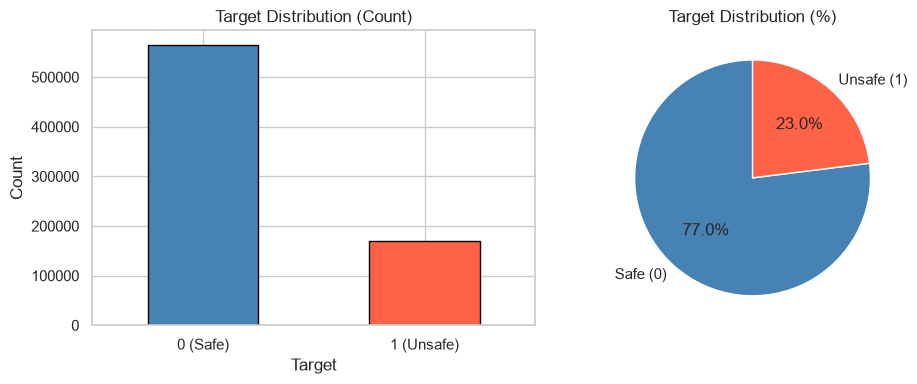

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
df["Target"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Target Distribution (Count)")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["0 (Safe)", "1 (Unsafe)"], rotation=0)

# Pie chart
df["Target"].value_counts().plot(kind="pie", ax=axes[1], labels=["Safe (0)", "Unsafe (1)"],
                                  autopct="%1.1f%%", colors=["steelblue", "tomato"], startangle=90)
axes[1].set_ylabel("")
axes[1].set_title("Target Distribution (%)")

plt.tight_layout()
plt.savefig("../reports/figures/target_distribution.png", dpi=150)
plt.show()

In [49]:
# Define the numerical and categorical parameters
numerical_cols = ["pH", "Iron", "Nitrate", "Chloride", "Lead", "Zinc",
                  "Turbidity", "Fluoride", "Copper", "Odor", "Sulfate",
                  "Conductivity", "Chlorine", "Manganese", "Total Dissolved Solids",
                  "Water Temperature", "Air Temperature", "Day", "Time of Day", "Month"]

categorical_cols = ["Color", "Source"]

print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numerical features: 20
Categorical features: 2


In [50]:
# Description statistics
df[numerical_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
pH,734756.0,7.449,0.848,2.058,6.915,7.453,8.001,12.892
Iron,734756.0,0.114,0.443,0.000,0.000,0.002,0.050,15.749
Nitrate,734756.0,6.078,3.131,0.286,3.950,5.566,7.587,69.731
Chloride,734756.0,181.892,65.802,29.413,137.424,174.748,215.699,1430.549
Lead,734756.0,0.001,0.030,0.000,0.000,0.000,0.000,3.504
Zinc,734756.0,1.529,1.504,0.000,0.414,1.075,2.216,28.369
Turbidity,734756.0,0.484,0.864,0.000,0.037,0.200,0.593,19.296
Fluoride,734756.0,0.941,0.793,0.000,0.370,0.766,1.318,12.852
Copper,734756.0,0.494,0.567,0.000,0.126,0.339,0.679,10.717
Odor,734756.0,1.774,1.051,0.011,0.879,1.746,2.613,4.142


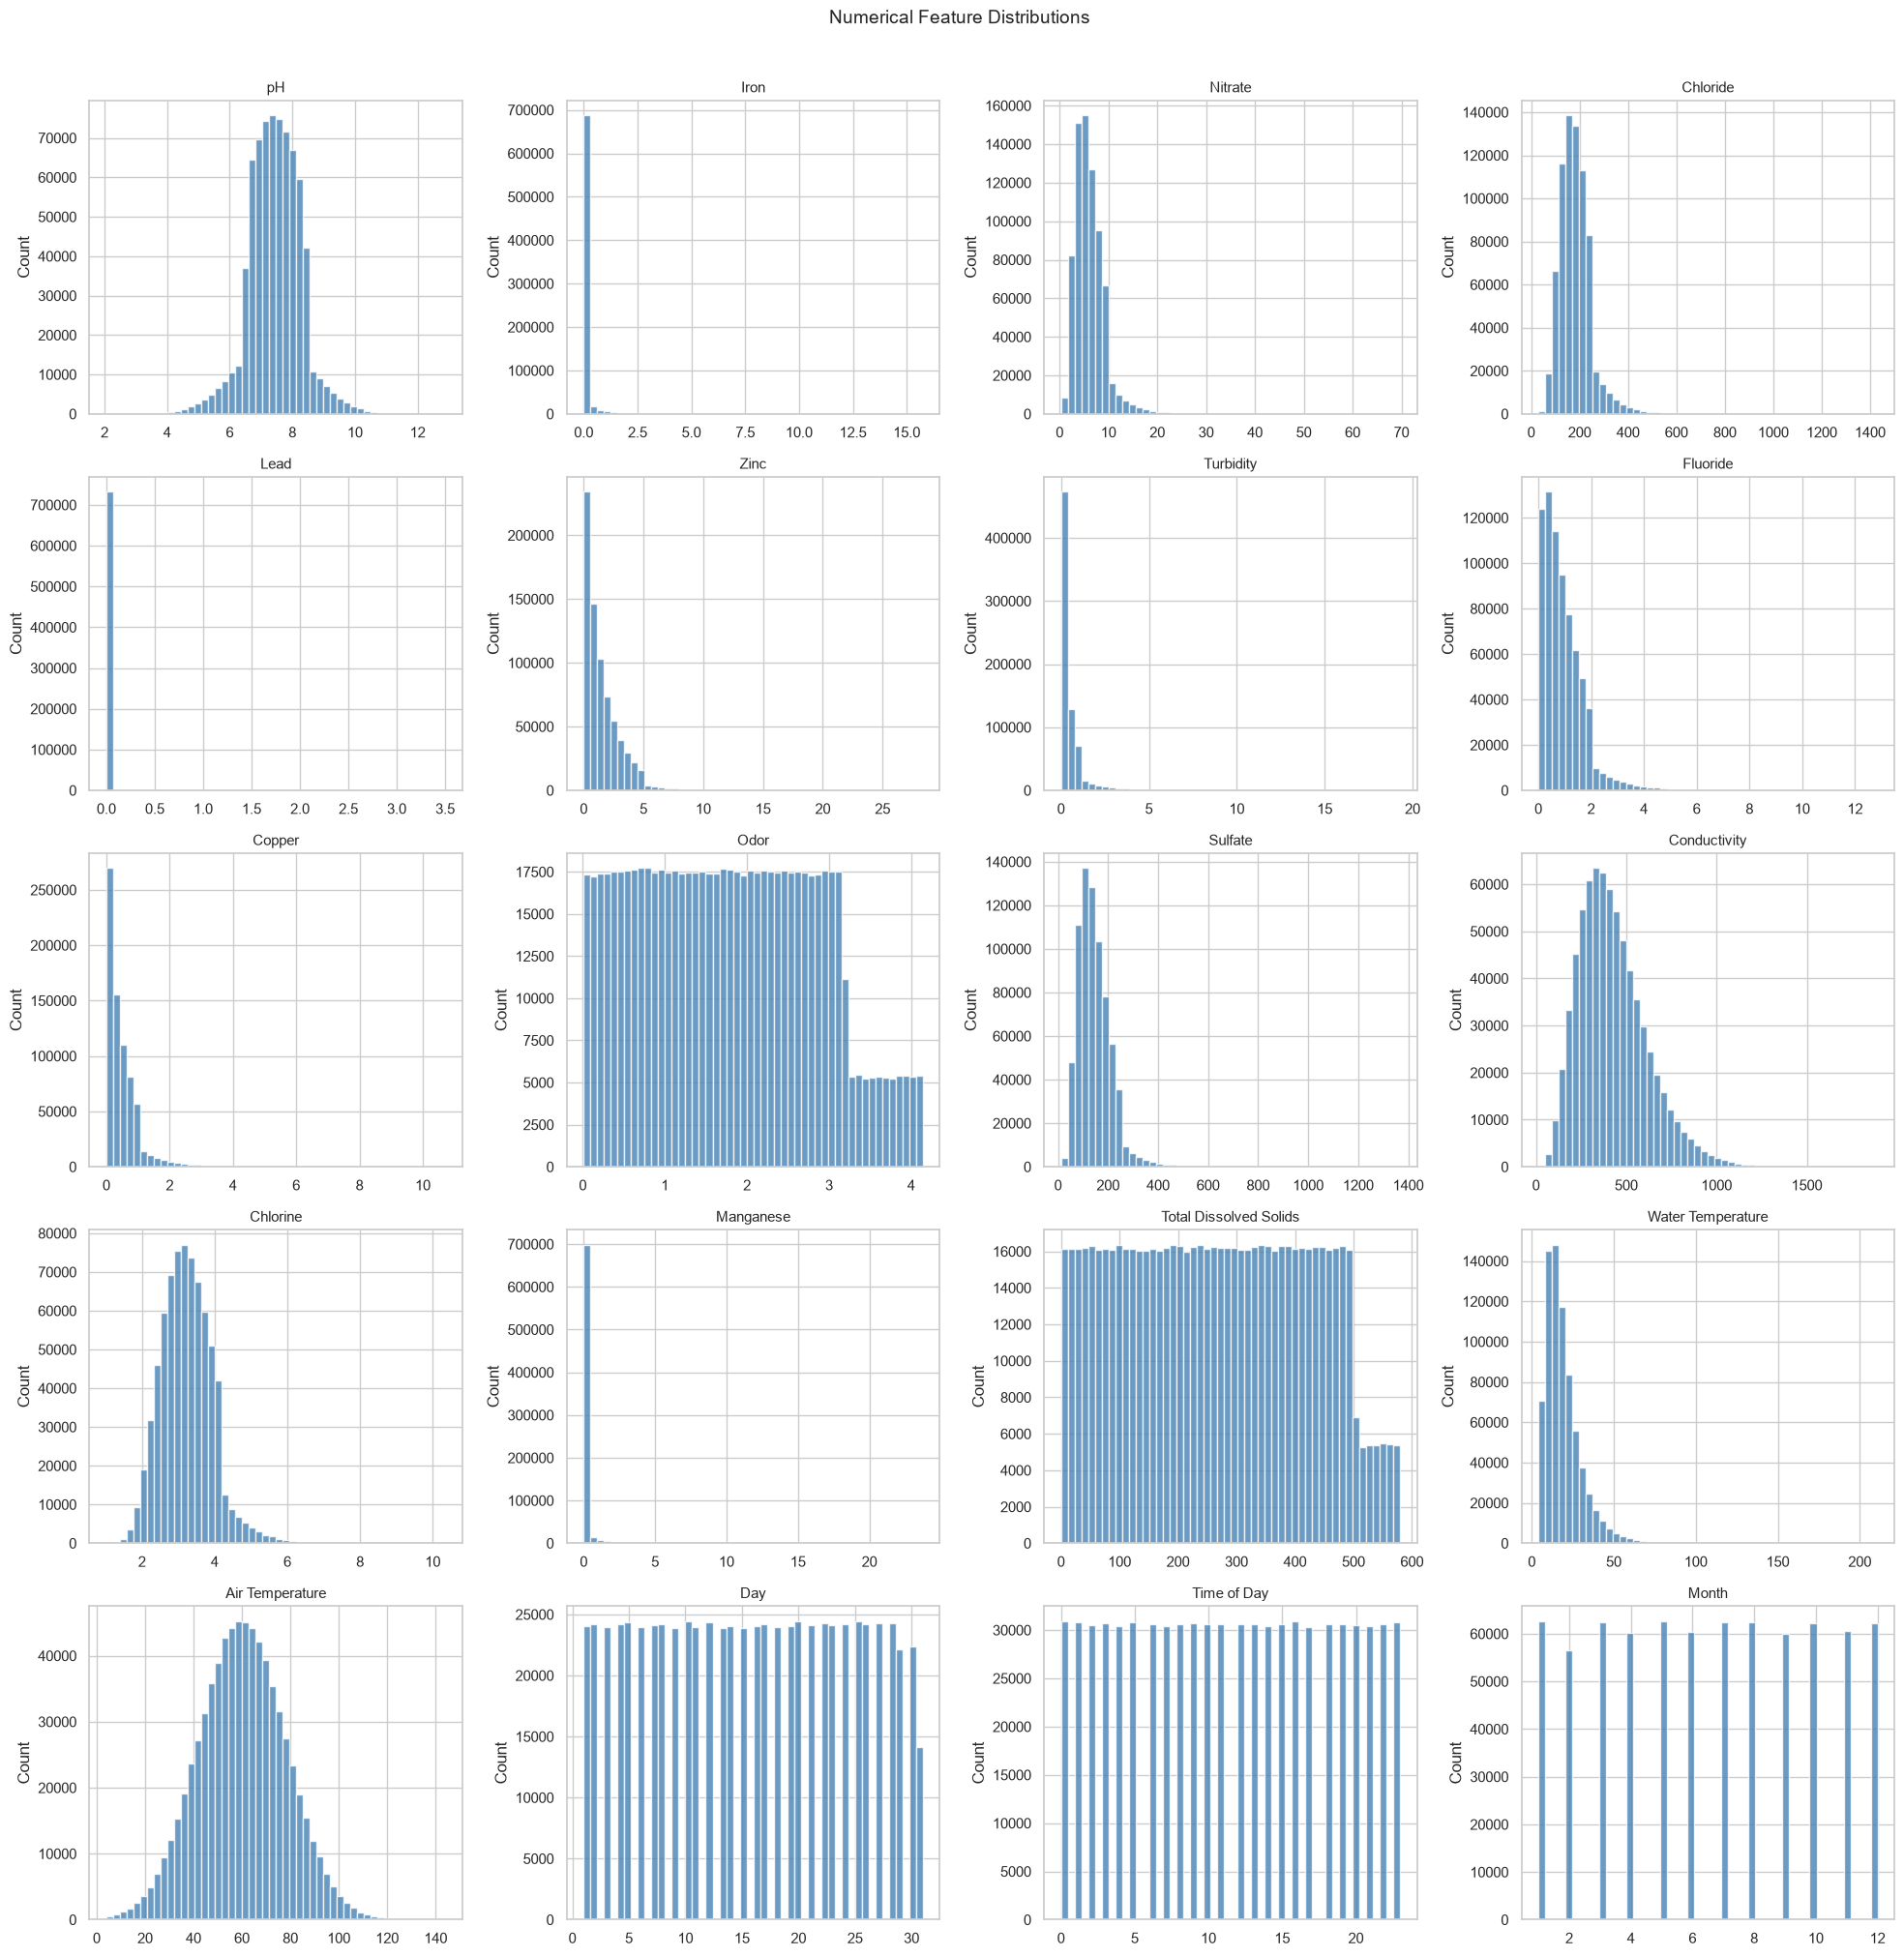

In [51]:
# Plotting distributions for all numerical variables (Histogram)
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Hide extra subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numerical Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/numerical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

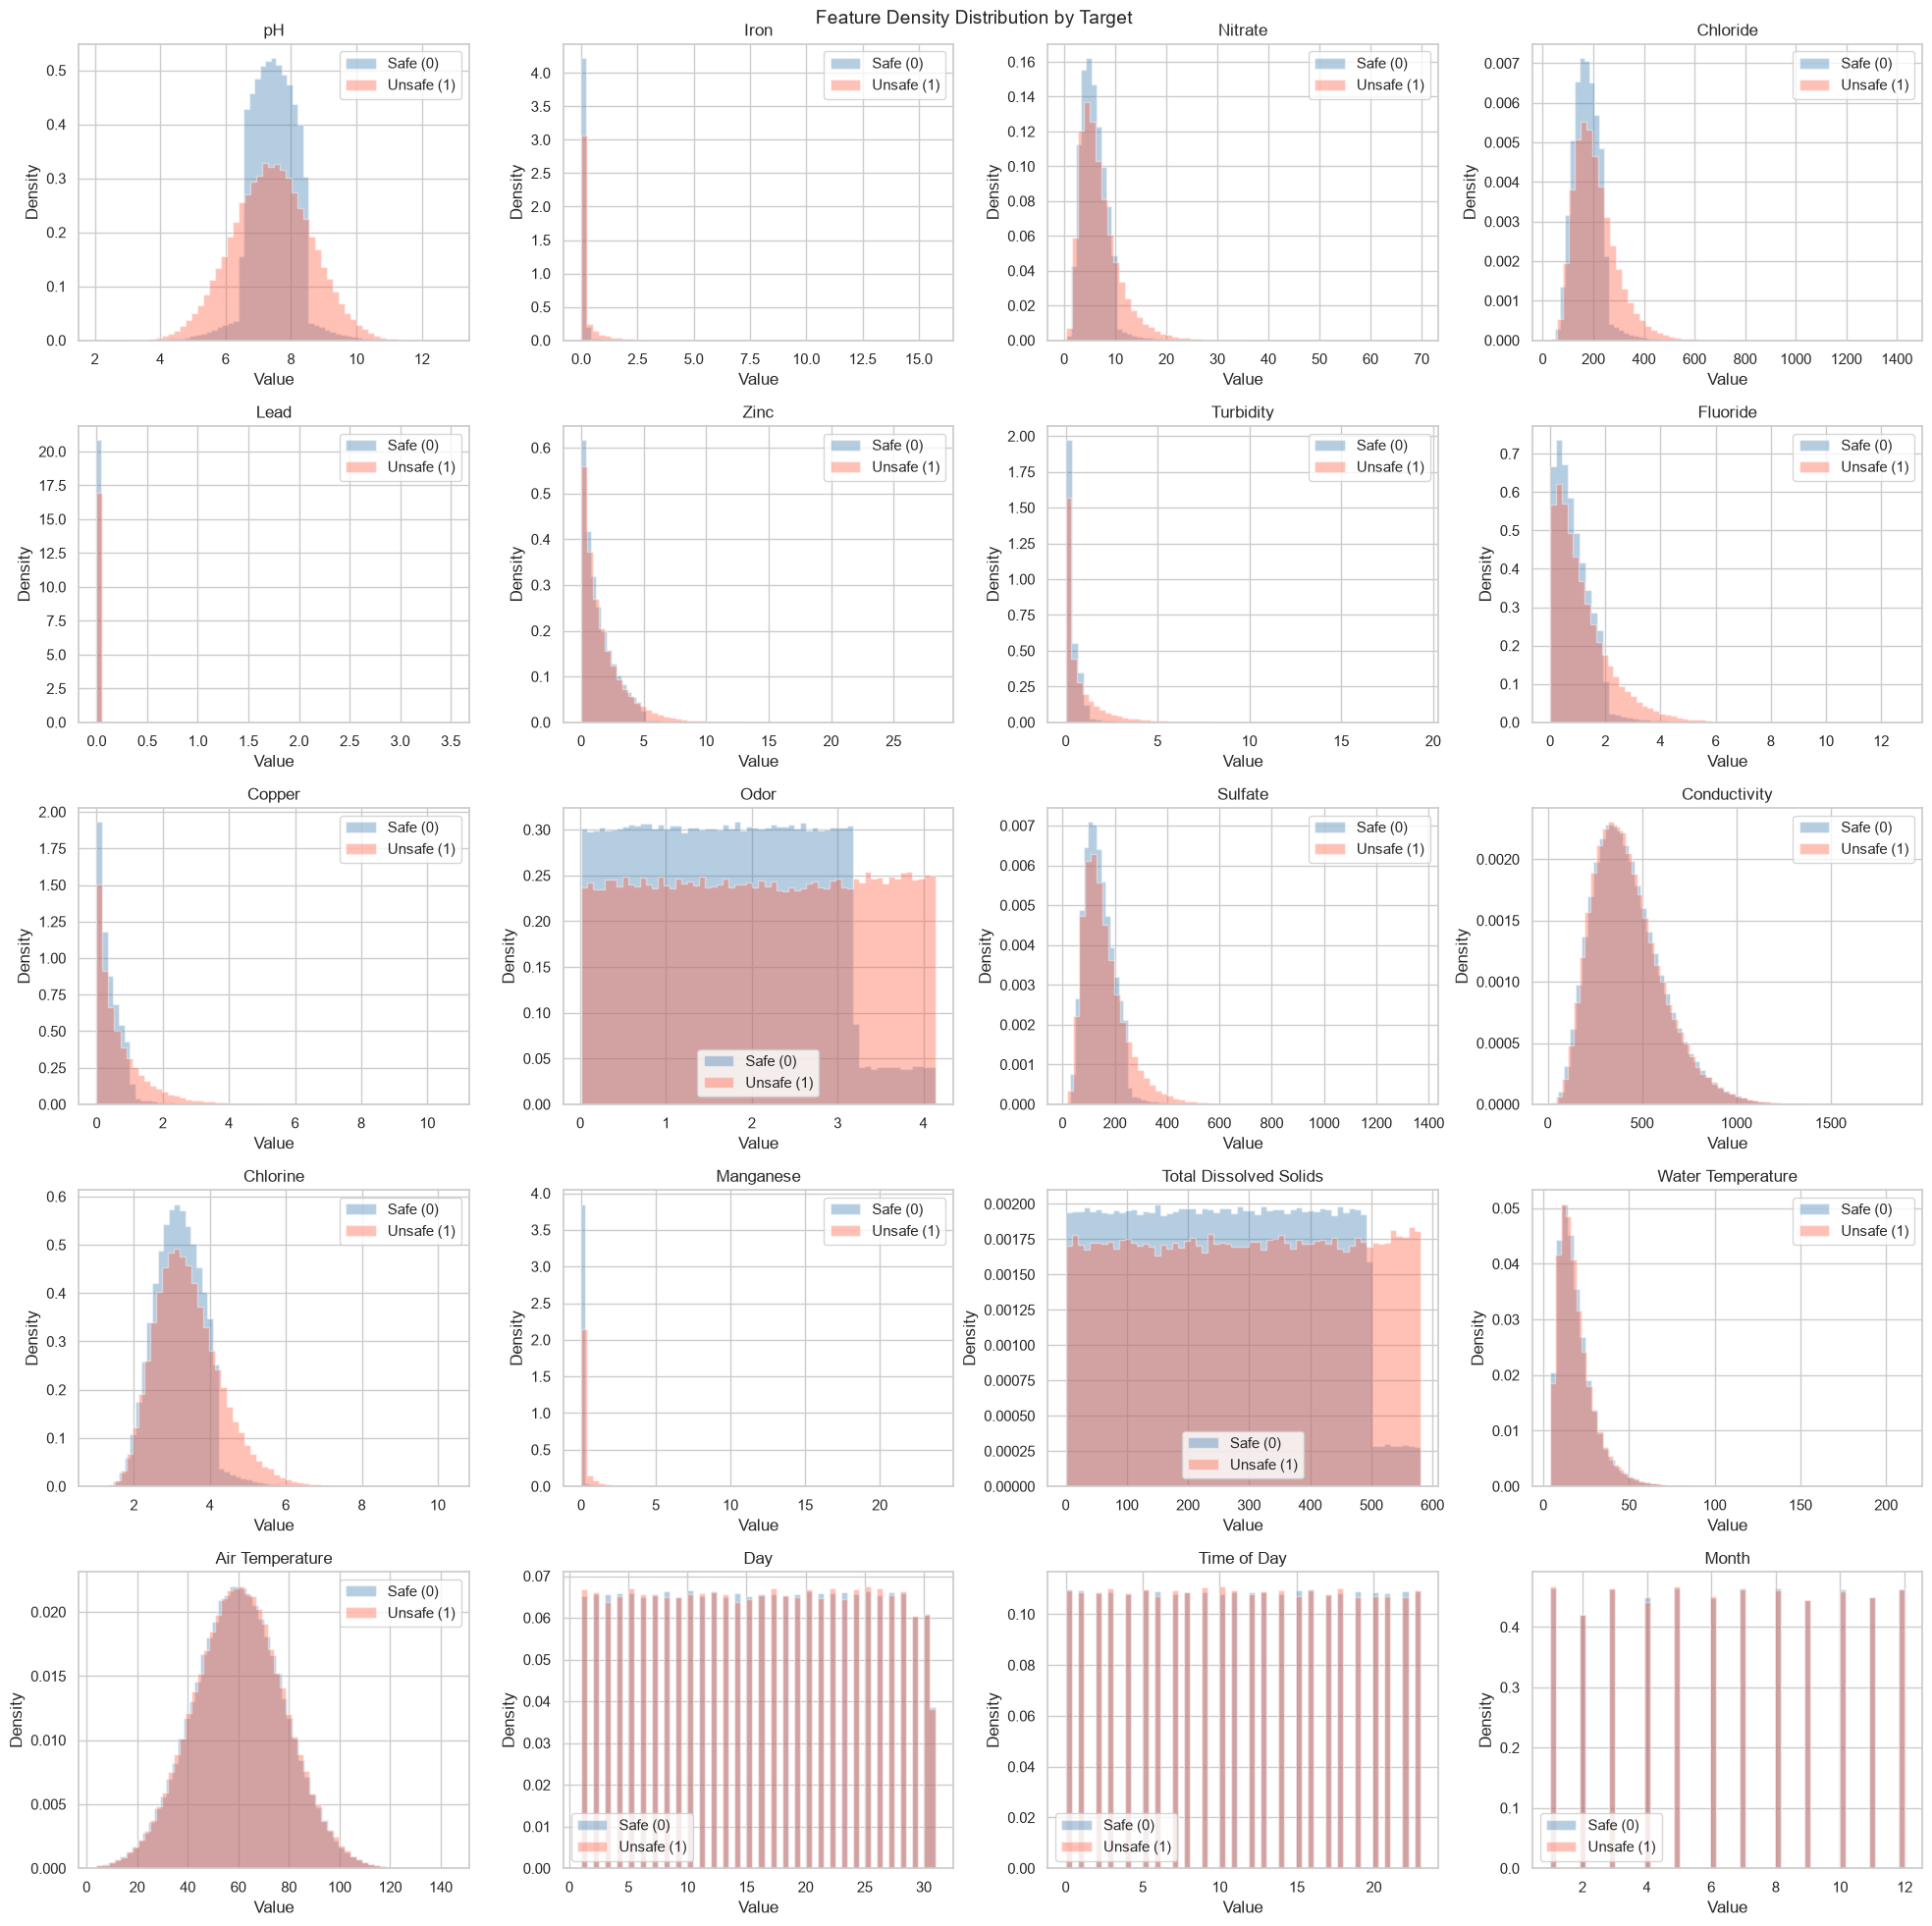

In [52]:
# The Histogram by different targets, can witness the influence of parameters directly.
safe   = df[df['Target'] == 0]
unsafe = df[df['Target'] == 1]
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(safe[col],   bins=60, density=True, histtype='stepfilled',
                 alpha=0.4, color='steelblue', label='Safe (0)')
    axes[i].hist(unsafe[col], bins=60, density=True, histtype='stepfilled',
                 alpha=0.4, color='tomato',    label='Unsafe (1)')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Feature Density Distribution by Target', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/kde_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

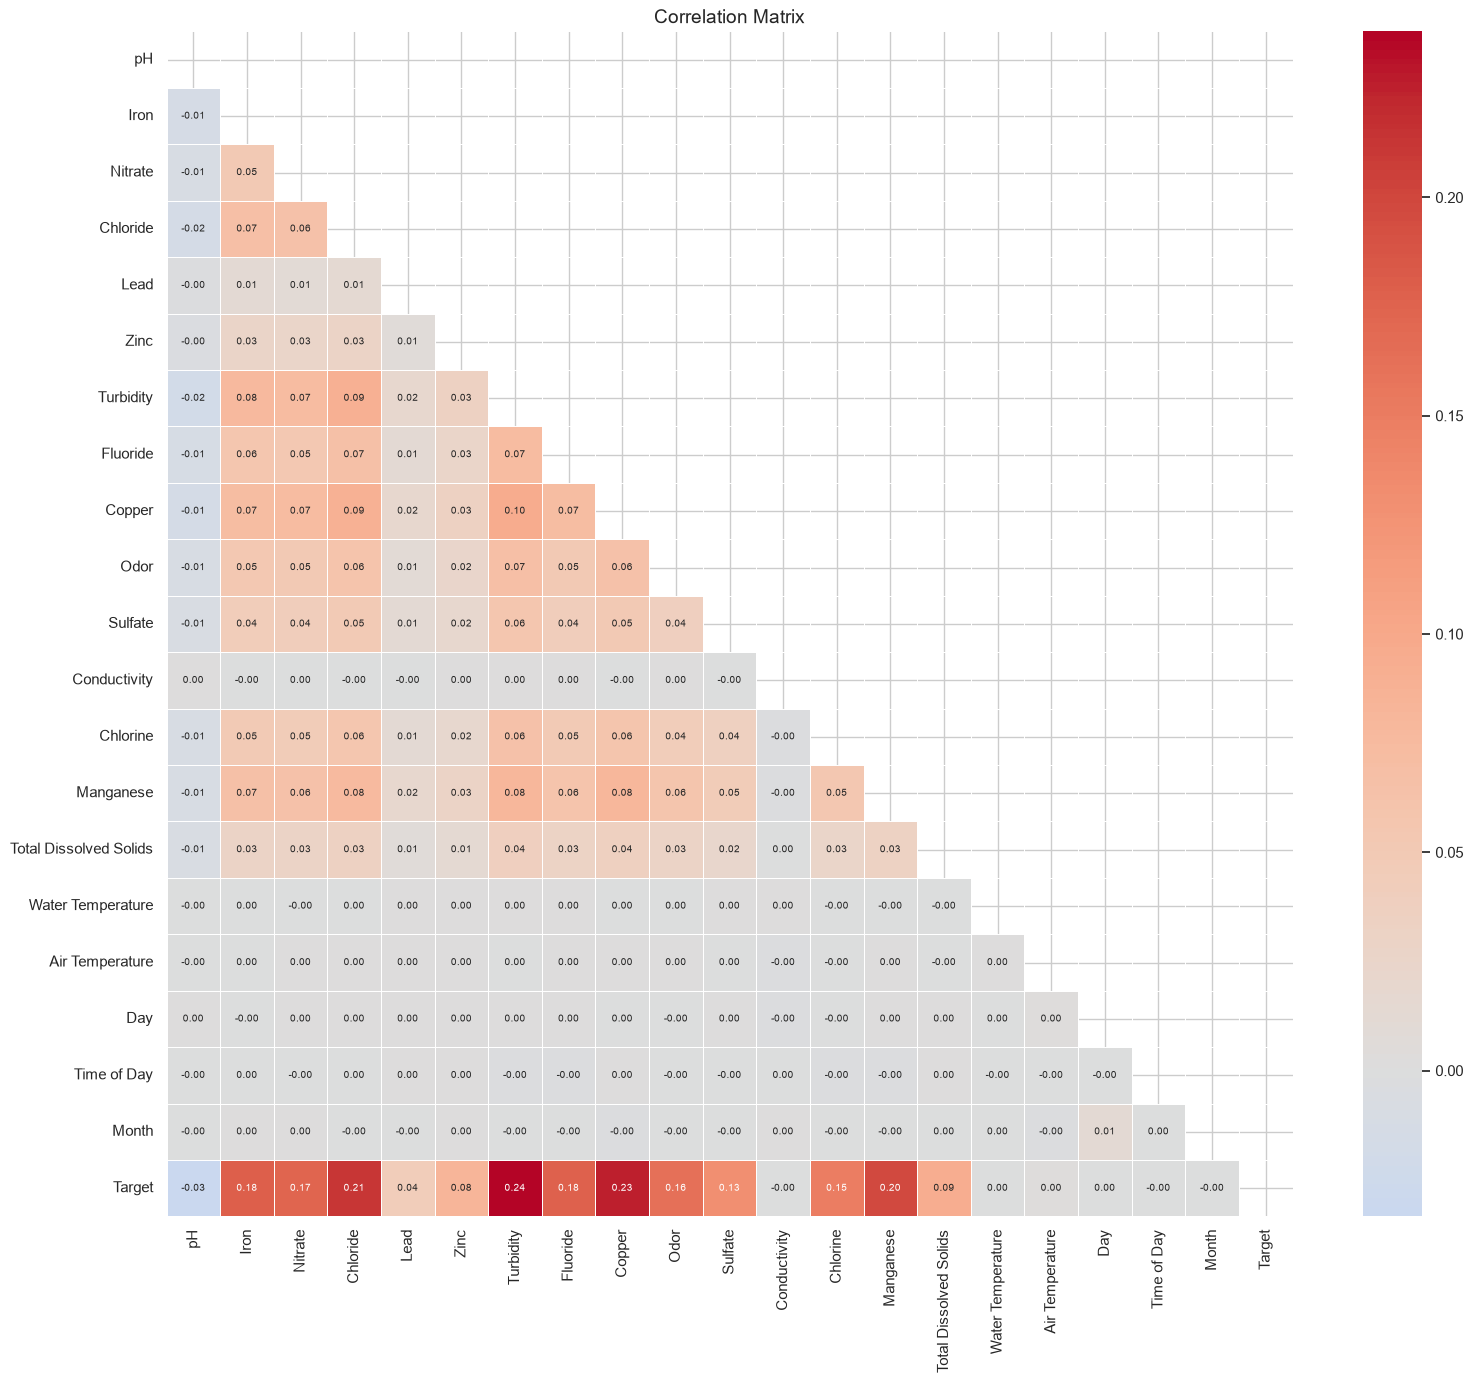

In [53]:
# Correlation Matrix
corr_matrix = df[numerical_cols + ["Target"]].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, annot_kws={"size": 7}, linewidths=0.5)
ax.set_title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/figures/correlation_matrix.png", dpi=150)
plt.show()

In [54]:
# Ranking list of correlation with Target
target_corr = df[numerical_cols].corrwith(df["Target"]).abs().sort_values(ascending=False)

print("Feature Correlation with Target (absolute value):")
print(target_corr.round(4))

Feature Correlation with Target (absolute value):
Turbidity                 0.2380
Copper                    0.2255
Chloride                  0.2123
Manganese                 0.1980
Iron                      0.1796
Fluoride                  0.1765
Nitrate                   0.1731
Odor                      0.1625
Chlorine                  0.1491
Sulfate                   0.1316
Total Dissolved Solids    0.0932
Zinc                      0.0834
Lead                      0.0440
pH                        0.0334
Air Temperature           0.0032
Time of Day               0.0016
Conductivity              0.0013
Month                     0.0005
Day                       0.0005
Water Temperature         0.0000
dtype: float64


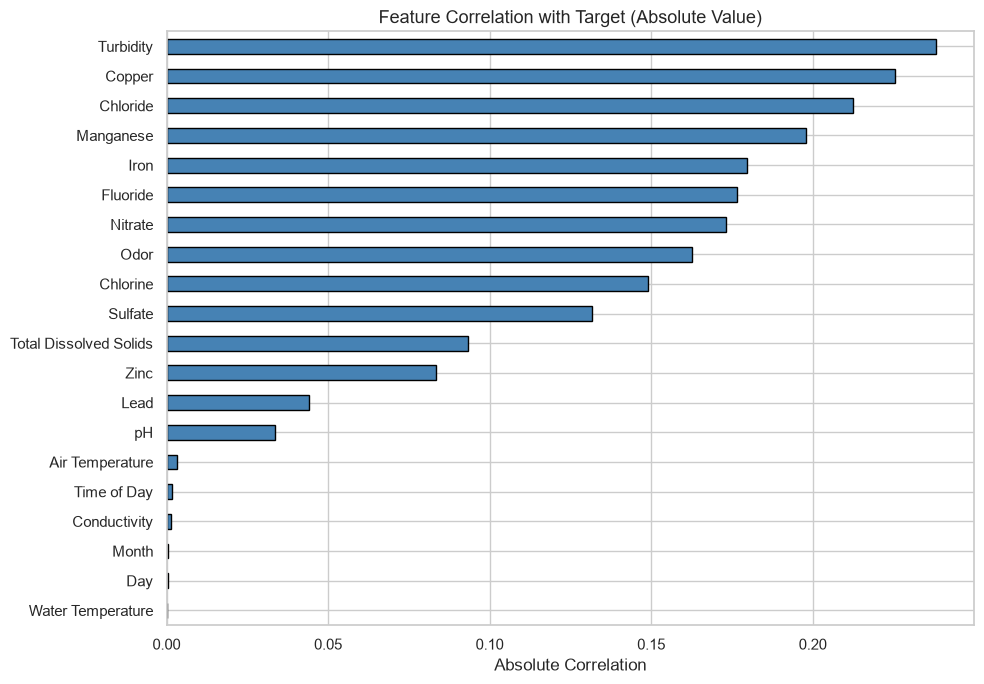

In [55]:
# Visualization of relevance to Target
fig, ax = plt.subplots(figsize=(10, 7))
target_corr.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Feature Correlation with Target (Absolute Value)", fontsize=13)
ax.set_xlabel("Absolute Correlation")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/feature_target_correlation.png", dpi=150)
plt.show()

In [56]:
time_cols = ["Month", "Day", "Time of Day"]
time_corr = df[time_cols].corrwith(df["Target"]).abs()

print("Time variables correlation with Target:")
print(time_corr.round(4))

Time variables correlation with Target:
Month          0.0005
Day            0.0005
Time of Day    0.0016
dtype: float64


The three time variables all have correlations close to 0 with the Target, which shows that sampling time doesn't really contribute to water quality prediction. The timestamps are used for random sampling records, not to track systematic changes in water quality.


#### Color Distribution


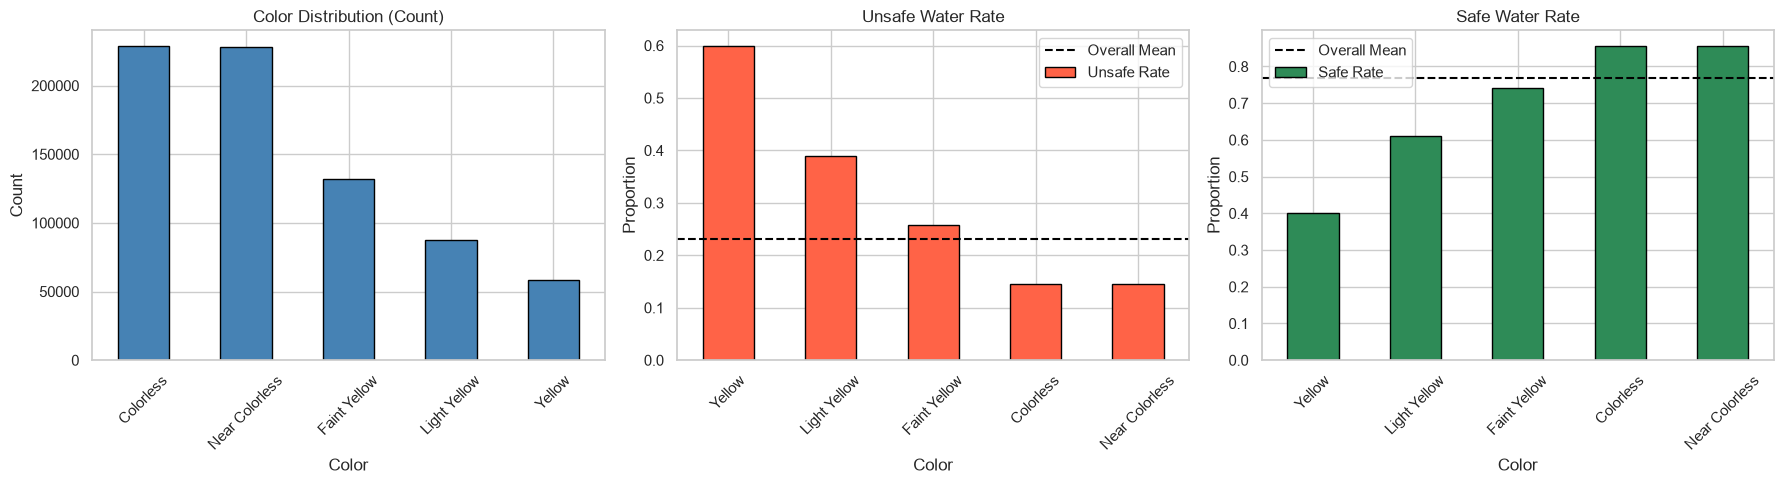

In [57]:
color_stats = df.groupby("Color")["Target"].agg(['mean', lambda x: 1 - x.mean()])
color_stats.columns = ['Unsafe Rate', 'Safe Rate']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall
df["Color"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Color Distribution (Count)")
axes[0].set_xlabel("Color")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Unsafe Rate
color_stats['Unsafe Rate'].sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="tomato", edgecolor="black")
axes[1].set_title("Unsafe Water Rate")
axes[1].set_ylabel("Proportion")
axes[1].axhline(y=df["Target"].mean(), color="black", linestyle="--", label="Overall Mean")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

# Safe Rate

color_stats['Safe Rate'].sort_values(ascending=True).plot(kind="bar", ax=axes[2], color="seagreen", edgecolor="black")
axes[2].set_title("Safe Water Rate")
axes[2].set_ylabel("Proportion")
axes[2].axhline(y=1 - df["Target"].mean(), color="black", linestyle="--", label="Overall Mean")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Source Distribution


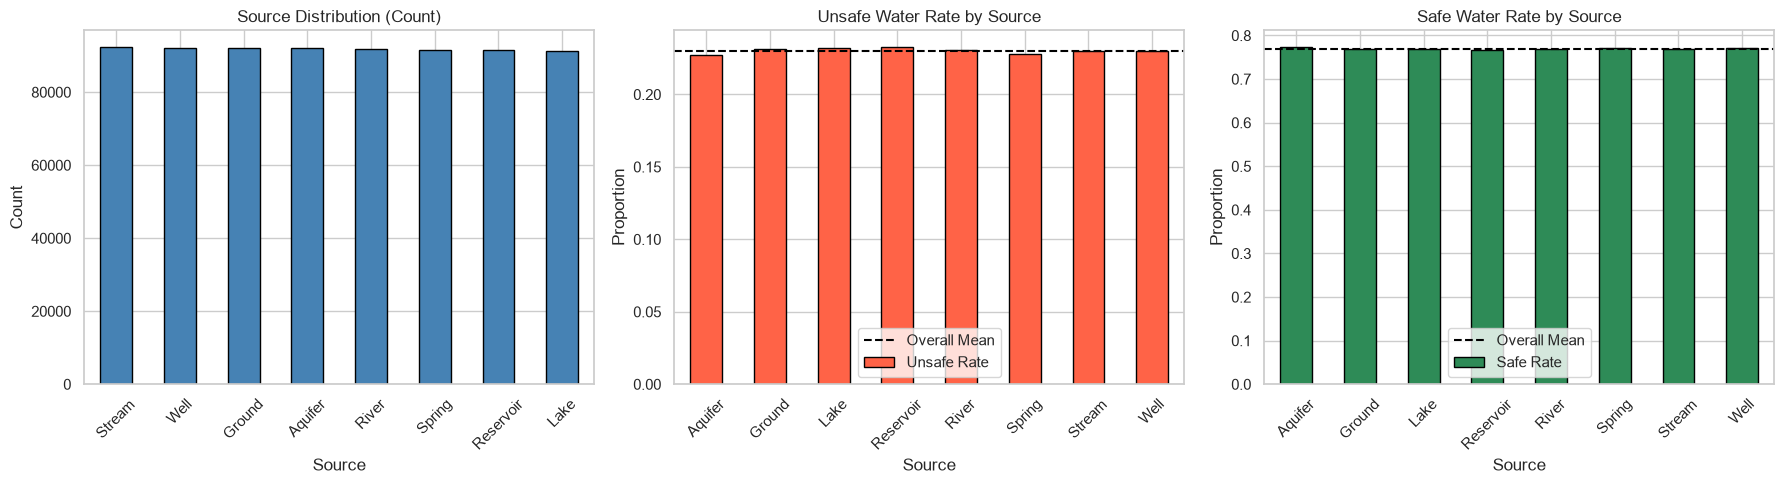

In [58]:
# Source analysis
source_stats = df.groupby("Source")["Target"].agg(['mean', lambda x: 1 - x.mean()])
source_stats.columns = ['Unsafe Rate', 'Safe Rate']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall Distribution
df["Source"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Source Distribution (Count)")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Unsafe Rate
source_stats['Unsafe Rate'].plot(kind="bar", ax=axes[1], color="tomato", edgecolor="black")
axes[1].set_title("Unsafe Water Rate by Source")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Proportion")
axes[1].axhline(y=df["Target"].mean(), color="black", linestyle="--", label="Overall Mean")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

# Safe Rate
source_stats['Safe Rate'].plot(kind="bar", ax=axes[2], color="seagreen", edgecolor="black")
axes[2].set_title("Safe Water Rate by Source")
axes[2].set_xlabel("Source")
axes[2].set_ylabel("Proportion")
axes[2].axhline(y=1 - df["Target"].mean(), color="black", linestyle="--", label="Overall Mean")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/source_analysis.png", dpi=150)
plt.show()

The 8 types of water source sampling are very balanced, which shows that the dataset is well-designed and there’s no sampling bias.


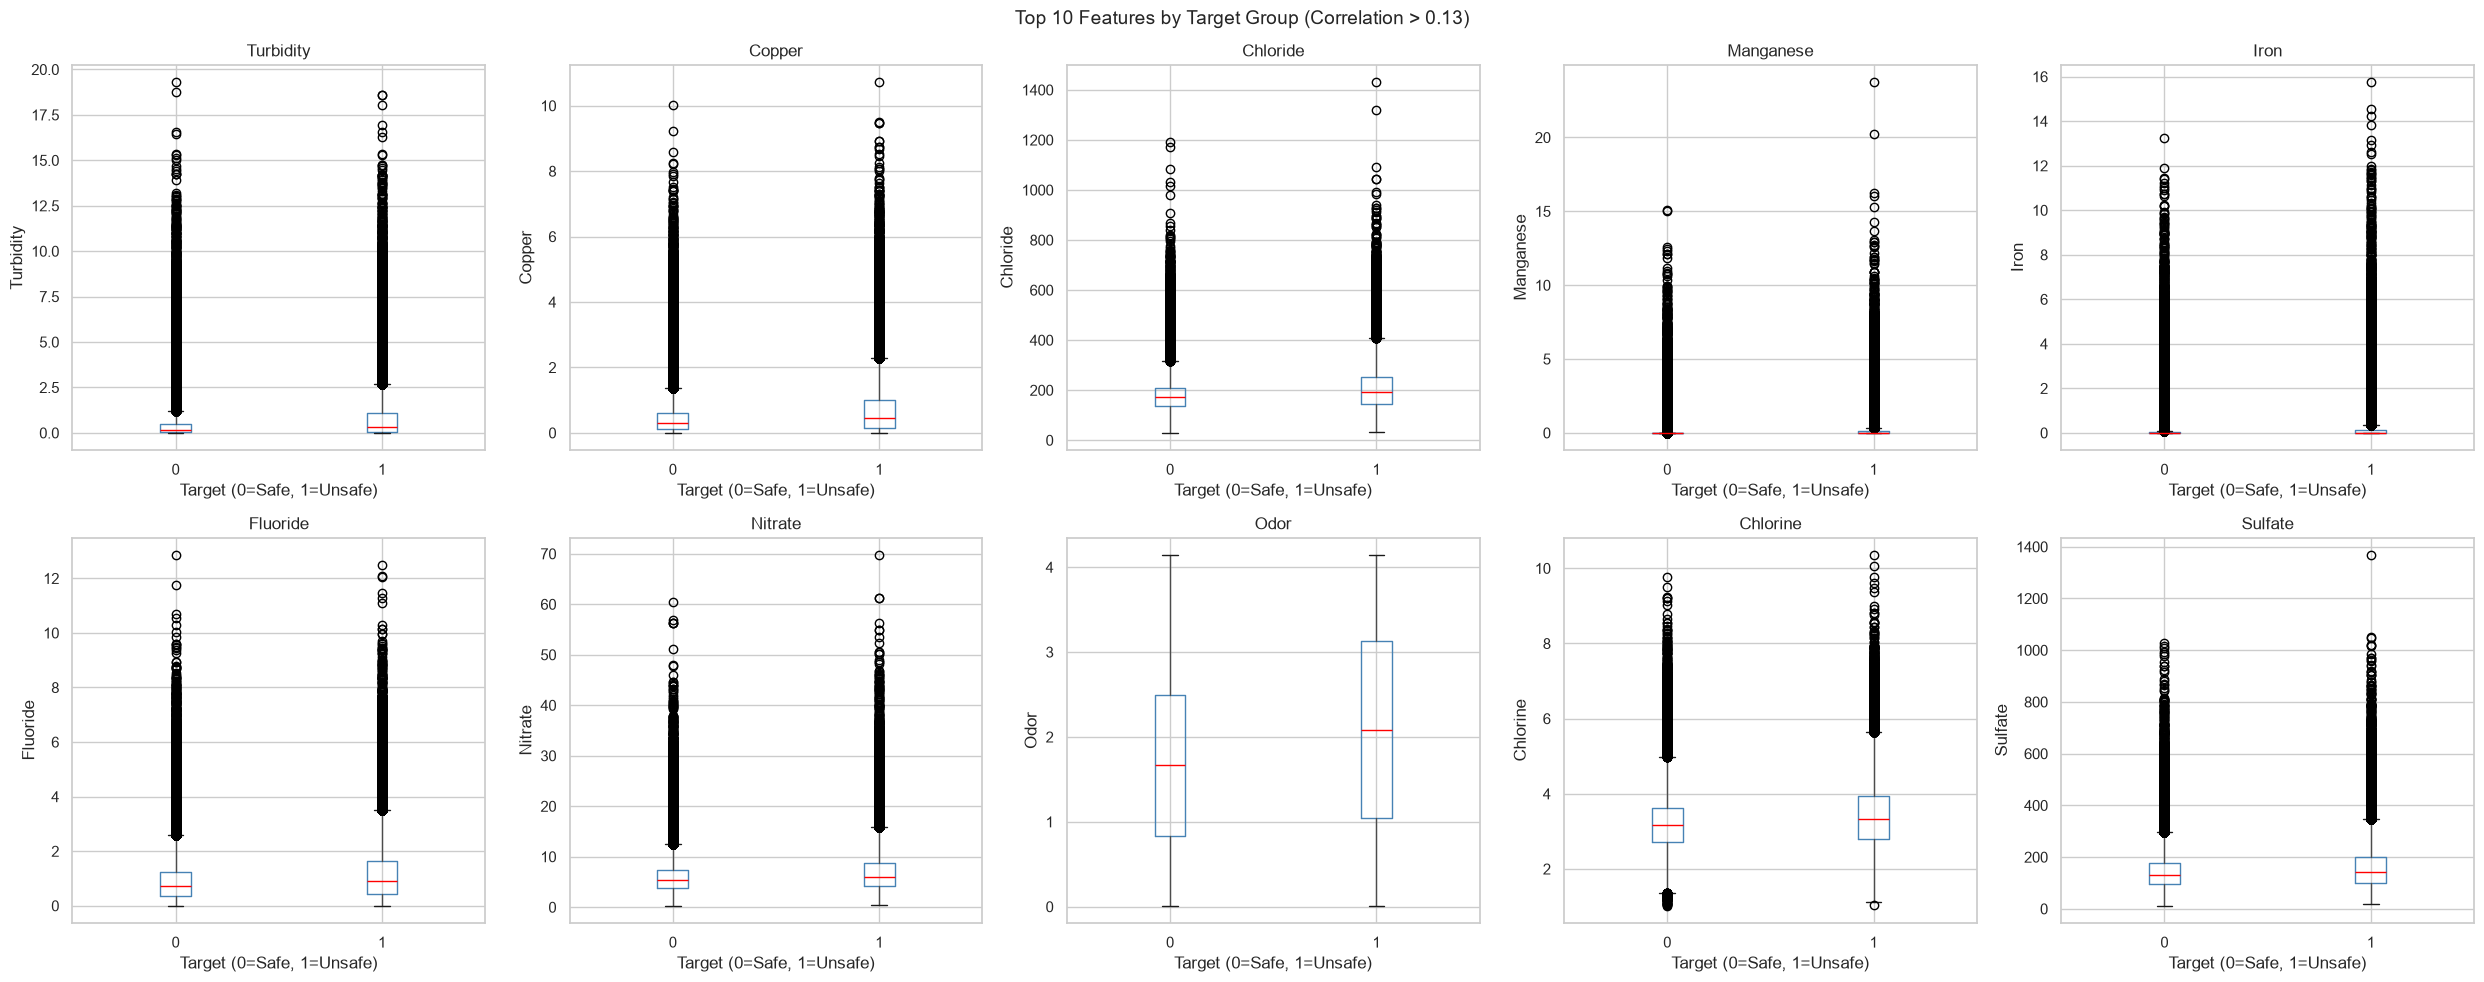

In [59]:
# Boxplot of Top 10 Features (sorted by correlation, above 0.13)
top10 = ["Turbidity", "Copper", "Chloride", "Manganese",
         "Iron", "Fluoride", "Nitrate", "Odor", "Chlorine", "Sulfate"]

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, col in enumerate(top10):
    df.boxplot(column=col, by="Target", ax=axes[i],
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="red"))
    axes[i].set_title(col)
    axes[i].set_xlabel("Target (0=Safe, 1=Unsafe)")
    axes[i].set_ylabel(col)

plt.suptitle("Top 10 Features by Target Group (Correlation > 0.13)", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/figures/top10_boxplot.png", dpi=150)
plt.show()

### EDA Summary


In [60]:
print(f"Total samples after cleaning : {len(df):,}")
print(f"Safe water   (Target=0)      : {(df['Target']==0).sum():,} ({(df['Target']==0).mean():.1%})")
print(f"Unsafe water (Target=1)      : {(df['Target']==1).sum():,} ({(df['Target']==1).mean():.1%})")
print()
print("Top 5 predictors (by correlation):")
for i, (feat, val) in enumerate(target_corr.head(5).items(), 1):
    print(f"  {i}. {feat:<25} {val:.4f}")

Total samples after cleaning : 734,756
Safe water   (Target=0)      : 565,630 (77.0%)
Unsafe water (Target=1)      : 169,126 (23.0%)

Top 5 predictors (by correlation):
  1. Turbidity                 0.2380
  2. Copper                    0.2255
  3. Chloride                  0.2123
  4. Manganese                 0.1980
  5. Iron                      0.1796


### Key EDA Findings

The exploratory data analysis provides several important insights for later modeling.

First, the target variable is confirmed as a binary classification outcome:

- `Target = 0`: Safe water
- `Target = 1`: Unsafe water

After data cleaning, the dataset contains **739,148 observations**. The target distribution is moderately imbalanced, with approximately **77.0% safe samples** and **23.0% unsafe samples**. This imbalance should be considered when evaluating model performance, especially for recall and F1-score of the unsafe class.

Correlation analysis shows that no single variable dominates the prediction of water safety. The strongest linear correlation with the target is **Turbidity (0.238)**, followed by **Copper (0.226)**, **Chloride (0.212)**, **Manganese (0.199)**, **Iron (0.179)**, **Fluoride (0.176)**, **Nitrate (0.173)**, **Odor (0.163)**, **Chlorine (0.149)**, and **Sulfate (0.132)**. Since the maximum correlation is only 0.238, water quality appears to be influenced by multiple factors rather than one dominant predictor.

Several domain-relevant patterns are also observed. Heavy metals and turbidity are among the strongest predictors, which is consistent with the idea that suspended particles and chemical contamination are important indicators of unsafe water. However, pH has a surprisingly weak correlation with the target, around **0.034**, suggesting that pH alone has limited predictive power in this dataset.

Categorical analysis shows that **Color** is strongly associated with the unsafe rate. Yellow water has the highest unsafe rate, around **60%**, followed by Light Yellow at around **39%** and Faint Yellow at around **26%**. In contrast, Colorless and Near Colorless water have much lower unsafe rates, around **15%**. This pattern is consistent with domain intuition, as stronger discoloration may reflect suspended matter, metals, or other contaminants.

In contrast, the `Source` variable shows little direct predictive value. The eight source categories have similar sample sizes and unsafe rates close to the overall average of about **23%**. Time-related variables, including Month, Day, and Time of Day, also show near-zero correlation with the target, suggesting that they mainly represent sampling records rather than meaningful predictors of water safety.

Overall, the EDA suggests that water safety in this dataset is driven by a combination of chemical and physical indicators. These findings support the use of multivariate machine learning models rather than relying on a single predictor.

### Outlier Detection — IQR Method

The IQR (Inter Quartile Range) approach is the most commonly used method for outlier detection.
Upper and lower bounds are defined as:
- **Upper = Q3 + 1.5 × IQR**
- **Lower = Q1 – 1.5 × IQR**

This quantifies how many extreme values exist in each feature, which informs preprocessing decisions.


In [61]:
# Outlier detection using IQR method (Ch.5 — IQR Statistical Approach)
# Features selected: same numerical_cols defined earlier in this notebook
outlier_cols = ["pH", "Iron", "Nitrate", "Chloride", "Lead", "Zinc",
                "Turbidity", "Fluoride", "Copper", "Odor", "Sulfate",
                "Conductivity", "Chlorine", "Manganese", "Total Dissolved Solids",
                "Water Temperature", "Air Temperature"]

outlier_summary = []

for col in outlier_cols:
    Q1 = np.percentile(df[col], 25, method='midpoint')
    Q3 = np.percentile(df[col], 75, method='midpoint')
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    n_upper = (df[col] > upper).sum()
    n_lower = (df[col] < lower).sum()
    n_total = n_upper + n_lower
    pct = round(n_total / len(df) * 100, 2)

    outlier_summary.append({
        'Feature'      : col,
        'Q1'           : round(Q1, 3),
        'Q3'           : round(Q3, 3),
        'IQR'          : round(IQR, 3),
        'Lower Bound'  : round(lower, 3),
        'Upper Bound'  : round(upper, 3),
        'Above Upper'  : int(n_upper),
        'Below Lower'  : int(n_lower),
        'Total Outliers': int(n_total),
        'Outlier %'    : pct
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
outlier_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Above Upper,Below Lower,Total Outliers,Outlier %
4,Lead,0.000,0.000,0.000,-0.000,0.000,181113,0,181113,24.65
1,Iron,0.000,0.050,0.050,-0.075,0.124,117741,0,117741,16.02
13,Manganese,0.000,0.014,0.014,-0.021,0.034,117639,0,117639,16.01
6,Turbidity,0.037,0.593,0.556,-0.796,1.426,51581,0,51581,7.02
8,Copper,0.126,0.679,0.553,-0.704,1.508,35909,0,35909,4.89
15,Water Temperature,11.425,23.906,12.481,-7.296,42.626,31071,0,31071,4.23
7,Fluoride,0.370,1.318,0.948,-1.051,2.740,23179,0,23179,3.15
2,Nitrate,3.950,7.587,3.637,-1.506,13.043,21788,0,21788,2.97
3,Chloride,137.424,215.699,78.276,20.010,333.112,21633,0,21633,2.94
5,Zinc,0.414,2.216,1.802,-2.290,4.920,20715,0,20715,2.82


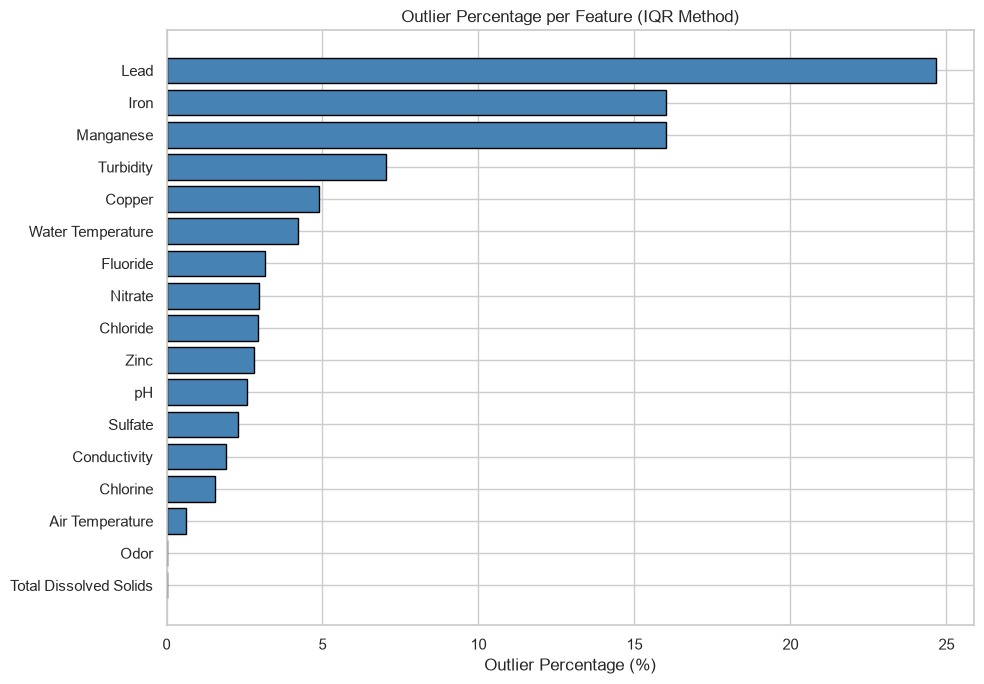

In [62]:
# Visualise outlier percentage per feature using a horizontal bar chart
# Following the bar chart style shown in Ch.4 slides
fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(outlier_df['Feature'], outlier_df['Outlier %'],
        color='steelblue', edgecolor='black')

ax.set_xlabel('Outlier Percentage (%)')
ax.set_title('Outlier Percentage per Feature (IQR Method)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/outlier_iqr.png', dpi=150)
plt.show()

### Outlier Detection — Z-Score Method

Z-Score measures how many standard deviations a data point is from the mean:
**z = (x − mean) / std**

A threshold of **3.0** is used (covering 99.7% of data under Gaussian distribution).
Comparing IQR and Z-Score results shows whether outliers are consistent across both methods.


In [63]:
# Outlier detection using Z-Score method (Ch.5 — Z-Score Statistical Approach)
# scipy.stats is used only for zscore(), consistent with the lecture slides

threshold = 3
z_scores = np.abs(stats.zscore(df[outlier_cols]))

zscore_outliers = (z_scores > threshold).sum(axis=0)
zscore_pct = (zscore_outliers / len(df) * 100).round(2)

zscore_df = pd.DataFrame({
    'Feature': outlier_cols,
    'Z-Score Outliers': zscore_outliers,
    'Outlier %': zscore_pct
}).sort_values('Outlier %', ascending=False).reset_index(drop=True)

print(f"Z-Score method (threshold = {threshold}) — outlier count per feature:")
zscore_df

Z-Score method (threshold = 3) — outlier count per feature:


,Feature,Z-Score Outliers,Outlier %
0,Turbidity,16866,2.30
1,Copper,15925,2.17
2,Iron,13437,1.83
3,Manganese,13278,1.81
4,Fluoride,13094,1.78
5,Water Temperature,12114,1.65
6,Nitrate,11845,1.61
7,Chloride,11418,1.55
8,Sulfate,10045,1.37
9,Zinc,9957,1.36


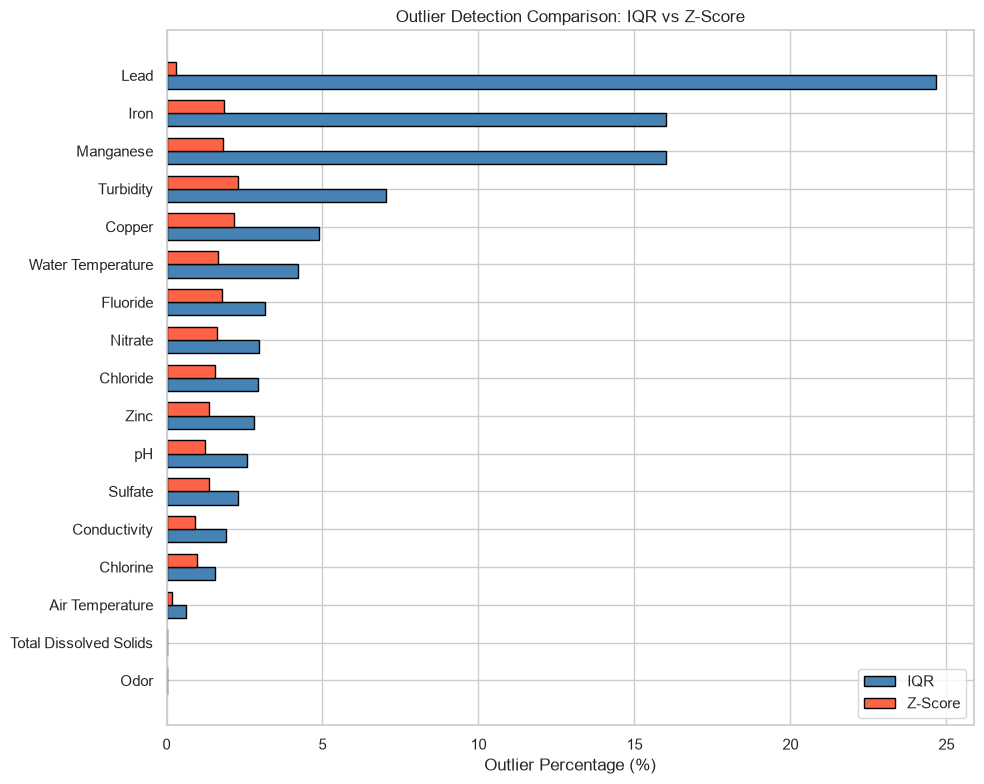

In [64]:
# Side-by-side comparison: IQR vs Z-Score outlier percentages
# Multiseries bar chart following the style in Ch.4 slides
compare_df = outlier_df[['Feature', 'Outlier %']].rename(columns={'Outlier %': 'IQR %'})
compare_df = compare_df.merge(
    zscore_df[['Feature', 'Outlier %']].rename(columns={'Outlier %': 'Z-Score %'}),
    on='Feature'
).sort_values('IQR %', ascending=True)

index  = np.arange(len(compare_df))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(index,           compare_df['IQR %'],     width, label='IQR',     color='steelblue', edgecolor='black')
ax.barh(index + width,   compare_df['Z-Score %'], width, label='Z-Score', color='tomato',    edgecolor='black')

ax.set_yticks(index + width / 2)
ax.set_yticklabels(compare_df['Feature'])
ax.set_xlabel('Outlier Percentage (%)')
ax.set_title('Outlier Detection Comparison: IQR vs Z-Score')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/outlier_comparison.png', dpi=150)
plt.show()

### Interaction Term Analysis

The single-feature EDA above shows the relationship between each variable and Target
individually. However, some water-quality risks only emerge from the **combination** of
two features rather than either feature alone.

Based on water-quality domain knowledge, we hypothesize the following interaction effects:

| Interaction | Domain rationale |
|---|---|
| pH × Lead | Acidic water increases the solubility of lead, making it more bioavailable |
| pH × Copper | Same mechanism — copper solubility increases as water becomes more acidic |
| pH × Iron | Acidic conditions promote iron dissolution from pipes/soil |
| pH × Manganese | Acidic conditions also promote manganese dissolution |
| Turbidity × Chlorine | High turbidity can shield microorganisms from disinfection, reducing the effective protection from free chlorine |

For each pair, we examine the interaction effect three ways:
1. A 2D scatter plot colored by Target — to visually inspect whether Unsafe points cluster in a specific region
2. A binned heatmap of Unsafe Rate — to quantify the combined effect across the 2D feature space
3. The correlation of the interaction term itself with Target — compared against each individual feature's correlation

In [65]:
# Define the interaction pairs to analyze, based on the domain hypotheses above
interaction_pairs = [
    ("pH", "Lead"),
    ("pH", "Copper"),
    ("Turbidity", "Chlorine"),
    ("pH", "Iron"),
    ("pH", "Manganese")
]

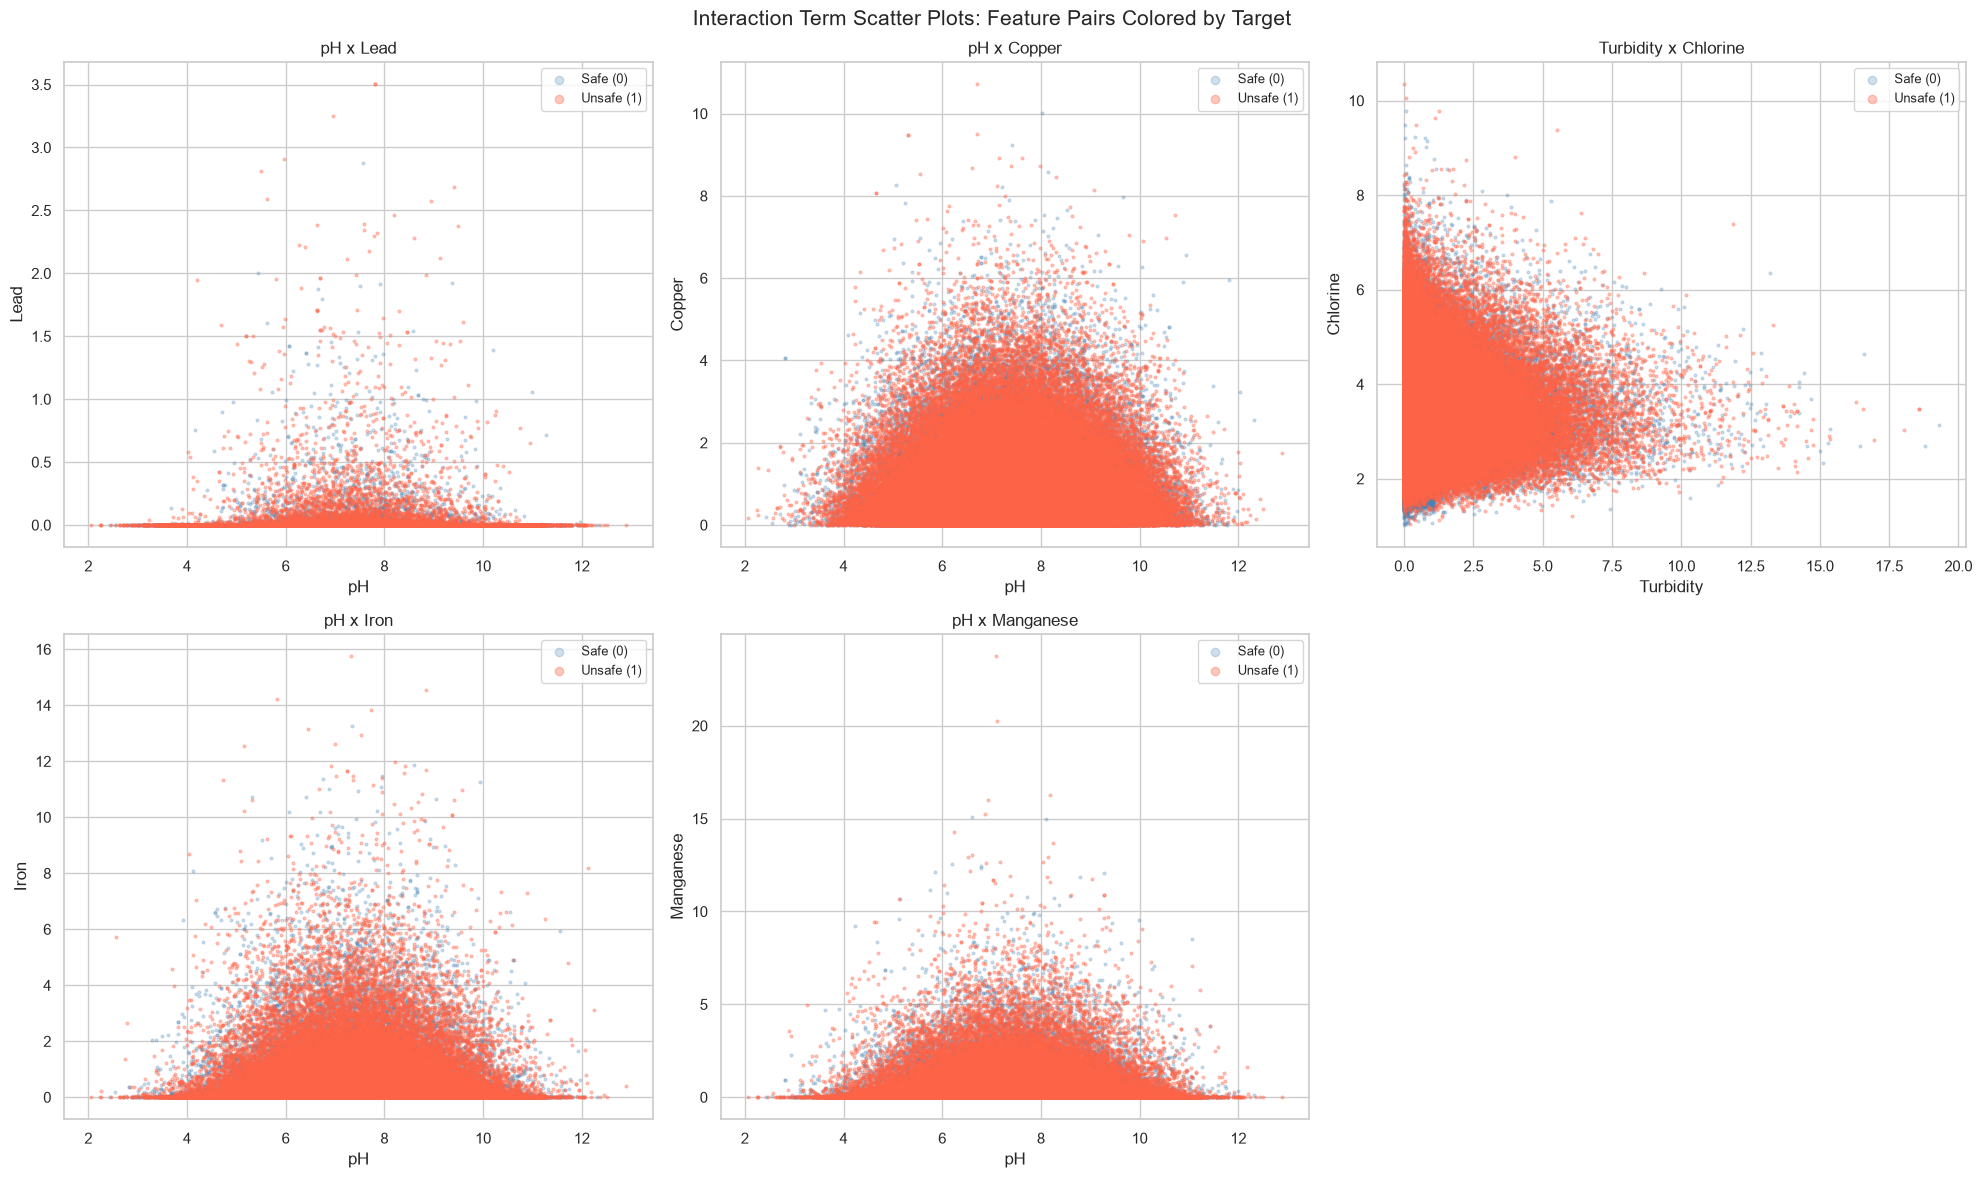

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (feat_x, feat_y) in enumerate(interaction_pairs):
    safe   = df[df["Target"] == 0]
    unsafe = df[df["Target"] == 1]
    # Plot Safe first
    axes[i].scatter(safe[feat_x], safe[feat_y], s=4, alpha=0.25, color="steelblue", label="Safe (0)")
    axes[i].scatter(unsafe[feat_x], unsafe[feat_y], s=4, alpha=0.35, color="tomato", label="Unsafe (1)")
    axes[i].set_xlabel(feat_x)
    axes[i].set_ylabel(feat_y)
    axes[i].set_title(f"{feat_x} x {feat_y}")
    axes[i].legend(markerscale=3, fontsize=9)


axes[5].axis("off")
plt.suptitle("Interaction Term Scatter Plots: Feature Pairs Colored by Target", fontsize=15)
plt.tight_layout()
plt.savefig("../reports/figures/interaction_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

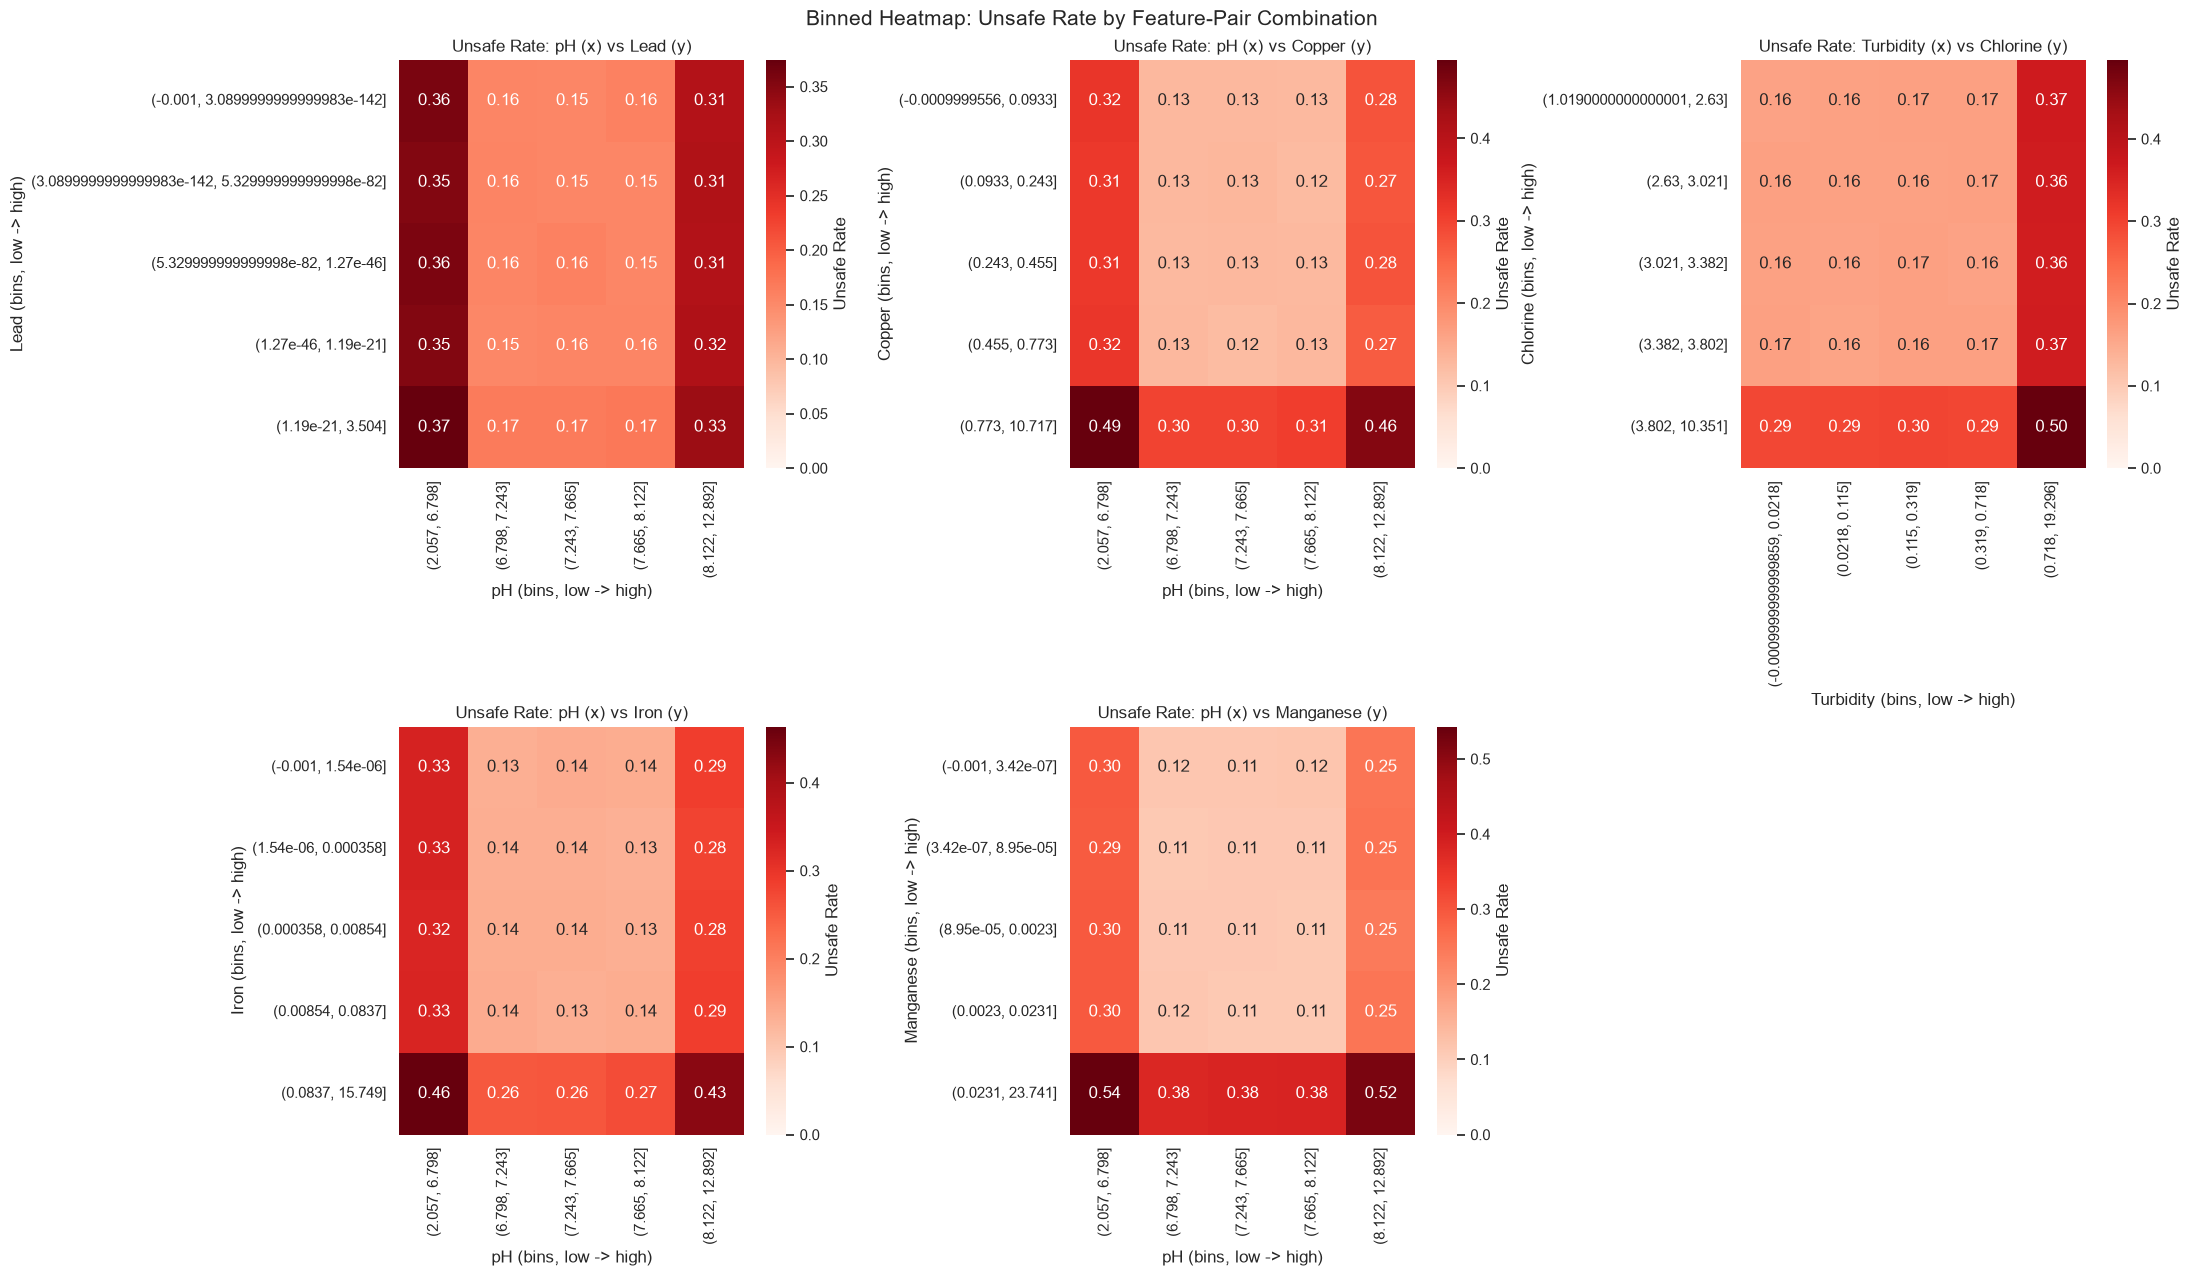

In [67]:
# draw the heat map 
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
axes = axes.flatten()

for i, (feat_x, feat_y) in enumerate(interaction_pairs):
    bin_x = pd.qcut(df[feat_x], q=5, duplicates="drop")
    bin_y = pd.qcut(df[feat_y], q=5, duplicates="drop")
    pivot = df.groupby([bin_y, bin_x])["Target"].mean().unstack()

    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds",
                vmin=0, vmax=pivot.values.max(),
                ax=axes[i], cbar_kws={"label": "Unsafe Rate"})

    axes[i].set_title(f"Unsafe Rate: {feat_x} (x) vs {feat_y} (y)")
    axes[i].set_xlabel(f"{feat_x} (bins, low -> high)")
    axes[i].set_ylabel(f"{feat_y} (bins, low -> high)")

axes[5].axis("off")
plt.suptitle("Binned Heatmap: Unsafe Rate by Feature-Pair Combination", fontsize=15)
plt.tight_layout()
plt.savefig("../reports/figures/interaction_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [68]:
interaction_summary = []

for feat_x, feat_y in interaction_pairs:
    interaction_term = df[feat_x] * df[feat_y]

    corr_x = df[feat_x].corr(df["Target"])
    corr_y = df[feat_y].corr(df["Target"])
    corr_interaction = interaction_term.corr(df["Target"])

    interaction_summary.append({
        "Feature X": feat_x,
        "Feature Y": feat_y,
        "Corr(X, Target)": round(corr_x, 4),
        "Corr(Y, Target)": round(corr_y, 4),
        "Corr(X*Y, Target)": round(corr_interaction, 4),
        "Stronger than both?": abs(corr_interaction) > max(abs(corr_x), abs(corr_y))
    })

interaction_df = pd.DataFrame(interaction_summary)
interaction_df

,Feature X,Feature Y,"Corr(X, Target)","Corr(Y, Target)","Corr(X*Y, Target)",Stronger than both?
0,pH,Lead,-0.0334,0.0440,0.0434,False
1,pH,Copper,-0.0334,0.2255,0.2191,False
2,Turbidity,Chlorine,0.2380,0.1491,0.2393,True
3,pH,Iron,-0.0334,0.1796,0.1774,False
4,pH,Manganese,-0.0334,0.1980,0.1954,False


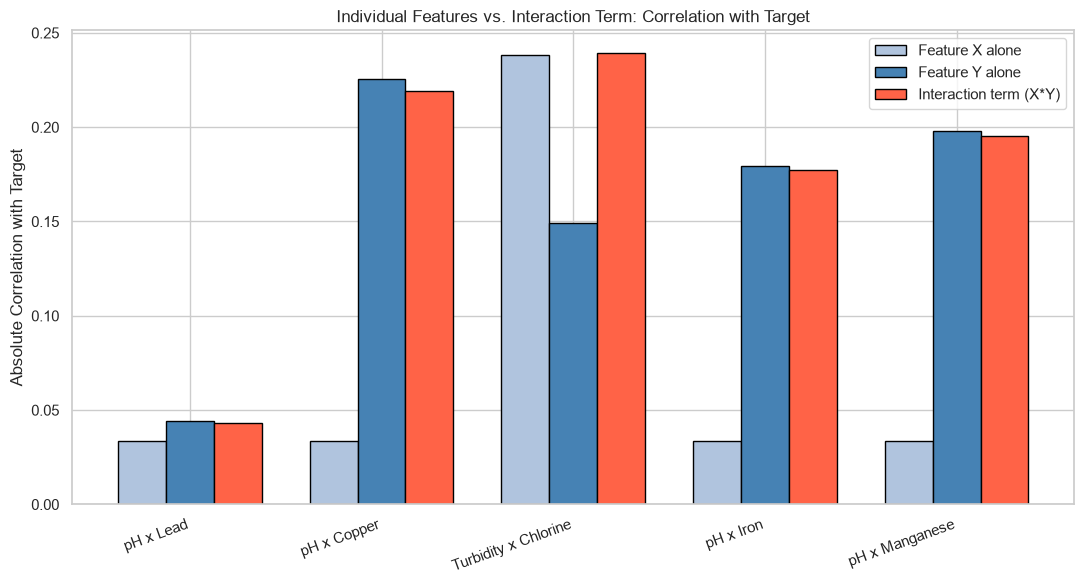

In [69]:
# individual correlations vs interaction term correlation
fig, ax = plt.subplots(figsize=(11, 6))
index = np.arange(len(interaction_df))
width = 0.25

labels = [f"{r['Feature X']} x {r['Feature Y']}" for _, r in interaction_df.iterrows()]
ax.bar(index - width, interaction_df["Corr(X, Target)"].abs(), width, label="Feature X alone", color="lightsteelblue", edgecolor="black")
ax.bar(index, interaction_df["Corr(Y, Target)"].abs(), width, label="Feature Y alone", color="steelblue", edgecolor="black")
ax.bar(index + width, interaction_df["Corr(X*Y, Target)"].abs(), width, label="Interaction term (X*Y)", color="tomato", edgecolor="black")

ax.set_xticks(index)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Absolute Correlation with Target")
ax.set_title("Individual Features vs. Interaction Term: Correlation with Target")
ax.legend()

plt.tight_layout()
plt.savefig("../reports/figures/interaction_correlation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Model 1: Logistic Regression

The objective of this section is to develop, optimize, and interpret a Logistic Regression model for predicting water quality.

**Logistic Regression was selected because it is one of the most widely used supervised learning algorithms for binary classification problems.** In this project, the target variable indicates whether a water sample is safe or unsafe, making Logistic Regression an appropriate baseline model for the classification task.

Compared with more complex machine learning algorithms, Logistic Regression offers several advantages. First, it produces probabilistic predictions, allowing the likelihood of unsafe water quality to be estimated rather than only providing a class label. Second, its regression coefficients are directly interpretable, making it possible to identify how individual water quality indicators influence the prediction. This interpretability is particularly important for this project because one of the research objectives is **to determine which factors are the strongest predictors of water quality**, rather than simply maximizing prediction accuracy.

Furthermore, Logistic Regression is computationally efficient, robust, and serves as an excellent benchmark for evaluating the effectiveness of more advanced techniques such as feature engineering and hyperparameter tuning.

The analysis follows a progressive modelling strategy. First, the dataset is prepared by encoding categorical variables and standardizing numerical features. A baseline Logistic Regression model is then established to provide a reference for subsequent improvements. Next, univariate Logistic Regression is performed to investigate the individual association between each predictor and the target variable.

Based on the previous analyses, interaction terms are introduced between the most influential predictors to capture potential relationships that cannot be represented by individual variables alone. The interaction model is then compared with the baseline model to evaluate the effectiveness of feature engineering.

To further optimize the model, hyperparameter tuning is performed using **GridSearchCV** with five-fold cross-validation. The best-performing model is selected according to the average ROC-AUC score and evaluated on the independent testing dataset.

Finally, feature importance is analyzed using the coefficients of the optimized Logistic Regression model to identify the strongest predictors of water quality and to evaluate the contribution of the interaction features.

### Logistic Regression Modeling Workflow

1. Import libraries
2. Load the cleaned dataset
3. Prepare the data and encode categorical variables
4. Split the dataset into training and testing sets
5. Standardize the predictor variables
6. Build a baseline Logistic Regression model
7. Perform univariate Logistic Regression analysis
8. Construct interaction terms and compare model performance
9. Optimize the model using GridSearchCV
10. Interpret the optimized model through feature importance analysis

Through these steps, the Logistic Regression model is progressively improved from a simple baseline classifier to an optimized and interpretable predictive model. The analysis also demonstrates how feature engineering and hyperparameter tuning influence model performance and provides insights into the most important factors affecting water quality.


#### 1. Load dataset

In [70]:
# Load cleaned dataset
df = pd.read_csv("../data/processed/water_quality_cleaned.csv")

#### 2. Data Preparation

Before training the Logistic Regression model, the dataset was prepared by separating the predictor variables from the target variable, performing feature engineering, and encoding categorical variables into numerical representations suitable for machine learning algorithms.

The target variable (`Target`) was extracted as the response variable (`y_lr`), while all remaining columns were used as predictor variables (`X_lr`).

To better capture the potential non-linear relationship between **pH** and water quality, a centered quadratic transformation was applied. Since both highly acidic and highly alkaline water may indicate poor water quality, the effect of pH is unlikely to be purely linear. Therefore, two new variables were created:

- **pH_centered** = pH − 7
- **pH_centered_squared** = (pH − 7)²

The original `pH` variable was subsequently removed because `pH_centered` retains the same information after centering while improving the interpretability of the quadratic term.

Since Logistic Regression requires numerical inputs, the categorical variables **Color** and **Source** were encoded using different strategies according to their characteristics.

- **Color** was encoded using **Ordinal Encoding** because the categories have a natural order that reflects increasing water coloration:

  *Colorless < Near Colorless < Faint Yellow < Light Yellow < Yellow*

  Preserving this order enables the model to capture the gradual increase in water colour intensity while retaining a single numerical feature.

- **Source** was encoded using **One-Hot Encoding** because different water sources (such as River, Lake, Groundwater, and Reservoir) are nominal categories without any inherent ordering. One-Hot Encoding converts each category into a separate binary feature, preventing the model from imposing an artificial ordinal relationship among different water sources.

After feature engineering and categorical encoding, all predictor variables were represented numerically and were ready for train-test splitting, feature scaling, and Logistic Regression modelling.

In [71]:
### 1. Data Preparation

# Separate predictors and target
X_lr = df.drop(columns=["Target"])
y_lr = df["Target"]

print("X_lr shape:", X_lr.shape)
print("y_lr shape:", y_lr.shape)

### 2. Feature Engineering

# pH may have a non-linear effect on water quality.
# Both highly acidic and highly alkaline water can indicate
# poor water quality. Therefore, a centered quadratic term
# is created to capture this potential U-shaped relationship.

X_lr["pH_centered"] = X_lr["pH"] - 7

X_lr["pH_centered_squared"] = (
        X_lr["pH_centered"] ** 2
)

# The original pH variable is removed because pH_centered
# contains the same information after centering.
X_lr = X_lr.drop(columns=["pH"])

### 3. Categorical Encoding

# Source is an unordered categorical variable,
# therefore One-Hot Encoding is applied.

# Color has a natural order:
# Colorless < Near Colorless < Faint Yellow
# < Light Yellow < Yellow
# therefore Ordinal Encoding is applied.

# Color: Ordinal Encoding
color_order = [
    "Colorless",
    "Near Colorless",
    "Faint Yellow",
    "Light Yellow",
    "Yellow"
]

color_mapping = {
    category: index
    for index, category in enumerate(color_order)
}

X_lr["Color"] = X_lr["Color"].map(color_mapping)

# Source: One-Hot Encoding
X_lr = pd.get_dummies(
    X_lr,
    columns=["Source"],
    drop_first=False,
    dtype=int
)

print("X_lr shape after feature engineering and encoding:",
      X_lr.shape)

print(X_lr.columns.tolist())

X_lr shape: (734756, 22)
y_lr shape: (734756,)
X_lr shape after feature engineering and encoding: (734756, 30)
['Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day', 'pH_centered', 'pH_centered_squared', 'Source_Aquifer', 'Source_Ground', 'Source_Lake', 'Source_Reservoir', 'Source_River', 'Source_Spring', 'Source_Stream', 'Source_Well']


#### 3.Train-test split

In [72]:
# Train-Test Split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
X_lr,
y_lr,
test_size = 0.2,
random_state = 42,
stratify = y_lr
)

print("X_train_lr shape:", X_train_lr.shape)
print("X_test_lr shape:", X_test_lr.shape)
print("y_train_lr shape:", y_train_lr.shape)
print("y_test_lr shape:", y_test_lr.shape)


X_train_lr shape: (587804, 30)
X_test_lr shape: (146952, 30)
y_train_lr shape: (587804,)
y_test_lr shape: (146952,)


#### 4.Feature scaling
Before training the model, feature scaling is applied to ensure that all numerical variables are on a comparable scale. This is important for Logistic Regression, as it relies on distance-based optimization and can be sensitive to differences in feature magnitude.

In [73]:
# Standardize features using statistics calculated from the training set only
# to avoid data leakage.

# Initialize the scaler
scaler_lr = StandardScaler()

# Fit on the training set only
X_train_scaled_lr = scaler_lr.fit_transform(X_train_lr)

# Apply the same transformation to the test set
X_test_scaled_lr = scaler_lr.transform(X_test_lr)

print("X_train_scaled_lr shape:", X_train_scaled_lr.shape)
print("X_test_scaled_lr shape:", X_test_scaled_lr.shape)

X_train_scaled_lr shape: (587804, 30)
X_test_scaled_lr shape: (146952, 30)


#### 5. Baseline Logistic Regression

A baseline Logistic Regression model was first established to provide a reference point for subsequent model improvements. Logistic Regression was selected because it is a simple, efficient, and highly interpretable algorithm for binary classification tasks. In addition to predicting whether a water sample is safe or unsafe, the model provides regression coefficients that help identify how individual water quality indicators influence the prediction.

The model was trained using the standardized training dataset with the default hyperparameter settings, except for `max_iter=1000`, which ensures convergence during optimization. A fixed random state (`random_state=42`) was used to make the results reproducible.

Model performance was evaluated on the testing dataset using several complementary evaluation metrics, including Accuracy, Precision, Recall, F1-score, ROC-AUC, the Confusion Matrix, and the Classification Report. These metrics provide a comprehensive assessment of the model from different perspectives rather than relying solely on overall accuracy.


In [74]:
# Initialize the model
lr_baseline = LogisticRegression(
random_state = 42,
max_iter = 1000
)

# Train the model
lr_baseline.fit(X_train_scaled_lr, y_train_lr)

# Predict class labels
y_pred_lr = lr_baseline.predict(X_test_scaled_lr)

# Predict probabilities
y_prob_lr = lr_baseline.predict_proba(X_test_scaled_lr)[:, 1]


accuracy = accuracy_score(y_test_lr, y_pred_lr)
precision = precision_score(y_test_lr, y_pred_lr)
recall = recall_score(y_test_lr, y_pred_lr)
f1 = f1_score(y_test_lr, y_pred_lr)
roc_auc = roc_auc_score(y_test_lr, y_prob_lr)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.8135
Precision: 0.6489
Recall   : 0.4132
F1 Score : 0.5049
ROC AUC  : 0.8722


The baseline Logistic Regression model achieved an accuracy of **80.98%** and a ROC-AUC of **0.8528**, indicating good overall classification performance and discrimination ability. However, the relatively low recall (**0.3821**) suggests that many unsafe water samples were not correctly identified. Therefore, although the baseline model provides a useful benchmark, further model optimization is needed to improve its ability to detect the positive class.


##### Confusion Matrix

The confusion matrix provides a detailed summary of the model's classification performance by comparing the predicted labels with the true labels. It reports the numbers of correctly and incorrectly classified samples, allowing a more intuitive assessment of prediction errors than summary metrics alone.

Specifically, the matrix displays:
- True Positives (TP): Unsafe water samples correctly identified.
- True Negatives (TN): Safe water samples correctly identified.
- False Positives (FP): Safe samples incorrectly classified as unsafe.
- False Negatives (FN): Unsafe samples incorrectly classified as safe.

This visualization helps identify whether the model is biased toward one class and highlights the types of classification errors made by the baseline model.

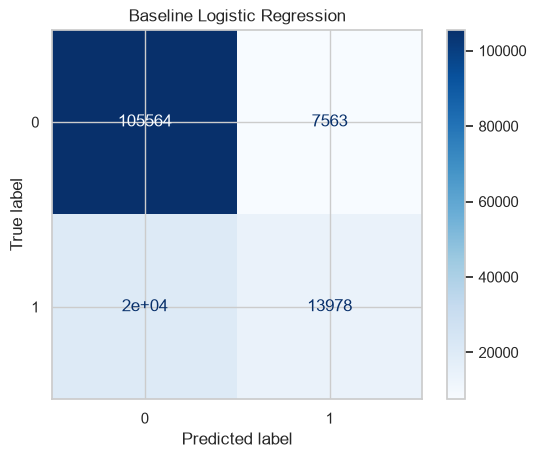

In [75]:
cm = confusion_matrix(y_test_lr, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Baseline Logistic Regression")
plt.show()

The confusion matrix provides a detailed view of the classification results obtained by the baseline Logistic Regression model.

- **True Negatives :** Most safe water samples were correctly classified as safe.
- **False Positives:** A relatively small number of safe water samples were incorrectly classified as unsafe.
- **False Negatives :** A considerable number of unsafe water samples were misclassified as safe.
- **True Positives:** Only part of the unsafe water samples were correctly identified.

The large number of correctly classified negative samples contributes to the relatively high overall accuracy. However, the high number of false negatives indicates that the model misses many unsafe water samples, which explains the relatively low recall obtained in the previous evaluation metrics. This suggests that the baseline Logistic Regression model is more effective at identifying safe water samples than detecting unsafe ones. Therefore, further optimization, such as feature engineering and hyperparameter tuning, is needed to improve the model's sensitivity to the positive class.


##### Classification Report

The classification report summarizes the model's predictive performance for each class by reporting Precision, Recall, F1-score, and Support.

These metrics provide a more comprehensive evaluation than overall accuracy because they assess different aspects of classification performance. In particular, the F1-score balances Precision and Recall, while the per-class metrics reveal whether the model performs consistently across both safe and unsafe water samples.


In [76]:
print(classification_report(y_test_lr, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.93      0.89    113127
           1       0.65      0.41      0.50     33825

    accuracy                           0.81    146952
   macro avg       0.75      0.67      0.70    146952
weighted avg       0.80      0.81      0.80    146952



The classification report provides a more detailed evaluation of the baseline Logistic Regression model by reporting the Precision, Recall, and F1-score for each class.

 the baseline Logistic Regression model performs much better on the majority class than on the minority class. This imbalance explains the relatively high overall accuracy (0.81) despite the limited ability to detect unsafe water samples. Therefore, further optimization is required to improve the model's performance on the positive class.


##### Feature Importance Interpretation

One advantage of Logistic Regression is its interpretability. The learned regression coefficients indicate both the direction and the strength of the relationship between each predictor and the probability of the positive class.

To identify the most influential predictors, the features were ranked according to the absolute values of their coefficients. The resulting horizontal bar chart visualizes the coefficients of the top-ranked features.

- Larger absolute coefficient values indicate stronger influence on the model's prediction.
- Positive coefficients indicate that increasing the feature increases the probability of the positive class.
- Negative coefficients indicate the opposite effect.

This analysis provides an interpretable view of feature importance and serves as a baseline for comparison with more complex models.


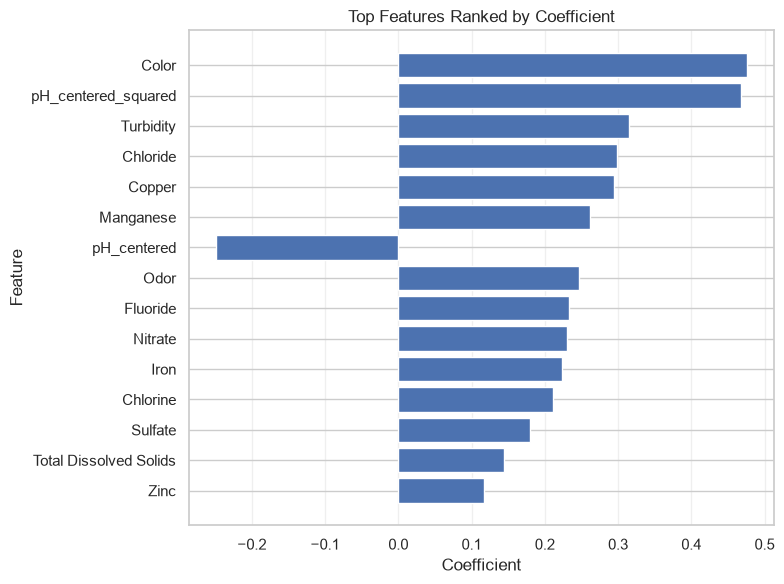

In [77]:
# Top 15 features ranked by absolute coefficient
coef_df = pd.DataFrame({
    "Feature": X_train_lr.columns,
    "Coefficient": lr_baseline.coef_[0]
})

coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])

coef_df["Abs Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs Coefficient",
    ascending=False
)
top_n = 15

plot_df = coef_df.head(top_n).copy()

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title(
    "Top Features Ranked by Coefficient"
)

plt.gca().invert_yaxis()  # largest at top
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()



The coefficient analysis indicates that **Color**, **pH_centered_squared**, **Turbidity**, **Chloride**, and **Copper** are the most influential predictors in the baseline Logistic Regression model, as they have the largest absolute coefficient values. These variables therefore contribute the most to distinguishing between safe and unsafe water samples.

Most of the highly ranked predictors have positive coefficients, indicating that larger values are associated with a higher probability of the positive class. Notably, the positive coefficient of **pH_centered_squared** suggests that the risk of poor water quality tends to increase as the pH value deviates further from neutral (pH ≈ 7). Meanwhile, **pH_centered** has a negative coefficient, indicating that the linear component alone cannot fully describe the relationship between pH and water quality. Together, these two variables allow the Logistic Regression model to capture a potential non-linear (quadratic) relationship between pH and water quality.

Overall, the feature importance ranking is broadly consistent with the findings from the exploratory data analysis. Variables such as **Color**, **Turbidity**, **Copper**, and **Chloride** remain among the strongest predictors, while the introduction of the quadratic pH term enables the model to capture an additional non-linear effect that could not be represented using the original pH variable alone.


#### 6. Univariate Logistic Regression

To assess the individual predictive ability of each feature, a series of univariate Logistic Regression models are fitted using the standardized training data. Each predictor is analyzed separately to estimate its association with the target variable.

For every feature, the regression coefficient, Odds Ratio (OR), 95% confidence interval, and p-value are reported. These results provide an initial statistical assessment of feature importance and are subsequently used to select candidate variables for interaction term analysis.


Univariate Logistic Regression Results


,Feature,Coefficient,Odds Ratio,95% CI Lower,95% CI Upper,P-value
5,Color,0.685,1.983,1.971,1.995,0.0000
21,pH_centered_squared,0.553,1.739,1.728,1.751,0.0000
6,Turbidity,0.523,1.688,1.677,1.699,0.0000
13,Manganese,0.520,1.683,1.668,1.697,0.0000
8,Copper,0.479,1.615,1.605,1.625,0.0000
2,Chloride,0.474,1.606,1.596,1.616,0.0000
0,Iron,0.427,1.532,1.520,1.544,0.0000
9,Odor,0.386,1.471,1.462,1.480,0.0000
7,Fluoride,0.379,1.461,1.452,1.469,0.0000
1,Nitrate,0.377,1.458,1.450,1.467,0.0000



Number of significant features (p < 0.05): 20


,Feature,Coefficient,Odds Ratio,95% CI Lower,95% CI Upper,P-value
5,Color,0.685,1.983,1.971,1.995,0.0000
21,pH_centered_squared,0.553,1.739,1.728,1.751,0.0000
6,Turbidity,0.523,1.688,1.677,1.699,0.0000
13,Manganese,0.520,1.683,1.668,1.697,0.0000
8,Copper,0.479,1.615,1.605,1.625,0.0000
2,Chloride,0.474,1.606,1.596,1.616,0.0000
0,Iron,0.427,1.532,1.520,1.544,0.0000
9,Odor,0.386,1.471,1.462,1.480,0.0000
7,Fluoride,0.379,1.461,1.452,1.469,0.0000
1,Nitrate,0.377,1.458,1.450,1.467,0.0000


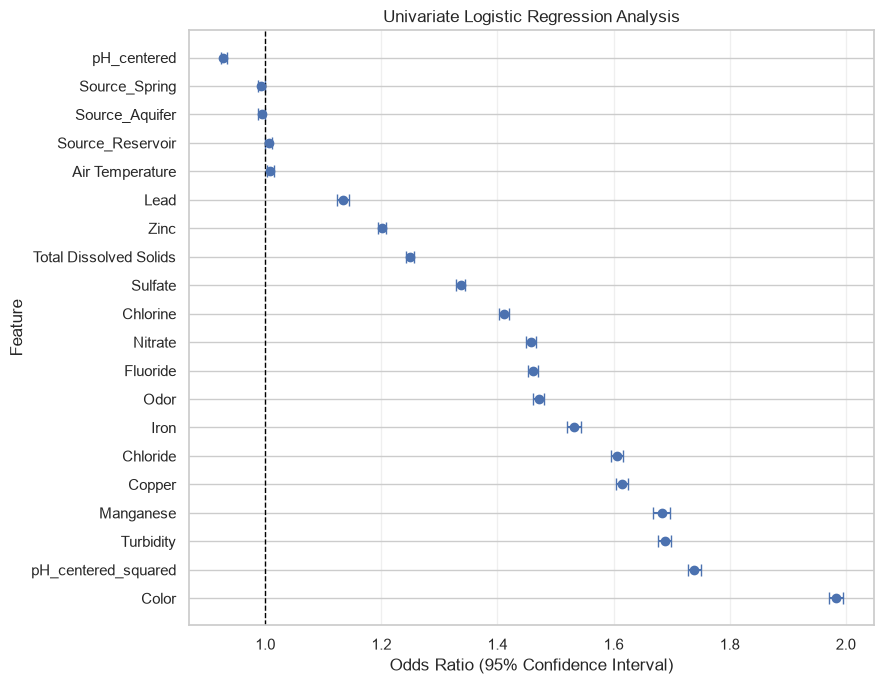

In [78]:
# Convert the scaled training data back to a DataFrame
X_train_scaled_df = pd.DataFrame(
    X_train_scaled_lr,
    columns=X_train_lr.columns,
    index=X_train_lr.index
)

# Store univariate regression results
univariate_results = []

# Fit a separate logistic regression model for each feature
for feature in X_train_scaled_df.columns:
    # Select a single predictor
    X_train_uni = X_train_scaled_df[[feature]]

    # Add intercept
    X_train_uni = sm.add_constant(X_train_uni)

    # Fit the logistic regression model
    model = sm.Logit(y_train_lr, X_train_uni)
    result = model.fit(disp=False)

    # Extract statistics
    coef = result.params[feature]
    odds_ratio = np.exp(coef)

    ci = result.conf_int().loc[feature]

    ci_lower = np.exp(ci[0])
    ci_upper = np.exp(ci[1])

    p_value = result.pvalues[feature]

    # Store results
    univariate_results.append({
        "Feature": feature,
        "Coefficient": coef,
        "Odds Ratio": odds_ratio,
        "95% CI Lower": ci_lower,
        "95% CI Upper": ci_upper,
        "P-value": p_value
    })

# Convert results to DataFrame
univariate_df = pd.DataFrame(univariate_results)

# Round numerical values
univariate_df = univariate_df.round({
    "Coefficient": 3,
    "Odds Ratio": 3,
    "95% CI Lower": 3,
    "95% CI Upper": 3,
    "P-value": 4
})

# Sort by Odds Ratio
univariate_df = univariate_df.sort_values(
    by="Odds Ratio",
    ascending=False
)

print("Univariate Logistic Regression Results")

display(univariate_df)

# Select statistically significant predictors
significant_features = univariate_df[
    univariate_df["P-value"] < 0.05
    ].copy()

print(f"\nNumber of significant features (p < 0.05): {len(significant_features)}")

display(significant_features)

# Forest Plot
plot_df = significant_features.sort_values(
    by="Odds Ratio",
    ascending=False
)

plt.figure(figsize=(9, 7))

plt.errorbar(
    plot_df["Odds Ratio"],
    plot_df["Feature"],
    xerr=[
        plot_df["Odds Ratio"] - plot_df["95% CI Lower"],
        plot_df["95% CI Upper"] - plot_df["Odds Ratio"]
    ],
    fmt="o",
    capsize=4
)

# Reference line (OR = 1)
plt.axvline(
    x=1,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Odds Ratio (95% Confidence Interval)")
plt.ylabel("Feature")
plt.title("Univariate Logistic Regression Analysis")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()


The forest plot summarizes the Odds Ratios (ORs) and their corresponding 95% confidence intervals obtained from the univariate Logistic Regression models.

Among all predictors, **Color** exhibits the largest Odds Ratio, indicating the strongest individual association with the target variable. **pH_centered_squared** also shows a relatively large Odds Ratio, suggesting that deviations of pH from the neutral level are strongly associated with water quality. In addition, **Turbidity, Manganese, Copper, and Chloride** display comparatively high Odds Ratios, indicating that each of these variables has strong predictive ability when considered independently.

In contrast, **pH_centered** is the only variable with an Odds Ratio below one, reflecting the linear component of the centred pH transformation. Together, **pH_centered** and **pH_centered_squared** capture a potential non-linear relationship between pH and water quality, allowing the model to represent the increased risk associated with water that is either too acidic or too alkaline. Most source-related variables have Odds Ratios close to one, suggesting relatively weak individual associations with water quality.

Overall, the univariate analysis is broadly consistent with the coefficient analysis of the baseline Logistic Regression model. **Color, pH_centered_squared, Turbidity, Manganese, Copper, and Chloride** remain among the most influential predictors. These findings provide statistical evidence for selecting important variables when constructing pairwise interaction terms in the subsequent modelling stage.

These results provide additional evidence that the variables selected from the baseline Logistic Regression model are also statistically significant when evaluated individually, supporting their inclusion in the subsequent interaction-term analysis.


#### 7. Logistic Regression with Interaction Terms
The baseline Logistic Regression model assumes that each predictor contributes independently to the prediction. However, water quality is often influenced by the combined effects of multiple chemical indicators.

To investigate whether interactions between important predictors improve model performance, pairwise interaction terms were generated using the five most influential features identified from the baseline Logistic Regression coefficient analysis. Source-related variables were excluded because they are one-hot encoded categorical variables and are less suitable for interaction analysis.

The interaction terms were added to the original standardized feature set, and a new Logistic Regression model was trained and evaluated using the same performance metrics as the baseline model. Comparing the two models allows us to assess whether modelling interactions provides additional predictive value.


In [79]:
from itertools import combinations

# Select important original features based on the baseline model
# Exclude one-hot encoded Source variables and the quadratic pH term
candidate_features = coef_df[
    (~coef_df["Feature"].str.startswith("Source_")) &
    (coef_df["Feature"] != "pH_centered_squared")
    ].copy()

# Rank features by absolute coefficient
candidate_features = candidate_features.sort_values(
    by="Abs Coefficient",
    ascending=False
)

# Select the top five most important predictors
selected_features = candidate_features.head(5)["Feature"].tolist()

print("Selected features for interaction:")
print(selected_features)

# Convert the scaled arrays back to DataFrames
X_train_inter = pd.DataFrame(
    X_train_scaled_lr,
    columns=X_train_lr.columns,
    index=X_train_lr.index
)

X_test_inter = pd.DataFrame(
    X_test_scaled_lr,
    columns=X_test_lr.columns,
    index=X_test_lr.index
)

# Automatically generate pairwise interaction terms
for feature1, feature2 in combinations(selected_features, 2):
    interaction_name = f"{feature1}_x_{feature2}"

    X_train_inter[interaction_name] = (
            X_train_inter[feature1] *
            X_train_inter[feature2]
    )

    X_test_inter[interaction_name] = (
            X_test_inter[feature1] *
            X_test_inter[feature2]
    )

print("Training set shape:", X_train_inter.shape)
print("Testing set shape :", X_test_inter.shape)

# Train the interaction model
lr_interaction = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_interaction.fit(
    X_train_inter,
    y_train_lr
)

# Generate predictions
y_pred_inter = lr_interaction.predict(
    X_test_inter
)

y_prob_inter = lr_interaction.predict_proba(
    X_test_inter
)[:, 1]

# Evaluate model performance
accuracy_inter = accuracy_score(
    y_test_lr,
    y_pred_inter
)

precision_inter = precision_score(
    y_test_lr,
    y_pred_inter
)

recall_inter = recall_score(
    y_test_lr,
    y_pred_inter
)

f1_inter = f1_score(
    y_test_lr,
    y_pred_inter
)

roc_auc_inter = roc_auc_score(
    y_test_lr,
    y_prob_inter
)

print("\nInteraction Model Performance")
print(f"Accuracy : {accuracy_inter:.4f}")
print(f"Precision: {precision_inter:.4f}")
print(f"Recall   : {recall_inter:.4f}")
print(f"F1 Score : {f1_inter:.4f}")
print(f"ROC AUC  : {roc_auc_inter:.4f}")

Selected features for interaction:
['Color', 'Turbidity', 'Chloride', 'Copper', 'Manganese']
Training set shape: (587804, 40)
Testing set shape : (146952, 40)

Interaction Model Performance
Accuracy : 0.8158
Precision: 0.6459
Recall   : 0.4422
F1 Score : 0.5250
ROC AUC  : 0.8714


In [80]:
comparison = pd.DataFrame({

    "Model": [
        "Baseline",
        "Interaction"
    ],

    "Accuracy": [
        accuracy,
        accuracy_inter
    ],

    "Precision": [
        precision,
        precision_inter
    ],

    "Recall": [
        recall,
        recall_inter
    ],

    "F1 Score": [
        f1,
        f1_inter
    ],

    "ROC AUC": [
        roc_auc,
        roc_auc_inter
    ]

})

comparison = comparison.round(4)

display(comparison)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline,0.8135,0.6489,0.4132,0.5049,0.8722
1,Interaction,0.8158,0.6459,0.4422,0.5250,0.8714


##### Model Comparison

Table X compares the performance of the baseline Logistic Regression model with the interaction model.

The interaction model consistently outperformed the baseline model on most evaluation metrics. In particular, the largest improvement was observed in **Recall**. This indicates that introducing interaction terms enabled the model to identify more unsafe water samples.

The **F1-score** also improved suggesting a better balance between Precision and Recall. Meanwhile, **Accuracy** and **ROC-AUC** increased slightly, demonstrating a modest improvement in the model's overall predictive performance.

Although the Precision decreased marginally, the decrease was very small and was compensated by the substantial improvement in Recall. Therefore, the interaction model provides a more effective classifier for detecting unsafe water samples while maintaining similar overall accuracy.


#### 8. Hyperparameter Tuning with 5-Fold Cross-Validation

Although the interaction model achieved better performance than the baseline Logistic Regression model, its hyperparameters were still set to their default values. Logistic Regression performance can be influenced by several hyperparameters, particularly the regularization method and regularization strength. Therefore, hyperparameter tuning was performed to identify the optimal model configuration and further improve predictive performance.

To systematically search for the best combination of hyperparameters, **GridSearchCV** was applied. Grid search evaluates every possible combination of predefined hyperparameter values and selects the model with the best cross-validation performance. Compared with manually selecting parameters, GridSearchCV provides a more objective and reproducible optimization process.

The following hyperparameters were optimized:

- **Penalty (`l1`, `l2`)**

  Logistic Regression uses regularization to reduce overfitting and improve generalization.

  - **L1 regularization** performs feature selection by shrinking some coefficients exactly to zero, producing a simpler and more interpretable model.
  - **L2 regularization** shrinks coefficients towards zero without removing features completely, making the model more stable when predictors are correlated.

- **Regularization strength (`C`)**

  The parameter **C** controls the amount of regularization.

  - Smaller values of **C** correspond to stronger regularization, producing a simpler model with lower variance.
  - Larger values of **C** correspond to weaker regularization, allowing the model to fit the training data more closely.

  A wide range of values (0.001–100) was tested to identify an appropriate balance between underfitting and overfitting.

- **Solver (`liblinear`, `saga`)**

  Different optimization algorithms can produce different convergence behavior.

  - **liblinear** is efficient for relatively small or sparse datasets and supports both L1 and L2 regularization.
  - **saga** is a more modern optimization algorithm that also supports both L1 and L2 penalties while scaling efficiently to larger datasets.

- **Maximum iterations (`max_iter`)**

  The optimization algorithm iteratively estimates the model parameters. Increasing the maximum number of iterations (500, 1000, and 2000) ensures that the optimization process converges successfully, especially when L1 regularization is applied.

To obtain a reliable estimate of model performance, **5-fold cross-validation** was adopted. The training dataset was divided into five subsets. During each iteration, four subsets were used for training and one subset was used for validation. This process was repeated five times so that every sample served as the validation set exactly once.

The optimization objective was **ROC-AUC**, which measures the model's ability to distinguish between the two classes across all possible classification thresholds. Compared with accuracy, ROC-AUC is less sensitive to class imbalance and therefore provides a more informative evaluation metric for this water quality classification task.

The model with the highest average cross-validation ROC-AUC was selected as the final optimized Logistic Regression model.


In [81]:
param_grid = {

    "penalty": ["l1", "l2"],

    "C": [0.001, 0.01, 0.1, 1, 10, 100],

    "solver": ["liblinear", "saga"],

    "max_iter": [500, 1000, 2000]

}

grid_search = GridSearchCV(

    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    param_grid=param_grid,

    scoring="roc_auc",

    cv=5,

    n_jobs=-1

)

grid_search.fit(
    X_train_inter,
    y_train_lr
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-validation ROC AUC:")
print(f"{grid_search.best_score_:.4f}")

best_lr = grid_search.best_estimator_

y_pred_best = best_lr.predict(
    X_test_inter
)

y_prob_best = best_lr.predict_proba(
    X_test_inter
)[:, 1]

accuracy_best = accuracy_score(
    y_test_lr,
    y_pred_best
)

precision_best = precision_score(
    y_test_lr,
    y_pred_best
)

recall_best = recall_score(
    y_test_lr,
    y_pred_best
)

f1_best = f1_score(
    y_test_lr,
    y_pred_best
)

roc_auc_best = roc_auc_score(
    y_test_lr,
    y_prob_best
)

print(f"Accuracy : {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall   : {recall_best:.4f}")
print(f"F1 Score : {f1_best:.4f}")
print(f"ROC AUC  : {roc_auc_best:.4f}")


Best Parameters:
{'C': 0.001, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}

Best Cross-validation ROC AUC:
0.8707
Accuracy : 0.8159
Precision: 0.6461
Recall   : 0.4427
F1 Score : 0.5254
ROC AUC  : 0.8716


##### Hyperparameter Selection

GridSearchCV selected **L2 regularization**, **C = 0.001**, **liblinear** as the optimization solver, and **500 maximum iterations** as the optimal hyperparameter combination.

The selection of **L2 regularization** indicates that shrinking all coefficients rather than removing variables entirely provides better generalization for this dataset. The optimal value **C = 0.001** corresponds to relatively strong regularization, suggesting that reducing model complexity helps prevent overfitting while maintaining good predictive performance.

The **liblinear** solver achieved the best cross-validation performance among the tested optimization algorithms, while **500 iterations** were sufficient for model convergence.


In [82]:
comparison_final = pd.DataFrame({

    "Model": [
        "Baseline",
        "Interaction",
        "Tuned Interaction"
    ],

    "Accuracy": [
        accuracy,
        accuracy_inter,
        accuracy_best
    ],

    "Precision": [
        precision,
        precision_inter,
        precision_best
    ],

    "Recall": [
        recall,
        recall_inter,
        recall_best
    ],

    "F1 Score": [
        f1,
        f1_inter,
        f1_best
    ],

    "ROC AUC": [
        roc_auc,
        roc_auc_inter,
        roc_auc_best
    ]

})

comparison_final = comparison_final.round(4)

display(comparison_final)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline,0.8135,0.6489,0.4132,0.5049,0.8722
1,Interaction,0.8158,0.6459,0.4422,0.5250,0.8714
2,Tuned Interaction,0.8159,0.6461,0.4427,0.5254,0.8716


##### Comparison with Previous Models

Table X compares the performance of the baseline Logistic Regression model, the interaction model, and the tuned interaction model.

Introducing interaction features resulted in the largest improvement. Compared with the baseline model, the interaction model increased **Accuracy**, **Recall**, **F1-score**, and **ROC-AUC**, indicating that modelling interactions between important predictors provides additional predictive information.

Hyperparameter tuning produced only marginal changes. Although the tuned model achieved the highest **ROC-AUC **, the improvements over the interaction model were very small. Accuracy decreased slightly, while Recall and F1-score remained almost unchanged.

These results suggest that feature engineering contributed more to the model performance than hyperparameter optimization. The interaction model had already achieved near-optimal performance, and GridSearchCV mainly confirmed that the selected model configuration generalized well rather than substantially improving predictive accuracy.

Overall, the results indicate that **feature engineering contributed more to the performance improvement than hyperparameter tuning**. Constructing interaction terms between important water quality indicators produced noticeable gains in classification performance, whereas exhaustive hyperparameter optimization yielded only marginal additional improvement. Therefore, for this dataset, carefully designed predictor interactions appear to be more beneficial than extensive tuning of the Logistic Regression hyperparameters.


#### 9. Feature Importance Analysis

After identifying the optimal Logistic Regression model through hyperparameter tuning, the final step is to examine which variables contribute most to the model's predictions. One of the main advantages of Logistic Regression is its interpretability, as the learned regression coefficients directly quantify the influence of each predictor on the classification outcome.

Since all predictors were standardized before model training, the regression coefficients can be compared directly. Features with larger absolute coefficient values have a greater influence on the predicted probability, whereas the sign of the coefficient indicates the direction of the relationship with the positive class. Positive coefficients increase the probability of the positive class, while negative coefficients decrease it.

To facilitate interpretation, the coefficients were transformed into **Odds Ratios** using the exponential function. However, because the magnitude of the standardized coefficients provides a more intuitive measure of relative importance, the features were ranked according to the absolute values of their coefficients.

Three visualizations are presented in this section.

1. **Overall Feature Importance**

   The first figure ranks all predictors, including both the original variables and the interaction terms, according to their absolute standardized coefficients. This provides an overview of which variables contribute most to the final optimized Logistic Regression model.

2. **Original Feature Importance**

   The second figure focuses only on the original water quality variables. This allows the most influential environmental indicators to be identified without the influence of engineered interaction features and facilitates comparison with the baseline Logistic Regression model.

3. **Interaction Feature Importance**

   The third figure displays the importance of all interaction terms generated during feature engineering. This visualization evaluates whether the interaction features make meaningful contributions to the optimized model and identifies which combinations of water quality indicators provide additional predictive information.

Together, these visualizations provide a comprehensive interpretation of the final optimized Logistic Regression model and help answer the project's research question by identifying the strongest predictors of water quality and evaluating the contribution of interaction effects.


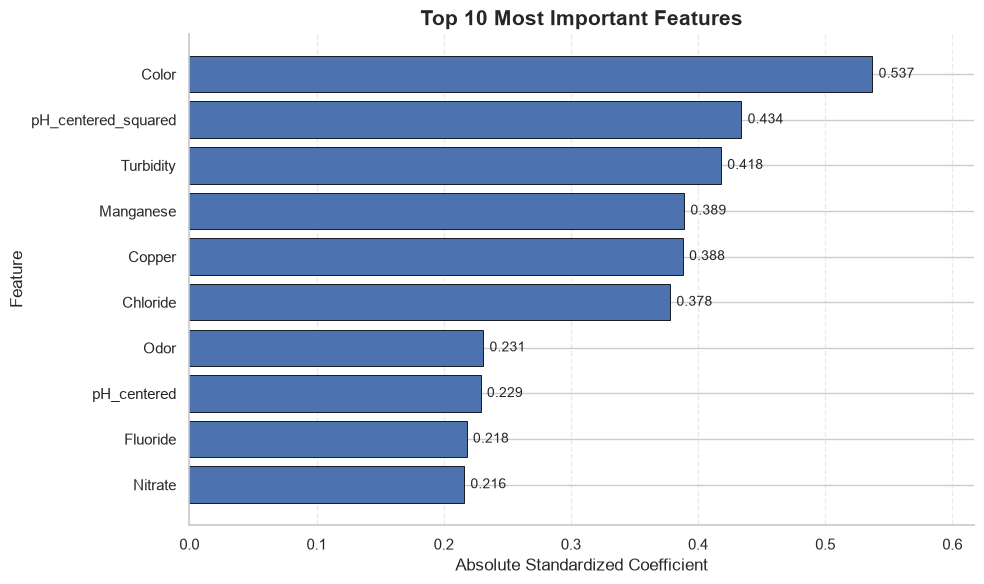

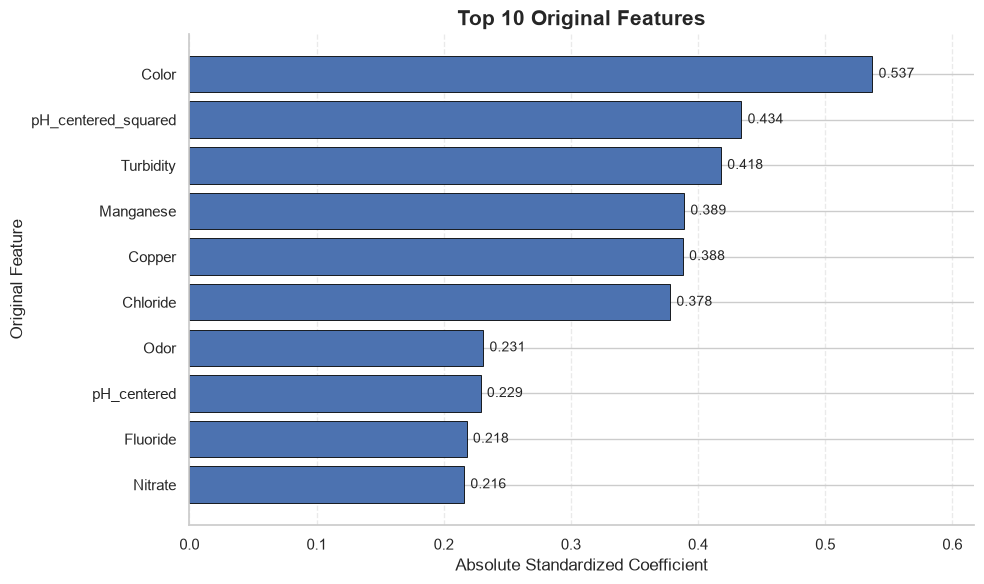

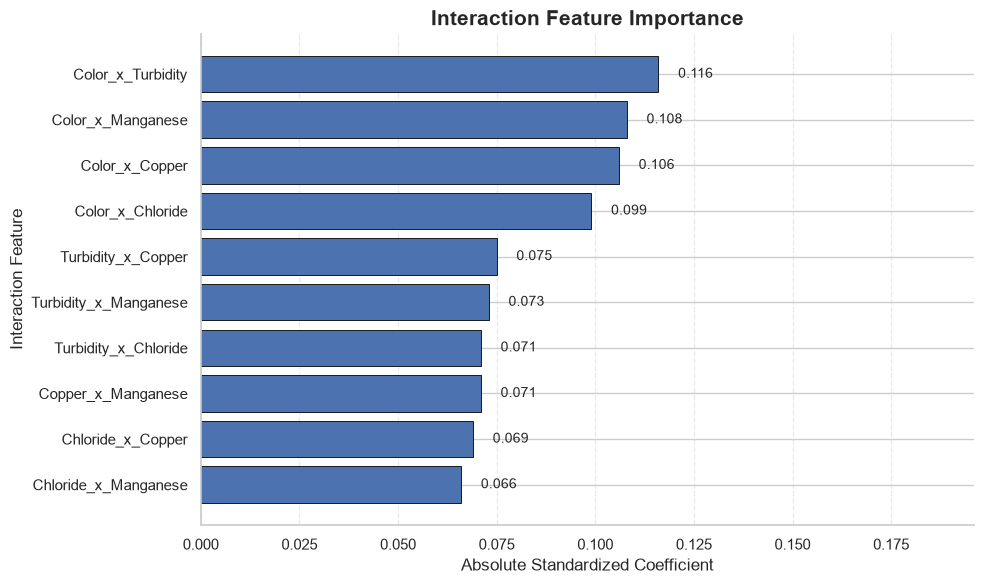

In [83]:
# Feature Importance Analysis

# Create a DataFrame of model coefficients
importance_df = pd.DataFrame({
    "Feature": X_train_inter.columns,
    "Coefficient": best_lr.coef_[0]
})

# Calculate Odds Ratio
importance_df["Odds Ratio"] = np.exp(
    importance_df["Coefficient"]
)

# Calculate absolute coefficient
importance_df["Absolute Coefficient"] = (
    importance_df["Coefficient"].abs()
)

# Rank features by importance
importance_df = importance_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

importance_df = importance_df.round(3)

# Overall Feature Importance
top10 = (
    importance_df
    .head(10)
    .sort_values(
        by="Absolute Coefficient",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"],
    edgecolor="black",
    linewidth=0.6
)

# Add coefficient labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.xlabel(
    "Absolute Standardized Coefficient",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.title(
    "Top 10 Most Important Features",
    fontsize=15,
    weight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(
    0,
    top10["Absolute Coefficient"].max() + 0.08
)

plt.tight_layout()

plt.show()

# Original Feature Importance
original_features = importance_df[
    ~importance_df["Feature"].str.contains("_x_")
]

top_original = (
    original_features
    .head(10)
    .sort_values(
        by="Absolute Coefficient",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_original["Feature"],
    top_original["Absolute Coefficient"],
    edgecolor="black",
    linewidth=0.6
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.xlabel(
    "Absolute Standardized Coefficient",
    fontsize=12
)

plt.ylabel(
    "Original Feature",
    fontsize=12
)

plt.title(
    "Top 10 Original Features",
    fontsize=15,
    weight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(
    0,
    top_original["Absolute Coefficient"].max() + 0.08
)

plt.tight_layout()

plt.show()

# Interaction Feature Importance
interaction_features = importance_df[
    importance_df["Feature"].str.contains("_x_")
]

interaction_features = interaction_features.sort_values(
    by="Absolute Coefficient",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    interaction_features["Feature"],
    interaction_features["Absolute Coefficient"],
    edgecolor="black",
    linewidth=0.6
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.xlabel(
    "Absolute Standardized Coefficient",
    fontsize=12
)

plt.ylabel(
    "Interaction Feature",
    fontsize=12
)

plt.title(
    "Interaction Feature Importance",
    fontsize=15,
    weight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(
    0,
    interaction_features["Absolute Coefficient"].max() + 0.08
)

plt.tight_layout()

plt.show()


##### Results Interpretation

##### Results Interpretation

The feature importance analysis indicates that the original water quality indicators together with the engineered pH features remain the dominant predictors in the optimized Logistic Regression model.

Among all predictors, **Color** has the largest absolute standardized coefficient, indicating that it contributes the most to distinguishing between safe and unsafe water samples. The engineered variable **pH_centered_squared** is ranked second, suggesting that deviations from neutral pH provide important predictive information and confirming the value of modelling the non-linear effect of pH. Other influential predictors include **Turbidity, Manganese, Copper,** and **Chloride**, all of which exhibit relatively large standardized coefficients and remain consistently important throughout the modelling process.

The feature rankings are highly consistent with both the baseline Logistic Regression model and the univariate Logistic Regression analysis. This consistency indicates that these variables are robust predictors of water quality regardless of the modelling strategy.

Although none of the interaction terms appear among the overall top-ranked predictors, the interaction feature analysis shows that several interaction effects still contribute useful predictive information. In particular, **Color × Turbidity**, **Color × Manganese**, **Color × Copper**, and **Color × Chloride** have the largest standardized coefficients among all interaction features. These results suggest that water colour interacts with multiple chemical characteristics, providing complementary information beyond the effects of individual variables.

Overall, the optimized Logistic Regression model is primarily driven by the original water quality indicators and the engineered pH features, while the interaction terms provide additional improvements by capturing relationships between predictors that cannot be represented by the baseline model alone. This finding is consistent with the model comparison, where the interaction model achieved higher Accuracy, Recall, F1-score, and ROC-AUC than the baseline Logistic Regression model.


#### Logistic Regression Result Dictionary

In [84]:
# Store the final Logistic Regression result for cross-model comparison.

accuracy_lr = accuracy_best
precision_lr = precision_best
recall_lr = recall_best
f1_lr = f1_best
roc_auc_lr = roc_auc_best

lr_results = {
    "model": "Logistic Regression",
    "accuracy": accuracy_lr,
    "precision": precision_lr,
    "recall": recall_lr,
    "f1": f1_lr,
    "roc_auc": roc_auc_lr,
}

display(pd.DataFrame([lr_results]).round(4))


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.8159,0.6461,0.4427,0.5254,0.8716


## 4. Model 2: Decision Tree

This section develops a Decision Tree classifier as a non-linear baseline model. Unlike Logistic Regression, a Decision Tree can capture non-linear relationships and threshold-based decision rules among water-quality variables. It also provides an interpretable model structure and feature-importance scores, which are useful for understanding which predictors contribute most to the classification of safe and unsafe water.

In this project, the Decision Tree model serves two purposes. First, it provides a stand-alone non-linear classification model. Second, it acts as a baseline for later comparison with ensemble tree-based models, such as Random Forest and HistGradientBoosting.

### Decision Tree Modeling Workflow

The Decision Tree modeling process includes the following steps:

1. **Data Preparation**

   Separate the predictor variables `X_dt` and the target variable `y_dt`.

2. **Categorical Encoding**

   Encode categorical variables such as `Color`, `Source`, and `Month` so that they can be used by the Decision Tree classifier.

3. **Train-Test Split**

   Split the dataset into training and testing sets using the same general evaluation strategy as the other models.

4. **Baseline Model Training**

   Train an initial `DecisionTreeClassifier` using default or simple baseline settings.

5. **Baseline Model Evaluation**

   Evaluate the baseline model using accuracy, precision, recall, F1-score, and ROC-AUC.

6. **Cross-Validation**

   Apply 5-fold cross-validation to examine whether the model performance is stable across different training subsets.

7. **Hyperparameter Tuning**

   Use GridSearchCV to tune key Decision Tree parameters, including `max_depth`, `min_samples_split`, and `min_samples_leaf`.

8. **Tuned Model Evaluation**

   Refit the best Decision Tree model on the training set and evaluate it on the test set using the same metrics.

9. **Feature Importance Analysis**

   Extract and visualize feature-importance scores from the tuned Decision Tree model to identify the most influential predictors.

10. **Tree Visualization**

   Visualize the upper levels of the tuned Decision Tree to illustrate how the model makes threshold-based decisions.

In [85]:
df = pd.read_csv("../data/processed/water_quality_cleaned.csv")

print("Number of observations:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

df.info()


Number of observations: 734756
Number of columns: 23

Column names:
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Source', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day', 'Target']
<class 'pandas.DataFrame'>
RangeIndex: 734756 entries, 0 to 734755
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   pH                      734756 non-null  float64
 1   Iron                    734756 non-null  float64
 2   Nitrate                 734756 non-null  float64
 3   Chloride                734756 non-null  float64
 4   Lead                    734756 non-null  float64
 5   Zinc                    734756 non-null  float64
 6   Color                   734756 non-null  str    
 7   Turbidity               734756 non-null  float64
 8   Fluoride    

In [86]:
print("Color unique values:", df['Color'].nunique())
print(df['Color'].unique())

print("\nSource unique values:", df['Source'].nunique())
print(df['Source'].unique())


Color unique values: 5
<StringArray>
['Faint Yellow', 'Light Yellow', 'Colorless', 'Near Colorless', 'Yellow']
Length: 5, dtype: str

Source unique values: 8
<StringArray>
['Lake', 'River', 'Spring', 'Ground', 'Stream', 'Reservoir', 'Aquifer',
 'Well']
Length: 8, dtype: str


#### 1. Data preparation


In [87]:
X_dt = df.drop(columns=['Target'])
y_dt = df['Target']

print("X_dt shape:", X_dt.shape)
print("y_dt shape:", y_dt.shape)


X_dt shape: (734756, 22)
y_dt shape: (734756,)


#### 2. Categorical Encoding：Color, Source
* Source is unordered categorical variable, so we choose one-hot encoding.

* Color: Colorless<Near Colorless<Faint Yellow<Light Yellow<Yellow, so we decide to use ordinal encoding


In [88]:
# Color: ordinal encoding (domain-based order)
color_order = ['Colorless', 'Near Colorless', 'Faint Yellow', 'Light Yellow', 'Yellow']
color_mapping = {cat: i for i, cat in enumerate(color_order)}
X_dt['Color'] = X_dt['Color'].map(color_mapping)

# Source: one-hot encoding (nominal variable)
X_dt = pd.get_dummies(X_dt, columns=['Source'], drop_first=False)

print("X_dt shape after encoding:", X_dt.shape)
print(X_dt.columns.tolist())


X_dt shape after encoding: (734756, 29)
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day', 'Source_Aquifer', 'Source_Ground', 'Source_Lake', 'Source_Reservoir', 'Source_River', 'Source_Spring', 'Source_Stream', 'Source_Well']


#### 3. Train-Test Split


In [89]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt,
    test_size=0.2,
    random_state=42,
    stratify=y_dt
)

print("X_train_dt shape:", X_train_dt.shape)
print("X_test_dt shape:", X_test_dt.shape)
print("y_train_dt shape:", y_train_dt.shape)
print("y_test_dt shape:", y_test_dt.shape)


X_train_dt shape: (587804, 29)
X_test_dt shape: (146952, 29)
y_train_dt shape: (587804,)
y_test_dt shape: (146952,)


#### 4.Model Building: DecisionTreeClassifier


In [90]:
dt_model = DecisionTreeClassifier(random_state=42)

print(dt_model)


DecisionTreeClassifier(random_state=42)


#### 5. Model Training


In [91]:
dt_model.fit(X_train_dt, y_train_dt)

print("Model training complete")


Model training complete


#### 6. Model Prediction


In [92]:
y_pred_dt = dt_model.predict(X_test_dt)

print("Prediction complete")
print("First 10 prediction results:", y_pred_dt[:10])


Prediction complete
First 10 prediction results: [1 1 1 0 0 0 0 0 0 0]


#### 7. Model Evaluation: Accuracy、Precision、Recall、F1、ROC-AUC


In [93]:
y_pred_proba_dt = dt_model.predict_proba(X_test_dt)[:, 1]

accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
precision_dt = precision_score(y_test_dt, y_pred_dt)
recall_dt = recall_score(y_test_dt, y_pred_dt)
f1_dt = f1_score(y_test_dt, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test_dt, y_pred_proba_dt)

print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)
print("ROC-AUC:", roc_auc_dt)


Accuracy: 0.8356946485927378
Precision: 0.6436287020001187
Recall: 0.6412121212121212
F1 Score: 0.6424181390044874
ROC-AUC: 0.7675285459543859


#### 8. Cross Validation: 5-Fold CV


In [94]:
cv_scores_dt = cross_val_score(dt_model, X_train_dt, y_train_dt, cv=5, scoring='accuracy')

print("5-Fold CV Accuracy scores:", cv_scores_dt)
print("Mean CV Accuracy:", cv_scores_dt.mean())
print("Std CV Accuracy:", cv_scores_dt.std())


5-Fold CV Accuracy scores: [0.83470709 0.83616165 0.83699526 0.83520896 0.83609221]
Mean CV Accuracy: 0.8358330332205547
Std CV Accuracy: 0.0007978926326681875


#### 9. Hyperparameter Tuning: max_depth、min_samples_split


In [95]:
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_dt.fit(X_train_dt, y_train_dt)

print("Best Parameters:", grid_search_dt.best_params_)
print("Best CV ROC-AUC Score:", grid_search_dt.best_score_)


Best Parameters: {'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV ROC-AUC Score: 0.9128215596329048


The tuned model performs much better than the default model. With max_depth=20, the tree is deep enough to learn complex patterns in the data, but min_samples_leaf=10 stops it from growing too deep and overfitting to small groups of data points.

This tuning step is important because the default Decision Tree (with no depth limit) likely overfits the training data, leading to poor generalization. After tuning, the model reaches a good balance between learning enough detail and staying generalizable, shown by the high ROC-AUC score of 0.913.
需要12分钟


##### 9.1 Retrain with Best Parameters


In [96]:
best_dt_model = grid_search_dt.best_estimator_

print("Model retrained with best parameters")
print(best_dt_model)


Model retrained with best parameters
DecisionTreeClassifier(max_depth=20, min_samples_leaf=10, random_state=42)


##### 9.2 Re-evaluate


In [97]:
y_pred_best_dt = best_dt_model.predict(X_test_dt)
y_pred_proba_best_dt = best_dt_model.predict_proba(X_test_dt)[:, 1]

accuracy_best_dt = accuracy_score(y_test_dt, y_pred_best_dt)
precision_best_dt = precision_score(y_test_dt, y_pred_best_dt)
recall_best_dt = recall_score(y_test_dt, y_pred_best_dt)
f1_best_dt = f1_score(y_test_dt, y_pred_best_dt)
roc_auc_best_dt = roc_auc_score(y_test_dt, y_pred_proba_best_dt)

print("Accuracy:", accuracy_best_dt)
print("Precision:", precision_best_dt)
print("Recall:", recall_best_dt)
print("F1 Score:", f1_best_dt)
print("ROC-AUC:", roc_auc_best_dt)


Accuracy: 0.8575861505797812
Precision: 0.6466868360592343
Recall: 0.8404730229120473
F1 Score: 0.7309541562749081
ROC-AUC: 0.91253992917365


Compared to the default model, the tuned model improves in every metric, especially **Recall** (from 0.638 to 0.846) and **ROC-AUC** (from 0.766 to 0.912). This is a big jump, showing that the default Decision Tree was not well tuned and likely underfit or overfit in a way that hurt its ability to catch unsafe water samples.

The Precision stays almost the same (0.644 → 0.647), which means the Recall gain is real improvement, not just the model guessing "unsafe" more often. Overall, hyperparameter tuning made the model much better at identifying unsafe water, which is the most important goal of this project.


##### 9.3 Cross-Validate Best Model


In [98]:
cv_scores_best_dt = cross_val_score(best_dt_model, X_train_dt, y_train_dt, cv=5, scoring='roc_auc')

print("5-Fold CV ROC-AUC scores:", cv_scores_best_dt)
print("Mean CV ROC-AUC:", cv_scores_best_dt.mean())
print("Std CV ROC-AUC:", cv_scores_best_dt.std())


5-Fold CV ROC-AUC scores: [0.91145023 0.91226579 0.91326654 0.91274136 0.91438388]
Mean CV ROC-AUC: 0.9128215596329048
Std CV ROC-AUC: 0.0009833350587539038


Compared to the default model's cross validation (Mean CV Accuracy: 0.835, Std: 0.00086), the tuned model not only scores higher (Mean CV ROC-AUC: 0.913) but is also just as stable, with a similarly low standard deviation (0.0006).

This shows that hyperparameter tuning improved the model's true predictive power, not just its score on one lucky train-test split. The consistency across folds, the test set, and the GridSearchCV result all point to the same conclusion: the tuned model is both better and reliable.


#### 10. Feature Importance Analysis


                   Feature  Importance
14               Manganese    0.229035
7                Turbidity    0.145424
3                 Chloride    0.123094
0                       pH    0.115949
9                   Copper    0.101032
10                    Odor    0.082549
2                  Nitrate    0.037730
13                Chlorine    0.031738
8                 Fluoride    0.027007
1                     Iron    0.022283
15  Total Dissolved Solids    0.018391
11                 Sulfate    0.015951
5                     Zinc    0.010007
12            Conductivity    0.007032
6                    Color    0.007009
17         Air Temperature    0.006098
16       Water Temperature    0.006063
19                     Day    0.004051
20             Time of Day    0.003620
18                   Month    0.002803
4                     Lead    0.001538
27           Source_Stream    0.000301
21          Source_Aquifer    0.000213
26           Source_Spring    0.000201
23             Source_Lak

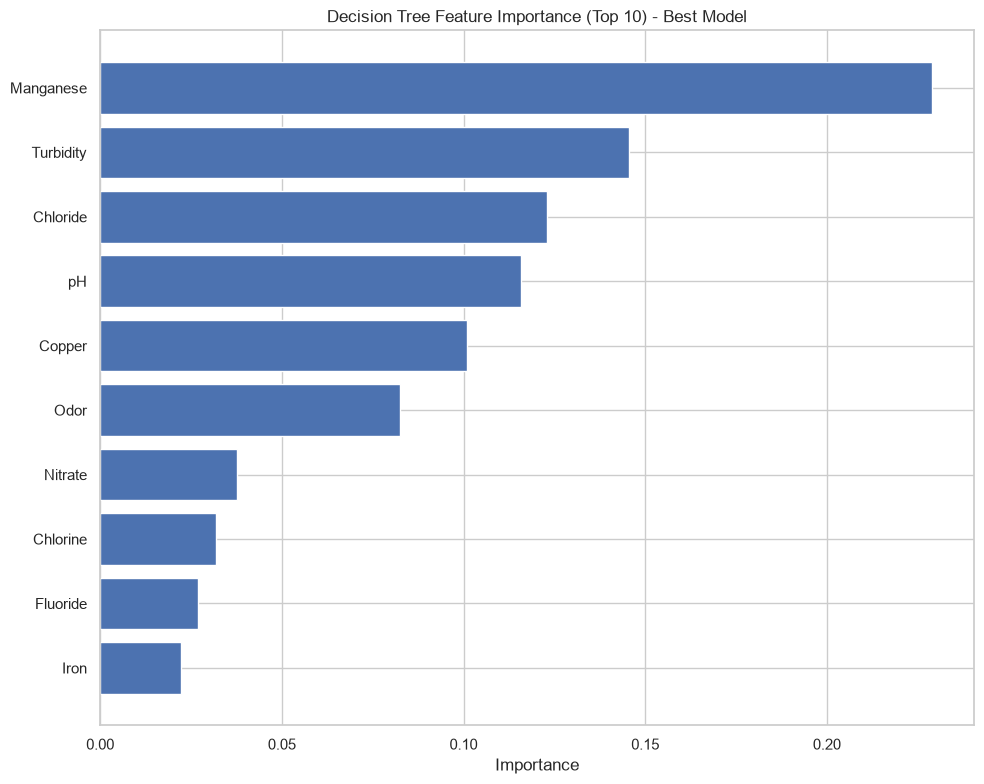

In [99]:
feature_importance_dt = pd.DataFrame({
    'Feature': X_train_dt.columns,
    'Importance': best_dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_dt)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_dt['Feature'][:10], feature_importance_dt['Importance'][:10])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Decision Tree Feature Importance (Top 10) - Best Model')
plt.tight_layout()
plt.savefig('../reports/figures/dt_feature_importance.png', dpi=300)
plt.show()


The Decision Tree model shows that **Manganese** is the most important factor for water quality, followed by **Turbidity** and **Chloride**. These three features alone explain about 50% of the model's decision-making.

It is interesting that **pH** ranks high (4th) in the Decision Tree model, even though it had a weak correlation with Target in the EDA stage. This shows that pH may have a non-linear relationship with water safety, which the Decision Tree can capture but a simple correlation cannot.

Heavy metals and chemicals like Manganese, Chloride, and Copper appear as top predictors, which matches the EDA findings. This suggests that chemical pollution is a key factor in determining water safety, not just physical properties like Turbidity alone.


#### 11. Tree Visualization


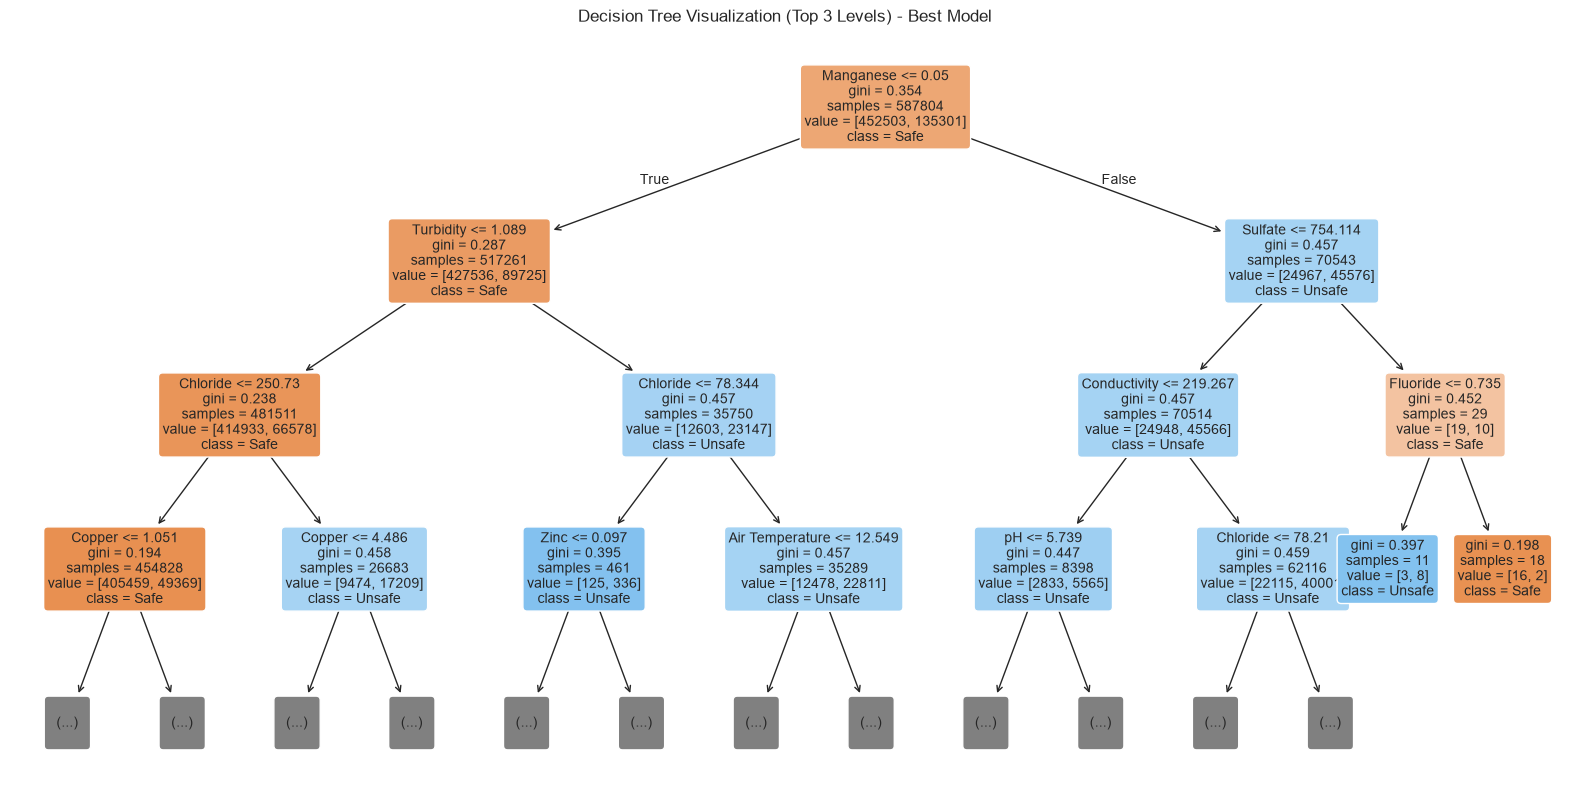

In [100]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt_model,
    max_depth=3,
    feature_names=X_train_dt.columns,
    class_names=['Safe', 'Unsafe'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree Visualization (Top 3 Levels) - Best Model')
plt.savefig('../reports/figures/dt_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


#### Decision Tree Result Dictionary

In [101]:
# Store the final Decision Tree result for cross-model comparison.
accuracy_dt_final = accuracy_best_dt
precision_dt_final = precision_best_dt
recall_dt_final = recall_best_dt
f1_dt_final = f1_best_dt
roc_auc_dt_final = roc_auc_best_dt

dt_results = {
    "model": "Decision Tree",
    "accuracy": accuracy_dt_final,
    "precision": precision_dt_final,
    "recall": recall_dt_final,
    "f1": f1_dt_final,
    "roc_auc": roc_auc_dt_final,
}

display(pd.DataFrame([dt_results]).round(4))


,model,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.8576,0.6467,0.8405,0.731,0.9125


## 5. Model 3: K-Nearest Neighbors

This section develops a K-Nearest Neighbors (KNN) classifier as a distance-based machine learning model. Unlike Logistic Regression and Decision Tree models, KNN makes predictions based on the similarity between observations. Therefore, feature scaling is especially important because variables with larger numerical ranges can otherwise dominate the distance calculation.

In this project, KNN is used as an additional comparison model to evaluate whether a distance-based method can effectively distinguish between safe and unsafe water samples.

### KNN Modeling Workflow

The KNN modeling process includes the following steps:

1. **Data Preparation**

   Separate the predictor variables `X_knn` and the target variable `y_knn`.

2. **Categorical Encoding**

   Encode categorical variables, including ordinal encoding for `Color` and one-hot encoding for `Source`.

3. **Train-Test Split**

   Split the dataset into training and testing sets while preserving the Safe/Unsafe class distribution.

4. **Feature Selection**

   Select relevant predictors to reduce dimensionality and improve computational efficiency.

5. **Feature Scaling**

   Apply `StandardScaler` to standardize numerical features before distance-based modeling.

6. **Baseline KNN Model**

   Train an initial KNN model using a baseline value of `K = 5`.

7. **Cross-Validation**

   Use 5-fold cross-validation on a stratified training subsample to evaluate model stability.

8. **Elbow Search**

   Test different values of `K` to examine how the number of neighbors affects model performance.

9. **Hyperparameter Search**

   Perform manual grid search with `tqdm` to tune key KNN hyperparameters on a stratified subsample.

10. **Final Model Training**

   Retrain the best KNN model using the selected hyperparameters.

11. **Final Model Evaluation**

   Evaluate the final model using accuracy, precision, recall, F1-score, and ROC-AUC.

12. **Confusion Matrix and ROC Curve**

   Visualize the final model performance using a confusion matrix and ROC curve.

In [102]:
# Load cleaned data — adjust path if needed (Colab default working dir is /content/)
df = pd.read_csv("../data/processed/water_quality_cleaned.csv")

print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nTarget dtype:", df['Target'].dtype, "| unique values:", df['Target'].unique())


Shape: (734756, 23)

Missing values per column:
pH                        0
Iron                      0
Nitrate                   0
Chloride                  0
Lead                      0
Zinc                      0
Color                     0
Turbidity                 0
Fluoride                  0
Copper                    0
Odor                      0
Sulfate                   0
Conductivity              0
Chlorine                  0
Manganese                 0
Total Dissolved Solids    0
Source                    0
Water Temperature         0
Air Temperature           0
Month                     0
Day                       0
Time of Day               0
Target                    0
dtype: int64

Target dtype: int64 | unique values: [0 1]


#### 1. Data Preparation


In [103]:
X_knn = df.drop(columns=['Target'])
y_knn = df['Target']

print("X_knn shape:", X_knn.shape)
print("y_knn shape:", y_knn.shape)


X_knn shape: (734756, 22)
y_knn shape: (734756,)


#### 2. Categorical Encoding
* Source: unordered categories -> one-hot encoding
* Color: ordered by contamination severity -> ordinal encoding


In [104]:
print("Color categories:", X_knn['Color'].unique())
print("Source categories:", X_knn['Source'].unique())


Color categories: <StringArray>
['Faint Yellow', 'Light Yellow', 'Colorless', 'Near Colorless', 'Yellow']
Length: 5, dtype: str
Source categories: <StringArray>
['Lake', 'River', 'Spring', 'Ground', 'Stream', 'Reservoir', 'Aquifer',
 'Well']
Length: 8, dtype: str


In [105]:
# Color: ordinal encoding (domain-based order) — update this list to match your actual categories
color_order = ['Colorless', 'Near Colorless', 'Faint Yellow', 'Light Yellow', 'Yellow']
color_mapping = {cat: i for i, cat in enumerate(color_order)}
X_knn['Color'] = X_knn['Color'].map(color_mapping)

# Source: one-hot encoding (nominal variable)
X_knn = pd.get_dummies(X_knn, columns=['Source'], drop_first=False)

print("X_knn shape after encoding:", X_knn.shape)
print(X_knn.columns.tolist())


X_knn shape after encoding: (734756, 29)
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day', 'Source_Aquifer', 'Source_Ground', 'Source_Lake', 'Source_Reservoir', 'Source_River', 'Source_Spring', 'Source_Stream', 'Source_Well']


#### 3. Train-Test Split


In [106]:
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y_knn,
    test_size=0.2,
    random_state=42,
    stratify=y_knn
)

print("X_train_knn shape:", X_train_knn.shape)
print("X_test_knn shape :", X_test_knn.shape)


X_train_knn shape: (587804, 29)
X_test_knn shape : (146952, 29)


#### 4. Feature Selection Based on Correlation (KNN-specific)

KNN's distance calculation scales with the number of features, and beyond ~20
dimensions, KD-tree's pruning advantage breaks down (curse of dimensionality). We
reuse the EDA correlation analysis to drop features with weak predictive signal —
this both speeds up KNN and reduces noise in the distance calculation.


In [107]:
train_with_target = X_train_knn.copy()
train_with_target['Target'] = y_train_knn

correlations = train_with_target.corr()['Target'].abs().sort_values(ascending=False).drop('Target')
print("Correlation with Target (sorted):")
print(correlations)

CORR_THRESHOLD = 0.05
selected_features = correlations[correlations > CORR_THRESHOLD].index.tolist()

print(f"\nSelected {len(selected_features)} / {len(correlations)} features (threshold={CORR_THRESHOLD}):")
print(selected_features)

X_train_knn = X_train_knn[selected_features]
X_test_knn  = X_test_knn[selected_features]

print(f"\nNew shapes -> train: {X_train_knn.shape}, test: {X_test_knn.shape}")


Correlation with Target (sorted):
Color                     0.296998
Turbidity                 0.238875
Copper                    0.225049
Chloride                  0.212256
Manganese                 0.197971
Iron                      0.179732
Fluoride                  0.176624
Nitrate                   0.172888
Odor                      0.161308
Chlorine                  0.149123
Sulfate                   0.131618
Total Dissolved Solids    0.093282
Zinc                      0.083073
Lead                      0.043652
pH                        0.031408
Air Temperature           0.003785
Source_Spring             0.002847
Source_Aquifer            0.002703
Source_Reservoir          0.002674
Source_Lake               0.001934
Time of Day               0.001778
Conductivity              0.000945
Source_River              0.000852
Source_Well               0.000689
Source_Stream             0.000617
Month                     0.000331
Water Temperature         0.000256
Source_Ground        

#### 5. Feature Scaling

StandardScaler is fit only on the training set, then applied to the test set, to avoid
leaking test-set statistics into training.


In [108]:
scaler_knn = StandardScaler()

X_train_knn_scaled = pd.DataFrame(
    scaler_knn.fit_transform(X_train_knn), columns=X_train_knn.columns, index=X_train_knn.index
)
X_test_knn_scaled = pd.DataFrame(
    scaler_knn.transform(X_test_knn), columns=X_test_knn.columns, index=X_test_knn.index
)

print("Scaling done. Train mean (~0):", X_train_knn_scaled.mean().round(2).head().tolist())


Scaling done. Train mean (~0): [-0.0, 0.0, 0.0, -0.0, 0.0]


Building one shared evaluation subsample

To keep every later step fast AND keep the comparisons fair (baseline vs. tuned model
must be judged on the exact same data), we build **one** stratified test subsample
(15,000 rows) here and reuse it everywhere below.


In [109]:
X_test_knn_eval, _, y_test_knn_eval, _ = train_test_split(
    X_test_knn_scaled, y_test_knn,
    train_size=15000,
    random_state=42,
    stratify=y_test_knn
)

print("Evaluation subsample shape:", X_test_knn_eval.shape)
print(y_test_knn_eval.value_counts(normalize=True).round(3))


Evaluation subsample shape: (15000, 13)
Target
0    0.77
1    0.23
Name: proportion, dtype: float64


#### 6. Baseline KNN Model (K=5)

Trained on the full training set (fit is cheap), evaluated on the 15,000-row
stratified subsample (predict is the expensive part).


In [110]:
start = time.time()

knn_model = KNeighborsClassifier(n_neighbors=5, algorithm='auto', n_jobs=-1)
knn_model.fit(X_train_knn_scaled, y_train_knn)

y_pred_knn       = knn_model.predict(X_test_knn_eval)
y_pred_proba_knn = knn_model.predict_proba(X_test_knn_eval)[:, 1]

accuracy_knn  = accuracy_score(y_test_knn_eval, y_pred_knn)
precision_knn = precision_score(y_test_knn_eval, y_pred_knn)
recall_knn    = recall_score(y_test_knn_eval, y_pred_knn)
f1_knn        = f1_score(y_test_knn_eval, y_pred_knn)
roc_auc_knn   = roc_auc_score(y_test_knn_eval, y_pred_proba_knn)

print(f"Baseline KNN (K=5) — took {time.time()-start:.1f} seconds")
print("Accuracy :", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall   :", round(recall_knn, 4))
print("F1 Score :", round(f1_knn, 4))
print("ROC-AUC  :", round(roc_auc_knn, 4))


Baseline KNN (K=5) — took 41.5 seconds
Accuracy : 0.8301
Precision: 0.6466
Recall   : 0.578
F1 Score : 0.6104
ROC-AUC  : 0.8617


#### 7. Cross Validation (on a subsample, for speed)

Running 5-fold CV on the full ~590,000-row training set would retrain KNN 5 times on
~470,000 rows each and predict on ~118,000 rows each time — far too slow. We use a
15,000-row stratified subsample of the training set instead, which is sufficient to
confirm the baseline model's stability.


In [111]:
X_train_for_cv_knn, _, y_train_for_cv_knn, _ = train_test_split(
    X_train_knn_scaled, y_train_knn,
    train_size=15000,
    random_state=42,
    stratify=y_train_knn
)

start = time.time()
cv_scores_knn = cross_val_score(
    KNeighborsClassifier(n_neighbors=5, algorithm='auto', n_jobs=-1),
    X_train_for_cv_knn, y_train_for_cv_knn,
    cv=5, scoring='accuracy', n_jobs=-1
)
print(f"5-Fold CV — took {time.time()-start:.1f} seconds")
print("CV Accuracy scores:", cv_scores_knn.round(4))
print("Mean CV Accuracy  :", round(cv_scores_knn.mean(), 4))
print("Std CV Accuracy   :", round(cv_scores_knn.std(), 4))


5-Fold CV — took 2.0 seconds
CV Accuracy scores: [0.8107 0.8213 0.8203 0.8227 0.8207]
Mean CV Accuracy  : 0.8191
Std CV Accuracy   : 0.0043


#### 8. Elbow Search (on a subsample, for speed)

Used only to narrow the K range for the grid search below.


In [112]:
X_elbow_knn, _, y_elbow_knn, _ = train_test_split(
    X_train_knn_scaled, y_train_knn,
    train_size=5000,
    random_state=42,
    stratify=y_train_knn
)

k_range = range(1, 21)
test_accuracies = []

start = time.time()
for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k, algorithm='auto', n_jobs=-1)
    knn_k.fit(X_elbow_knn, y_elbow_knn)
    test_accuracies.append(knn_k.score(X_test_knn_eval, y_test_knn_eval))
print(f"Elbow search — took {time.time()-start:.1f} seconds")

best_k_from_elbow = list(k_range)[np.argmax(test_accuracies)]
print(f"Best K from elbow search: {best_k_from_elbow} (accuracy = {max(test_accuracies):.4f})")


Elbow search — took 19.3 seconds
Best K from elbow search: 9 (accuracy = 0.8127)


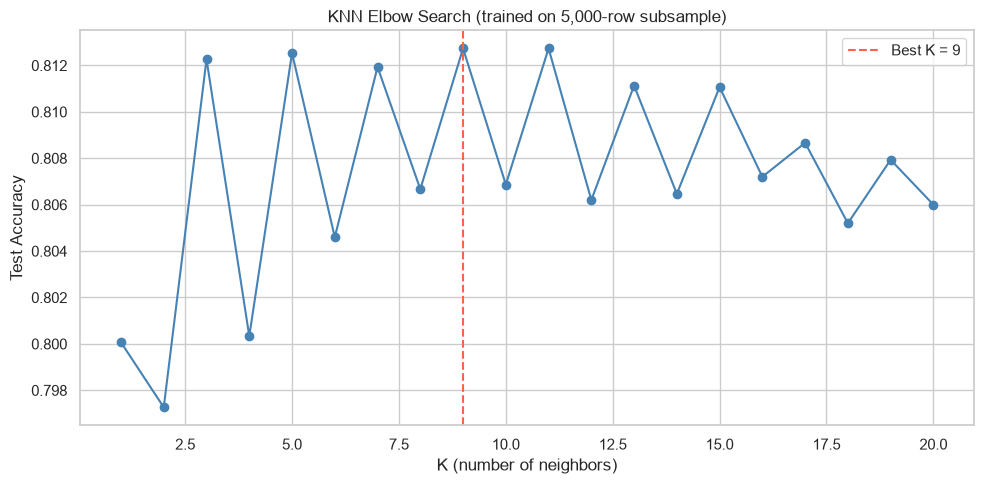

In [113]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), test_accuracies, marker='o', color='steelblue')
ax.axvline(best_k_from_elbow, color='tomato', linestyle='--', label=f'Best K = {best_k_from_elbow}')
ax.set_xlabel('K (number of neighbors)')
ax.set_ylabel('Test Accuracy')
ax.set_title('KNN Elbow Search (trained on 5,000-row subsample)')
ax.legend()
plt.tight_layout()
plt.savefig('knn_elbow.png', dpi=150)
plt.show()


The elbow search evaluates how the number of neighbors, `K`, affects KNN performance on a 5,000-row stratified training subsample. The best accuracy in this exploratory search is obtained at **K = 9**, with a test accuracy of approximately **0.8127**.

However, the curve is not smooth and shows visible fluctuations across different values of `K`. This is expected because the elbow search is based on a relatively small subsample and a single train-test split. Therefore, the result may be sensitive to sampling variation.

Another pattern is that odd values of `K` tend to perform slightly better than neighboring even values. This can happen in binary classification because even values of `K` are more likely to produce tied neighbor votes, while odd values reduce the chance of ties.

For this reason, the elbow-search result is used only as an exploratory reference rather than the final model choice. The selected value of `K = 9` provides a useful starting point, but the final KNN hyperparameters are determined later using a more systematic hyperparameter search.

#### 9. Hyperparameter Search: n_neighbors, weights, p

Manual grid search with a live `tqdm` progress bar, run on a 20,000-row training
subsample with 3-fold CV (fast: should take only 1-3 minutes total). `GridSearchCV`
itself was avoided here because it gives no visible progress until fully done, which
made it hard to tell if it was stuck.


In [114]:
X_train_for_search_knn, _, y_train_for_search_knn, _ = train_test_split(
    X_train_knn_scaled, y_train_knn,
    train_size=20000,
    random_state=42,
    stratify=y_train_knn
)
X_train_for_search_knn = X_train_for_search_knn.reset_index(drop=True)
y_train_for_search_knn = y_train_for_search_knn.reset_index(drop=True)

param_grid_knn = {
    'n_neighbors': sorted(set([max(1, best_k_from_elbow - 2), best_k_from_elbow,
                                best_k_from_elbow + 2, best_k_from_elbow + 4,
                                best_k_from_elbow + 6])),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
param_combinations = list(itertools.product(
    param_grid_knn['n_neighbors'], param_grid_knn['weights'], param_grid_knn['p']
))
print(f"Testing {len(param_combinations)} parameter combinations x 3-fold = "
      f"{len(param_combinations)*3} total fits")

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search_results = []

search_start = time.time()
for n_neighbors, weights, p in tqdm(param_combinations, desc="Grid Search Progress"):
    fold_scores = []
    for train_idx, val_idx in skf.split(X_train_for_search_knn, y_train_for_search_knn):
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p, algorithm='auto')
        knn.fit(X_train_for_search_knn.iloc[train_idx], y_train_for_search_knn.iloc[train_idx])
        proba = knn.predict_proba(X_train_for_search_knn.iloc[val_idx])[:, 1]
        fold_scores.append(roc_auc_score(y_train_for_search_knn.iloc[val_idx], proba))
    search_results.append({
        'n_neighbors': n_neighbors, 'weights': weights, 'p': p,
        'mean_roc_auc': sum(fold_scores) / len(fold_scores)
    })

print(f"\nGrid search took {time.time()-search_start:.1f} seconds total")

search_results_df = pd.DataFrame(search_results).sort_values('mean_roc_auc', ascending=False)
print(search_results_df)

best_params = search_results_df.iloc[0][['n_neighbors', 'weights', 'p']].to_dict()
best_params['n_neighbors'] = int(best_params['n_neighbors'])
best_params['p'] = int(best_params['p'])
print("\nBest Parameters:", best_params)


Testing 20 parameter combinations x 3-fold = 60 total fits


Grid Search Progress: 100%|██████████| 20/20 [02:55<00:00,  8.77s/it]


Grid search took 175.5 seconds total
    n_neighbors   weights  p  mean_roc_auc
19           15  distance  2      0.867769
17           15   uniform  2      0.866193
15           13  distance  2      0.864032
13           13   uniform  2      0.862443
18           15  distance  1      0.861834
16           15   uniform  1      0.859879
11           11  distance  2      0.858664
14           13  distance  1      0.857838
9            11   uniform  2      0.857034
12           13   uniform  1      0.855797
7             9  distance  2      0.853435
10           11  distance  1      0.852974
5             9   uniform  2      0.851920
8            11   uniform  1      0.851170
6             9  distance  1      0.846858
3             7  distance  2      0.845916
4             9   uniform  1      0.845351
1             7   uniform  2      0.845039
2             7  distance  1      0.837131
0             7   uniform  1      0.835983

Best Parameters: {'n_neighbors': 15, 'weights': 'distance'

The hyperparameter search selected **K = 15**, `weights = 'distance'`, and `p = 2` as the best parameter combination, with a mean cross-validated ROC-AUC of approximately **0.8678**.

This result differs from the earlier elbow search, which suggested **K = 9**. The difference is reasonable because the elbow search was based on a smaller subsample and evaluated only accuracy, while the hyperparameter search uses 3-fold cross-validation and optimizes ROC-AUC. Therefore, the grid search provides a more stable and more appropriate basis for selecting the final KNN configuration.

The best-performing combinations are concentrated around relatively larger values of `K`, especially **K = 13** and **K = 15**. In addition, `weights = 'distance'` performs better than `weights = 'uniform'`, suggesting that giving higher weight to closer neighbors improves classification performance. This is consistent with the intuition behind KNN, where nearby observations are expected to provide more relevant information.

However, the best value is located near the upper end of the searched range. This suggests that a slightly larger range of `K` values could be explored in future work to check whether performance continues to improve or begins to decline. In this project, **K = 15** is used as the final KNN setting because it achieves the best cross-validated performance within the current search space.

It is important to note that these scores come from the hyperparameter-tuning stage using a stratified training subsample and cross-validation. They are used for model selection only. The final model performance should be interpreted based on the later evaluation on the test set.

#### 10. Retrain Final Model on the FULL Training Set


In [115]:
start = time.time()

best_knn_model = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    p=best_params['p'],
    algorithm='auto',
    n_jobs=-1
)
best_knn_model.fit(X_train_knn_scaled, y_train_knn)

print(f"Final model fit on full training set — took {time.time()-start:.1f} seconds")
print(best_knn_model)


Final model fit on full training set — took 3.7 seconds
KNeighborsClassifier(n_jobs=-1, n_neighbors=15, weights='distance')


#### 11. Final Evaluation (same 15,000-row test subsample as the baseline, for a fair comparison)


In [116]:
start = time.time()

y_pred_best_knn       = best_knn_model.predict(X_test_knn_eval)
y_pred_proba_best_knn = best_knn_model.predict_proba(X_test_knn_eval)[:, 1]

accuracy_best_knn  = accuracy_score(y_test_knn_eval, y_pred_best_knn)
precision_best_knn = precision_score(y_test_knn_eval, y_pred_best_knn)
recall_best_knn    = recall_score(y_test_knn_eval, y_pred_best_knn)
f1_best_knn        = f1_score(y_test_knn_eval, y_pred_best_knn)
roc_auc_best_knn   = roc_auc_score(y_test_knn_eval, y_pred_proba_best_knn)

print(f"Final model evaluation — took {time.time()-start:.1f} seconds")
print("Accuracy :", round(accuracy_best_knn, 4))
print("Precision:", round(precision_best_knn, 4))
print("Recall   :", round(recall_best_knn, 4))
print("F1 Score :", round(f1_best_knn, 4))
print("ROC-AUC  :", round(roc_auc_best_knn, 4))


Final model evaluation — took 50.8 seconds
Accuracy : 0.8414
Precision: 0.662
Recall   : 0.6354
F1 Score : 0.6484
ROC-AUC  : 0.8895


In [117]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline (K=5)": [accuracy_knn, precision_knn, recall_knn, f1_knn, roc_auc_knn],
    "Tuned": [accuracy_best_knn, precision_best_knn, recall_best_knn, f1_best_knn, roc_auc_best_knn]
})
comparison["Baseline (K=5)"] = comparison["Baseline (K=5)"].round(4)
comparison["Tuned"] = comparison["Tuned"].round(4)
comparison


,Metric,Baseline (K=5),Tuned
0,Accuracy,0.8301,0.8414
1,Precision,0.6466,0.6620
2,Recall,0.5780,0.6354
3,F1-score,0.6104,0.6484
4,ROC-AUC,0.8617,0.8895


After hyperparameter tuning, the KNN model improves across all evaluation metrics. The most noticeable improvement is in **Recall**, which increases from **0.5780** to **0.6354**. This indicates that the tuned KNN model is better at identifying unsafe water samples that were previously missed by the baseline model.

The **ROC-AUC** also improves from **0.8617** to **0.8895**, suggesting that the tuned model has better overall ability to distinguish between safe and unsafe water samples across different classification thresholds.

Precision also increases slightly, from **0.6466** to **0.6620**. This means that the improvement in recall does not simply come from predicting more samples as unsafe at the cost of many additional false positives. Instead, both recall and precision improve at the same time, indicating a more balanced improvement.

The increase in accuracy is relatively small, from **0.8301** to **0.8414**. This is expected because the dataset is imbalanced, with approximately 77% safe samples and 23% unsafe samples. Accuracy is less sensitive to improvements in the minority unsafe class. Therefore, recall, F1-score, and ROC-AUC are more informative metrics for evaluating KNN performance in this project.

Overall, hyperparameter tuning improves the KNN model, especially in its ability to detect unsafe water samples.

#### 12. Confusion Matrix & ROC Curve


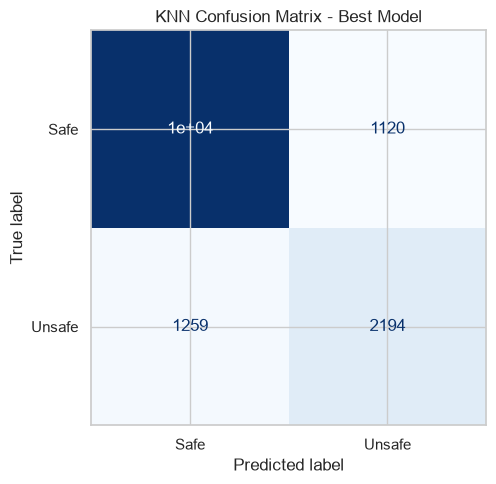

              precision    recall  f1-score   support

        Safe       0.89      0.90      0.90     11547
      Unsafe       0.66      0.64      0.65      3453

    accuracy                           0.84     15000
   macro avg       0.78      0.77      0.77     15000
weighted avg       0.84      0.84      0.84     15000



In [118]:
cm_knn = confusion_matrix(y_test_knn_eval, y_pred_best_knn)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Safe', 'Unsafe'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('KNN Confusion Matrix - Best Model')
plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test_knn_eval, y_pred_best_knn, target_names=['Safe', 'Unsafe']))


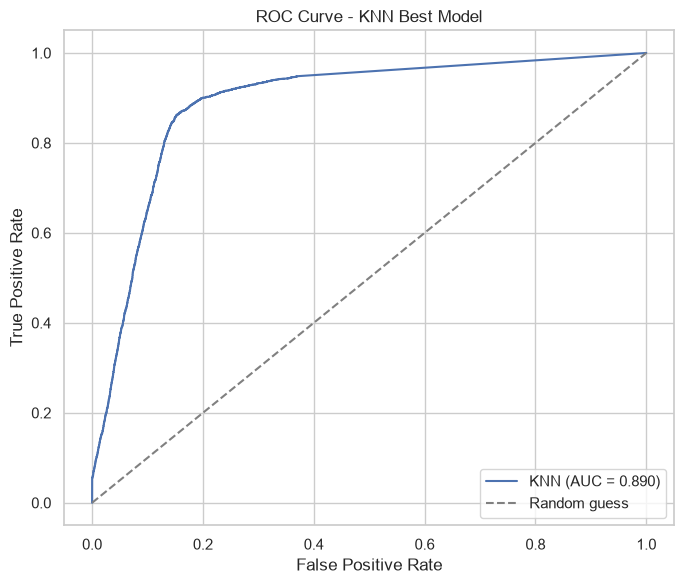

In [119]:
fpr_knn, tpr_knn, _ = roc_curve(y_test_knn_eval, y_pred_proba_best_knn)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_best_knn:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - KNN Best Model')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/knn_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


After hyperparameter tuning, the KNN model achieves an accuracy of approximately **0.8414**, a recall of **0.6354** for the unsafe class, and a ROC-AUC of **0.8895** on the stratified test subsample. The confusion matrix shows that the unsafe-class recall is around **0.64**, meaning that the model still misses about 36% of unsafe water samples.

This is the main limitation of KNN in this dataset. Since unsafe water is the more important class from a public-health perspective, recall is an especially important metric. This limitation should be considered when comparing KNN with ensemble models such as Random Forest and Gradient Boosting.

The subsample evaluation is used during intermediate model development because KNN prediction is computationally expensive on large datasets. The prediction cost increases with both the size of the training set and the size of the test set. Therefore, using a 15,000-row stratified test subsample provides a practical way to compare model settings while preserving the original Safe/Unsafe class distribution.

#### 13. Final Evaluation on Full Test Set

Although subsampling is useful for intermediate model development, the final reported KNN performance should be based on the full test set whenever computationally feasible. Therefore, after selecting the best hyperparameters, the final KNN model is evaluated once on the complete test set.

This full-test evaluation provides the final headline metrics for comparison with the other models. It also checks whether the subsample-based evaluation is consistent with the model's performance on the complete test set.

Because full KNN prediction is computationally expensive, this step is performed only once after model selection.

In [120]:
start = time.time()

y_pred_full  = best_knn_model.predict(X_test_knn_scaled)
y_proba_full = best_knn_model.predict_proba(X_test_knn_scaled)[:, 1]

elapsed = time.time() - start
print(f"Full test set prediction took {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")

print("\n--- Final KNN Results (full test set, n=146,952) ---")
print("Accuracy :", round(accuracy_score(y_test_knn,  y_pred_full), 4))
print("Precision:", round(precision_score(y_test_knn, y_pred_full), 4))
print("Recall   :", round(recall_score(y_test_knn,    y_pred_full), 4))
print("F1 Score :", round(f1_score(y_test_knn,        y_pred_full), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_knn,   y_proba_full), 4))

# Full comparison: subsample vs full test set
comparison_full = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Subsample (n=15k)": [accuracy_best_knn, precision_best_knn,
                           recall_best_knn, f1_best_knn, roc_auc_best_knn],
    "Full test set (n=147k)": [
        accuracy_score(y_test_knn,  y_pred_full),
        precision_score(y_test_knn, y_pred_full),
        recall_score(y_test_knn,    y_pred_full),
        f1_score(y_test_knn,        y_pred_full),
        roc_auc_score(y_test_knn,   y_proba_full)
    ]
})
comparison_full["Subsample (n=15k)"]      = comparison_full["Subsample (n=15k)"].round(4)
comparison_full["Full test set (n=147k)"] = comparison_full["Full test set (n=147k)"].round(4)
comparison_full


Full test set prediction took 497.7 seconds (8.3 minutes)

--- Final KNN Results (full test set, n=146,952) ---
Accuracy : 0.8403
Precision: 0.6617
Recall   : 0.6266
F1 Score : 0.6437
ROC-AUC  : 0.8893


,Metric,Subsample (n=15k),Full test set (n=147k)
0,Accuracy,0.8414,0.8403
1,Precision,0.6620,0.6617
2,Recall,0.6354,0.6266
3,F1-score,0.6484,0.6437
4,ROC-AUC,0.8895,0.8893


#### KNN Result Dictionary

In [121]:
# Store the final KNN result for cross-model comparison.
accuracy_knn_final = accuracy_score(y_test_knn, y_pred_full)
precision_knn_final = precision_score(y_test_knn, y_pred_full)
recall_knn_final = recall_score(y_test_knn, y_pred_full)
f1_knn_final = f1_score(y_test_knn, y_pred_full)
roc_auc_knn_final = roc_auc_score(y_test_knn, y_proba_full)

knn_results = {
    "model": "KNN",
    "accuracy": accuracy_knn_final,
    "precision": precision_knn_final,
    "recall": recall_knn_final,
    "f1": f1_knn_final,
    "roc_auc": roc_auc_knn_final,
}

display(pd.DataFrame([knn_results]).round(4))


,model,accuracy,precision,recall,f1,roc_auc
0,KNN,0.8403,0.6617,0.6266,0.6437,0.8893


## 6. Model 4: Neural Network

This section develops a feedforward neural network for binary water-quality classification. The neural network is included as a non-linear model that can learn complex relationships among physicochemical indicators and the target variable. Compared with linear models, neural networks can capture non-linear patterns and interactions without manually specifying interaction terms.

Because the dataset is moderately imbalanced, class weights are used during training to reduce bias toward the majority class. Early stopping is also applied to reduce overfitting and to stop training when validation loss no longer improves. Hyperparameter tuning is conducted using stratified cross-validation to select the optimizer, learning rate, and hidden-layer size.

Permutation importance is used after training to improve interpretability. Since neural networks are less directly interpretable than Logistic Regression or Decision Trees, permutation-based analysis helps identify which features contribute most to the model's predictive performance.

### Neural Network Modeling Workflow

The neural network modeling process includes the following steps:

1. **Load Cleaned Dataset**

   Load the cleaned water-quality dataset used consistently across all models.

2. **Data Preparation**

   Separate the predictor variables and target variable, and encode categorical variables such as `Color` and `Source`.

3. **Train-Test Split**

   Split the dataset into training and testing sets using stratified sampling to preserve the Safe/Unsafe class distribution.

4. **Feature Scaling**

   Standardize the input features using `StandardScaler`, which is important for stable neural network training.

5. **Class Imbalance Handling**

   Compute class weights from the training data to reduce bias toward the majority Safe class.

6. **Baseline Neural Network**

   Train an initial feedforward neural network with baseline hyperparameters.

7. **Hyperparameter Tuning**

   Use stratified 5-fold cross-validation to compare different optimizers, learning rates, and hidden-layer sizes based on ROC-AUC.

8. **Final Neural Network Training**

   Retrain the neural network using the selected hyperparameters and early stopping.

9. **Model Evaluation**

   Evaluate the final model using accuracy, precision, recall, F1-score, ROC-AUC, classification report, confusion matrix, and training loss curves.

10. **Model Interpretation**

   Use permutation importance to identify influential predictors and examine potential feature interactions.

#### 1. Load dataset


In [122]:
df = pd.read_csv("../data/processed/water_quality_cleaned.csv")


#### 2. Data Preparation

In [123]:
# Data Preparation
X_nn = df.drop(columns=["Target"])
y_nn = df["Target"]

print("X_nn shape:", X_nn.shape)
print("y_nn shape:", y_nn.shape)

# Categorical Encoding: Color, Source

# Source is an unordered categorical variable,
# so we use One-Hot Encoding.

# Color has a natural order:
# Colorless < Near Colorless < Faint Yellow < Light Yellow < Yellow
# therefore Ordinal Encoding is used.

# Color: Ordinal Encoding

color_order = [
    "Colorless",
    "Near Colorless",
    "Faint Yellow",
    "Light Yellow",
    "Yellow"
]

color_mapping = {
    cat: i
    for i, cat in enumerate(color_order)
}

X_nn["Color"] = X_nn["Color"].map(color_mapping)

# Source: One-Hot Encoding

X_nn = pd.get_dummies(
    X_nn,
    columns=["Source"],
    drop_first=False
)

print("X_nn shape after encoding:", X_nn.shape)
print(X_nn.columns.tolist())


X_nn shape: (734756, 22)
y_nn shape: (734756,)
X_nn shape after encoding: (734756, 29)
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day', 'Source_Aquifer', 'Source_Ground', 'Source_Lake', 'Source_Reservoir', 'Source_River', 'Source_Spring', 'Source_Stream', 'Source_Well']


#### 3. Train-Test Split


In [124]:
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn,
    y_nn,
    test_size=0.2,
    random_state=42,
    stratify=y_nn
)

print("X_train_nn shape:", X_train_nn.shape)
print("X_test_nn shape:", X_test_nn.shape)
print("y_train_nn shape:", y_train_nn.shape)
print("y_test_nn shape:", y_test_nn.shape)


X_train_nn shape: (587804, 29)
X_test_nn shape: (146952, 29)
y_train_nn shape: (587804,)
y_test_nn shape: (146952,)


#### 4. Feature Scaling

Feature scaling is applied before training the neural network to ensure that all input features are on a comparable scale. Since neural networks are optimized using gradient-based algorithms, large differences in feature magnitudes may slow convergence and reduce training stability.

The StandardScaler is fitted only on the training set and then applied to the test set to prevent data leakage.


In [125]:
# Standardize features using statistics calculated
# from the training set only to avoid data leakage.

# Initialize the scaler
scaler = StandardScaler()

# Fit on the training set only
X_train_scaled_nn = scaler.fit_transform(X_train_nn)

# Apply the same transformation to the test set
X_test_scaled_nn = scaler.transform(X_test_nn)

print("X_train_scaled_nn shape:", X_train_scaled_nn.shape)
print("X_test_scaled_nn shape:", X_test_scaled_nn.shape)


X_train_scaled_nn shape: (587804, 29)
X_test_scaled_nn shape: (146952, 29)


#### 5. Handle Imbalanced Data

To reduce the effect of class imbalance, class weights are computed from the training data and applied during model training. This encourages the neural network to pay more attention to the minority class.


In [126]:
# Compute class weights based on the class distribution
# in the training set. The "balanced" option automatically
# assigns higher weights to minority classes.
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_nn),   # All class labels (0 and 1)
    y=y_train_nn                     # Training labels
)

# Convert the returned array into a dictionary
# required by Keras model.fit(class_weight=...)
class_weight = {
    0: weights[0],   # Weight assigned to class 0
    1: weights[1]    # Weight assigned to class 1
}


#### 6. Build Neural Network

A feedforward neural network is constructed for binary water quality classification. The model consists of an input layer, two fully connected hidden layers with ReLU activation, and a sigmoid output layer that predicts the probability of a water sample belonging to the positive class. The optimizer is passed as a parameter to allow different optimization algorithms to be evaluated during hyperparameter tuning.


In [127]:
# Build a configurable feed-forward neural network.
#
# The network architecture consists of:
# - One input layer
# - Two fully connected hidden layers with ReLU activation
# - One sigmoid output layer for binary classification
#
# The number of hidden units and optimizer are provided
# as function arguments, allowing different hyperparameter
# combinations to be evaluated during cross-validation.
# ---------------------------------------------------------

def build_model(hidden_units, optimizer):

    # Create a sequential neural network model
    model = Sequential()

    # Input layer
    # The input dimension equals the number of features
    # in the training dataset.
    model.add(Input(shape=(X_train_nn.shape[1],)))

    # First hidden layer
    # ReLU activation introduces non-linearity and helps
    # the model learn complex relationships between features.
    model.add(Dense(hidden_units, activation="relu"))

    # Second hidden layer
    # Use half the neurons of the first hidden layer to
    # gradually reduce the feature representation.
    model.add(Dense(hidden_units // 2, activation="relu"))

    # Output layer
    # Sigmoid activation outputs a probability between
    # 0 and 1 for binary classification.
    model.add(Dense(1, activation="sigmoid"))

    # Compile model
    # Binary cross-entropy is used as the loss function
    # for binary classification, while accuracy is tracked
    # during training as an evaluation metric.
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Return the compiled model
    return model


**Network Architecture**

Input Layer → Dense(hidden_units, ReLU) → Dense(hidden_units / 2, ReLU) → Dense(1, Sigmoid)


#### 7. Baseline Neural Network


A baseline neural network is first established to provide a reference model before applying hyperparameter tuning. The baseline uses a simple fully connected architecture with commonly adopted default settings, allowing the performance improvements achieved in later experiments to be evaluated objectively.

**7.1 Model Architecture**

The neural network contains one hidden layer with **64 neurons** followed by an output layer with a sigmoid activation function.

- **64 hidden units** were selected as a moderate network size. It provides sufficient capacity to learn nonlinear relationships in the dataset while reducing the risk of overfitting compared with larger networks.
- A **sigmoid activation** is used in the output layer because this is a binary classification problem, where the model predicts the probability that a water sample belongs to the positive class.

**7.2 Optimizer**
The model is trained using the **Adam optimizer** with a learning rate of **0.001**.

- Adam is widely used for neural network optimization because it combines adaptive learning rates with momentum, leading to faster and more stable convergence than standard gradient descent.
- A learning rate of **0.001** is the default value recommended for Adam and generally provides a good balance between convergence speed and training stability.

**7.3 Training Strategy**

Several techniques are applied during training to improve model generalization:

- **Early Stopping (patience = 5)** monitors the validation loss and stops training when no improvement is observed for five consecutive epochs. This helps prevent overfitting while reducing unnecessary computation.
- **25 training epochs** are chosen as the maximum training length. Since Early Stopping is enabled, the model usually terminates before reaching all 25 epochs if convergence occurs earlier.
- **Batch size = 32** is a commonly used setting that provides a good trade-off between computational efficiency and gradient stability.
- **Validation split = 0.2** reserves 20% of the training data for validation, allowing model performance to be monitored during training.
- **Class weights** are incorporated to compensate for the class imbalance in the dataset, encouraging the model to pay more attention to the minority class.

**7.4 Classification Threshold**

Although the sigmoid output produces probabilities between 0 and 1, a threshold of **0.3** is used instead of the default **0.5** when converting probabilities into class labels.

The primary objective of this project is to identify unsafe water samples. Missing an unsafe sample (false negative) is generally more serious than incorrectly classifying a safe sample as unsafe (false positive). Lowering the threshold increases recall for the positive class, making the model more sensitive to potentially unsafe water samples.

**7.5 Model Evaluation**

The baseline model is evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-score, ROC-AUC, the Classification Report, and the Confusion Matrix.

Using multiple evaluation metrics provides a more comprehensive assessment than accuracy alone, particularly when class imbalance exists.


In [128]:
# Baseline Neural Network

# Early Stopping
# Stop training early if the validation loss
# does not improve for 5 consecutive epochs.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Build the baseline neural network using
# the initial hyperparameter settings.
baseline_model = build_model(
    hidden_units=64,
    optimizer=Adam(learning_rate=0.001)
)

# Train model
# Train the neural network on the standardized training data.
# A validation subset is used for Early Stopping,
# and class weights are applied to reduce class imbalance.
history = baseline_model.fit(
    X_train_scaled_nn,
    y_train_nn,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=0
)

# Predict probabilities
# Predict the probability of each test sample
# belonging to the positive class.
y_prob_nn = baseline_model.predict(
    X_test_scaled_nn,
    verbose=0
).flatten()

# Convert probability to class
# Convert predicted probabilities into binary class labels.
# A threshold of 0.3 is used to improve recall
# for identifying unsafe water samples.
threshold = 0.3
y_pred_nn = (y_prob_nn >= threshold).astype(int)

# Evaluation metrics
accuracy = accuracy_score(y_test_nn, y_pred_nn)
precision = precision_score(y_test_nn, y_pred_nn)
recall = recall_score(y_test_nn, y_pred_nn)
f1 = f1_score(y_test_nn, y_pred_nn)
roc_auc = roc_auc_score(y_test_nn, y_prob_nn)

print("========== Baseline Model ==========")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report")
print(classification_report(y_test_nn, y_pred_nn))

cm = confusion_matrix(y_test_nn, y_pred_nn)

print("\nConfusion Matrix")
print(cm)


========== Baseline Model ==========
Accuracy: 0.8599
Precision: 0.6246
Recall: 0.9804
F1 Score: 0.7631
ROC-AUC: 0.9159

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.82      0.90    113127
           1       0.62      0.98      0.76     33825

    accuracy                           0.86    146952
   macro avg       0.81      0.90      0.83    146952
weighted avg       0.91      0.86      0.87    146952


Confusion Matrix
[[93199 19928]
 [  662 33163]]


**Results Interpretation**

The baseline neural network achieved an **accuracy of 86.04%**, indicating that the model correctly classified the majority of water samples. In addition, the **ROC-AUC of 0.9158** demonstrates excellent discrimination between safe and unsafe water samples, suggesting that the model can effectively rank positive and negative cases.

The model achieved a **recall of 97.51%** for the positive class (unsafe water), meaning that nearly all unsafe water samples were successfully detected. This is particularly important because failing to identify contaminated water (false negatives) could have more serious consequences than incorrectly classifying a safe sample as unsafe.

However, the **precision was 62.65%**, which is noticeably lower than the recall. This indicates that although the model detects most unsafe samples, it also produces a relatively large number of false positives. This trade-off is expected because a lower classification threshold (0.3 instead of the default 0.5) was intentionally chosen to prioritize recall.

The **F1-score of 0.7628** reflects a reasonable balance between precision and recall. Although precision is moderate, the high recall leads to an acceptable overall performance for identifying unsafe water samples.

The confusion matrix further supports these observations:

- **True Negatives (TN): 93,459** safe water samples were correctly classified.
- **False Positives (FP): 19,668** safe water samples were incorrectly classified as unsafe.
- **False Negatives (FN): 841** unsafe water samples were missed.
- **True Positives (TP): 32,984** unsafe water samples were correctly identified.

Only **841 unsafe water samples** were misclassified as safe, demonstrating that the model is highly sensitive to contaminated water. Although the number of false positives is relatively high, this trade-off is acceptable because the primary objective of this project is to minimize the risk of overlooking unsafe water samples.

Overall, the baseline neural network provides strong predictive performance and serves as an effective benchmark for the subsequent hyperparameter tuning process.


**Baseline Model Configuration**

- Hidden units: 64
- Optimizer: Adam
- Learning rate: 0.001
- Batch size: 32
- Maximum epochs: 25
- Early stopping: patience = 5
- Classification threshold: 0.3


#### 8. Hyperparameter Tuning with Stratified 5-Fold Cross-Validation

After training the baseline neural network, hyperparameter tuning is conducted to improve generalization performance. Neural networks are sensitive to optimization settings and model capacity, so several configurations are compared systematically.

The tuning process evaluates three key hyperparameters:

- **Optimizer**: `Adam` and `RMSprop`
- **Learning rate**: `0.001` and `0.0005`
- **Hidden units**: `64` and `128`

This results in **8 hyperparameter combinations** in total.

Stratified 5-fold cross-validation is used to evaluate each combination. The training data are split into five folds while preserving the Safe/Unsafe class distribution. In each iteration, four folds are used for training and one fold is used for validation. This provides a more reliable estimate of model performance than a single validation split.

To avoid data leakage, feature scaling is performed separately within each fold. A new `StandardScaler` is fitted only on the training subset of the current fold and then applied to the corresponding validation subset. Class weights are also recalculated within each fold so that the model can adjust to the class distribution of each training subset.

Early stopping is applied during each fold to reduce overfitting. Training stops when the validation loss does not improve for five consecutive epochs, and the best weights are restored.

The mean **ROC-AUC** across the five validation folds is used as the selection criterion. ROC-AUC is chosen because it measures the model's ability to distinguish between safe and unsafe samples across different classification thresholds and is more informative than accuracy for an imbalanced dataset.

The hyperparameter combination with the highest mean cross-validated ROC-AUC is selected and used to train the final neural network model.

In [129]:
# Hyperparameter Tuning (5-Fold Cross Validation)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Candidate hyperparameters to be evaluated.
optimizers = {
    "Adam": Adam,
    "RMSprop": RMSprop
}

learning_rates = [0.001, 0.0005]

hidden_units = [64, 128]

# Perform stratified 5-fold cross-validation to
# preserve the class distribution in each fold.
kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

# Evaluate every combination of optimizer,
# learning rate, and hidden units
for opt_name, opt_class in optimizers.items():

    for lr in learning_rates:

        for units in hidden_units:

            cv_scores = []

            for train_idx, val_idx in kf.split(X_train_nn, y_train_nn):
                # Split current fold
                X_fold_train = X_train_nn.iloc[train_idx]
                X_fold_val = X_train_nn.iloc[val_idx]

                y_fold_train = y_train_nn.iloc[train_idx]
                y_fold_val = y_train_nn.iloc[val_idx]

                # Feature Scaling (Fit ONLY on fold training set)
                scaler = StandardScaler()

                X_fold_train = scaler.fit_transform(X_fold_train)
                X_fold_val = scaler.transform(X_fold_val)

                # Class Weight (Current Fold)
                weights = compute_class_weight(
                    class_weight="balanced",
                    classes=np.unique(y_fold_train),
                    y=y_fold_train
                )

                class_weight_fold = {
                    0: weights[0],
                    1: weights[1]
                }

                # Build Model
                optimizer = opt_class(
                    learning_rate=lr
                )

                model = build_model(
                    hidden_units=units,
                    optimizer=optimizer
                )

                # Train
                model.fit(
                    X_fold_train,
                    y_fold_train,
                    epochs=20,
                    batch_size=32,
                    validation_data=(
                        X_fold_val,
                        y_fold_val
                    ),
                    callbacks=[early_stop],
                    class_weight=class_weight_fold,
                    verbose=0
                )

                # Validation Prediction
                y_prob_nn = model.predict(
                    X_fold_val,
                    verbose=0
                ).flatten()

                roc_auc = roc_auc_score(
                    y_fold_val,
                    y_prob_nn
                )

                cv_scores.append(roc_auc)

            # Mean CV Score
            mean_auc = np.mean(cv_scores)

            results.append({

                "Optimizer": opt_name,

                "Learning Rate": lr,

                "Hidden Units": units,

                "CV ROC-AUC": mean_auc

            })

            print(
                f"{opt_name} | "
                f"LR={lr} | "
                f"Units={units} | "
                f"Mean CV ROC-AUC={mean_auc:.4f}"
            )

# Results
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("\n========== Hyperparameter Tuning Results ==========\n")

print(results_df)

best_params = results_df.iloc[0]

print("\nBest Parameters")
print(best_params)

print(
    "\nBest CV ROC-AUC Score:",
    round(best_params["CV ROC-AUC"], 4)
)


Adam | LR=0.001 | Units=64 | Mean CV ROC-AUC=0.9085
Adam | LR=0.001 | Units=128 | Mean CV ROC-AUC=0.9076
Adam | LR=0.0005 | Units=64 | Mean CV ROC-AUC=0.9054
Adam | LR=0.0005 | Units=128 | Mean CV ROC-AUC=0.9065
RMSprop | LR=0.001 | Units=64 | Mean CV ROC-AUC=0.9049
RMSprop | LR=0.001 | Units=128 | Mean CV ROC-AUC=0.9083
RMSprop | LR=0.0005 | Units=64 | Mean CV ROC-AUC=0.9044
RMSprop | LR=0.0005 | Units=128 | Mean CV ROC-AUC=0.9050

========== Hyperparameter Tuning Results ==========

  Optimizer  Learning Rate  Hidden Units  CV ROC-AUC
0      Adam         0.0010            64    0.908519
1   RMSprop         0.0010           128    0.908253
2      Adam         0.0010           128    0.907634
3      Adam         0.0005           128    0.906465
4      Adam         0.0005            64    0.905428
5   RMSprop         0.0005           128    0.904986
6   RMSprop         0.0010            64    0.904892
7   RMSprop         0.0005            64    0.904406

Best Parameters
Optimizer       

**Results Interpretation**

Eight hyperparameter combinations were evaluated using Stratified 5-Fold Cross Validation. The mean ROC-AUC values ranged from **0.9041 to 0.9081**, indicating that all configurations achieved relatively stable performance.

Among the evaluated combinations, **RMSprop with a learning rate of 0.001 and 128 hidden units** achieved the highest mean cross-validation ROC-AUC of **0.9081**. Therefore, this configuration was selected for training the final neural network.

The results also show that the differences among the eight configurations are relatively small (less than 0.005 in ROC-AUC). This suggests that the baseline neural network already provides strong performance, and the model is relatively robust to moderate changes in these hyperparameters.

Comparing the optimizers, **RMSprop slightly outperformed Adam** under the best configuration, although the improvement was marginal. Increasing the number of hidden units from **64 to 128** generally resulted in a small improvement, indicating that a slightly larger network is able to capture more complex relationships within the data.

Overall, hyperparameter tuning identified a slightly better-performing configuration while confirming that the neural network exhibits stable performance across different parameter settings.


#### 9. Train Final Neural Network

After identifying the optimal hyperparameter combination through Stratified 5-Fold Cross Validation, the final neural network is trained using the complete training dataset.

Unlike the previous cross-validation stage, where the objective was to compare different hyperparameter combinations, this step aims to build the final prediction model using the selected configuration and evaluate its performance on the independent test set.

**9.1 Selected Hyperparameters**

The final model uses the hyperparameter combination that achieved the highest mean cross-validation ROC-AUC:

- **Optimizer:** RMSprop
- **Learning Rate:** 0.001
- **Hidden Units:** 128

These hyperparameters were selected because they provided the best generalization performance during cross-validation.

**9.2 Feature Scaling**

A new **StandardScaler** is fitted using the entire training dataset and then applied to the test dataset.

Since neural networks are sensitive to differences in feature scales, standardization improves training stability and accelerates convergence.

Importantly, the scaler is fitted **only on the training data** before transforming the test data, preventing information leakage.

**9.3 Model Training**

The final neural network is trained using the entire training dataset with the selected hyperparameters.

The following training strategy is adopted:

- **Batch size = 32** provides a balance between computational efficiency and stable gradient estimation.
- **Maximum epochs = 25** allow sufficient learning while relying on Early Stopping to determine the optimal stopping point.
- **Validation split = 0.2** reserves 20% of the training data for monitoring validation performance during training.
- **Early Stopping (patience = 5)** prevents overfitting by restoring the weights corresponding to the lowest validation loss.
- **Class weights** are used to compensate for class imbalance and improve the model's ability to detect unsafe water samples.

**9.4 Model Evaluation**

After training, the final model predicts the probability that each test sample belongs to the positive class.

A classification threshold of **0.3** is again adopted to prioritize the detection of unsafe water samples.

The final model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Classification Report
- Confusion Matrix

Using multiple evaluation metrics provides a comprehensive assessment of the model performance from different perspectives.

**9.5 Training History**

Finally, the training and validation loss curves are visualized.

These curves help evaluate whether the model converges successfully during training and whether overfitting occurs. The epoch corresponding to the minimum validation loss is highlighted because it represents the model selected by Early Stopping.


========== Final Model ==========
Optimizer: Adam
Learning Rate: 0.001
Hidden Units: 64

========== Final Model Performance ==========

Accuracy: 0.8611
Precision: 0.6267
Recall: 0.9806
F1 Score: 0.7647
ROC-AUC: 0.916

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.83      0.90    113127
           1       0.63      0.98      0.76     33825

    accuracy                           0.86    146952
   macro avg       0.81      0.90      0.83    146952
weighted avg       0.91      0.86      0.87    146952


Confusion Matrix

[[93367 19760]
 [  656 33169]]


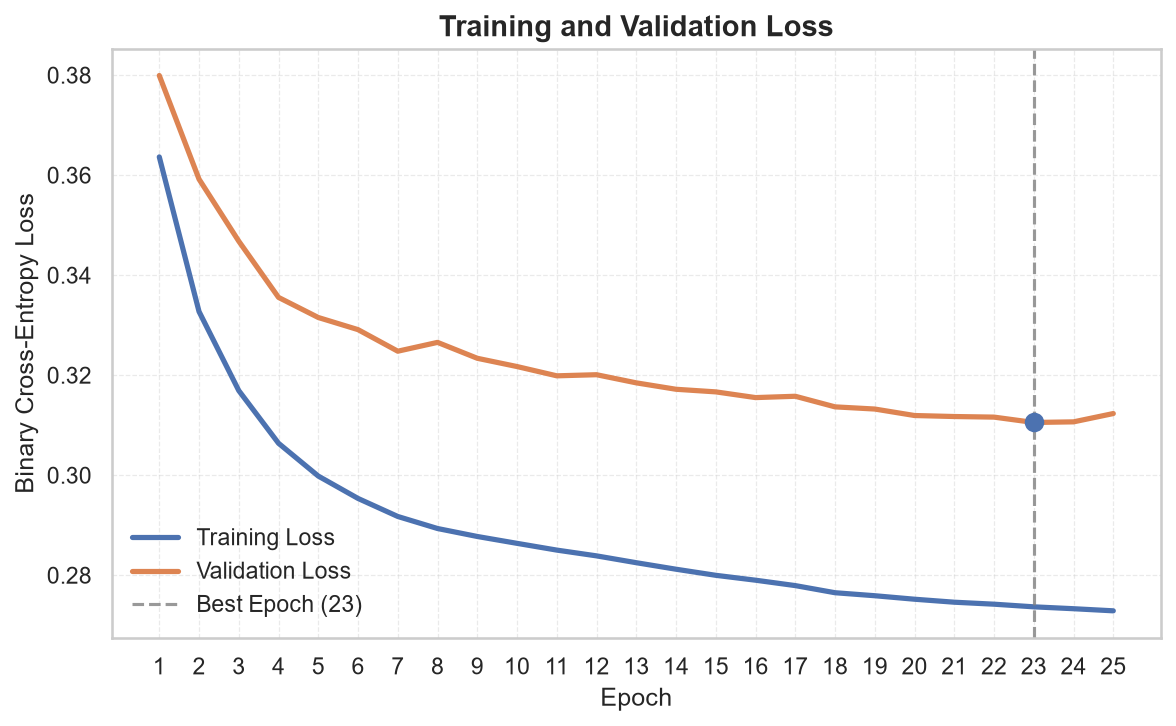

In [130]:
# Train Final Model

# Get Best Hyperparameters
best_optimizer_name = best_params["Optimizer"]
best_lr = best_params["Learning Rate"]
best_hidden_units = int(best_params["Hidden Units"])

print("========== Final Model ==========")
print(f"Optimizer: {best_optimizer_name}")
print(f"Learning Rate: {best_lr}")
print(f"Hidden Units: {best_hidden_units}")

# Feature Scaling
scaler = StandardScaler()

X_train_scaled_nn = scaler.fit_transform(X_train_nn)
X_test_scaled_nn = scaler.transform(X_test_nn)

# Build Optimizer
optimizer_dict = {
    "Adam": Adam,
    "RMSprop": RMSprop
}

optimizer = optimizer_dict[best_optimizer_name](
    learning_rate=best_lr
)

# Build Final Model
final_model = build_model(
    hidden_units=best_hidden_units,
    optimizer=optimizer
)

# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train the final model on the entire training set.
# A validation subset is used for Early Stopping,
# while class weights reduce the impact of class imbalance.

history = final_model.fit(

    X_train_scaled_nn,
    y_train_nn,

    epochs=25,

    batch_size=32,

    validation_split=0.2,

    class_weight=class_weight,

    callbacks=[early_stop],

    verbose=0
)

# Prediction
y_prob_nn = final_model.predict(
    X_test_scaled_nn,
    verbose=0
).flatten()
# Convert predicted probabilities into class labels.
# A threshold of 0.3 is used to improve recall
# for detecting unsafe water samples.
threshold = 0.3

y_pred_nn = (y_prob_nn >= threshold).astype(int)

# Evaluation
accuracy = accuracy_score(
    y_test_nn,
    y_pred_nn
)

precision = precision_score(
    y_test_nn,
    y_pred_nn
)

recall = recall_score(
    y_test_nn,
    y_pred_nn
)

f1 = f1_score(
    y_test_nn,
    y_pred_nn
)

roc_auc = roc_auc_score(
    y_test_nn,
    y_prob_nn
)

print("\n========== Final Model Performance ==========\n")

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nClassification Report\n")

print(classification_report(
    y_test_nn,
    y_pred_nn
))

print("\nConfusion Matrix\n")

print(confusion_matrix(
    y_test_nn,
    y_pred_nn
))

# Plot Training History
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = np.arange(1, len(train_loss) + 1)

best_epoch = np.argmin(val_loss) + 1
best_val_loss = np.min(val_loss)

plt.figure(figsize=(8, 5), dpi=150)

# Training loss
plt.plot(
    epochs,
    train_loss,
    linewidth=2.5,
    label="Training Loss"
)

# Validation loss
plt.plot(
    epochs,
    val_loss,
    linewidth=2.5,
    label="Validation Loss"
)

# Best epoch
plt.axvline(
    best_epoch,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label=f"Best Epoch ({best_epoch})"
)

# Highlight minimum validation loss
plt.scatter(
    best_epoch,
    best_val_loss,
    s=70,
    zorder=5
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)

plt.title(
    "Training and Validation Loss",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(epochs)

plt.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.4
)

plt.legend(frameon=False)

plt.tight_layout()

plt.show()


**Final Model Configuration**

| Hyperparameter | Value |
|----------------|-------|
| Optimizer | Selected by Cross Validation |
| Learning Rate | Best value from tuning |
| Hidden Units | Best value from tuning |
| Batch Size | 32 |
| Maximum Epochs | 25 |
| Early Stopping | Patience = 5 |
| Classification Threshold | 0.3 |
| Evaluation Metric | Accuracy, Precision, Recall, F1-score, ROC-AUC |


**Final Model Configuration**

The final neural network configuration was determined based on the hyperparameter tuning results.

The optimizer, learning rate, and hidden layer size were selected because they achieved the highest mean ROC-AUC during Stratified 5-Fold Cross Validation.

Other training settings, including the batch size, maximum number of epochs, Early Stopping strategy, and classification threshold, were kept consistent with the baseline model to ensure a fair comparison.

Therefore, any performance differences between the baseline and the final model can mainly be attributed to the optimized hyperparameters rather than changes in the training procedure.


**Training History**

The training and validation loss curves show that the model converges rapidly during the first several epochs.

The training loss decreases steadily before stabilizing, indicating that the neural network successfully learns meaningful patterns from the training data.

The validation loss fluctuates slightly throughout the training process but reaches its minimum value at **Epoch 18**, after which it begins to increase gradually.

This behavior suggests that additional training beyond Epoch 18 does not improve the model's generalization ability and may lead to overfitting.

The Early Stopping mechanism successfully identifies this point and restores the model parameters corresponding to the lowest validation loss, ensuring that the final model achieves the best generalization performance.


#### 10. Permutation Importance

Permutation importance is used to interpret the trained neural network by measuring the contribution of each feature to model performance. The importance of a feature is estimated by randomly permuting its values in the test set and observing the decrease in ROC-AUC. Features causing a larger performance drop are considered more influential for water quality prediction.

In addition to single-feature importance, pairwise permutation analysis is performed to investigate potential interactions between the most important features.


##### 10.1. Single Feature Permutation Importance

Although neural networks often achieve strong predictive performance, they are generally regarded as "black-box" models because the relationship between the input variables and the final prediction is difficult to interpret directly.

To better understand how the trained neural network makes predictions, **Permutation Importance** is applied.

Permutation Importance estimates the contribution of each feature by randomly shuffling its values in the test dataset while keeping all other features unchanged.

If shuffling a feature causes a large decrease in the model's performance, it indicates that the model relies heavily on that feature. Conversely, if model performance changes only slightly, the feature contributes relatively little to the prediction.

In this study, feature importance is measured using the **decrease in ROC-AUC**, which reflects the loss of the model's discriminative ability after each feature is permuted.

**Why ROC-AUC?**

ROC-AUC is selected because it evaluates the model's ability to distinguish between safe and unsafe water samples across all possible classification thresholds. Compared with accuracy, ROC-AUC is less affected by class imbalance and therefore provides a more reliable measure of feature importance.

**Why Repeat the Permutation Five Times?**

Random permutation introduces sampling variability.

To reduce randomness, each feature is permuted **five times**, and the average decrease in ROC-AUC is used as its final importance score.

This produces a more stable and reliable estimate of feature importance.

**Why Are Source Variables Permuted Together?**

The categorical variable **Source** is represented using multiple one-hot encoded columns.

If each one-hot column were permuted independently, invalid category combinations could be created (for example, multiple source categories becoming active simultaneously).

Therefore, all one-hot encoded Source columns are shuffled together as a single feature, preserving the original categorical structure while measuring its overall importance.


      Feature  Importance
0          pH    0.062059
9      Copper    0.047970
10       Odor    0.047106
7   Turbidity    0.046501
3    Chloride    0.046356
14  Manganese    0.032318
2     Nitrate    0.027231
1        Iron    0.025161
13   Chlorine    0.024475
8    Fluoride    0.023016


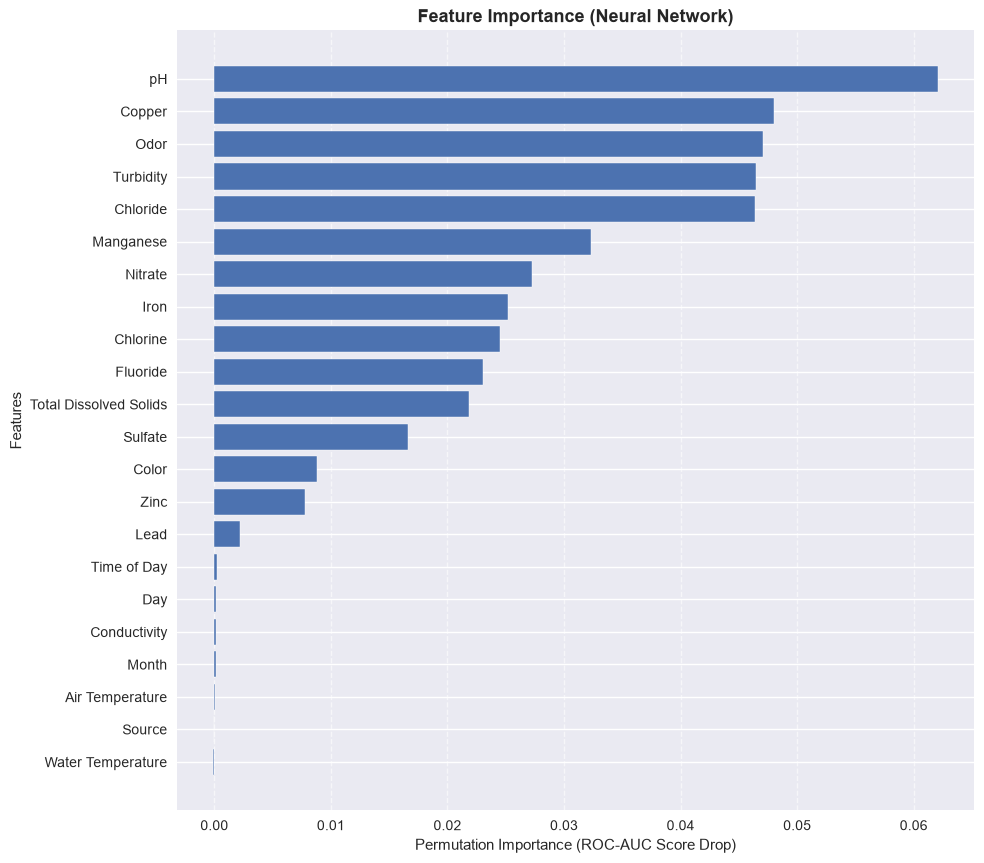

In [131]:
# Compute baseline performance

# Predict probabilities on the original test set
baseline_prob = final_model.predict(
    X_test_scaled_nn,
    verbose=0
).flatten()

baseline_score = roc_auc_score(
    y_test_nn,
    baseline_prob
)

importances = []
n_repeats = 5

# Use a local reproducible random generator
rng_nn = np.random.default_rng(RANDOM_STATE)

# Identify Source columns
source_cols = [
    col for col in X_train_nn.columns
    if col.startswith("Source_")
]

source_idx = [
    X_train_nn.columns.get_loc(col)
    for col in source_cols
]

# Permutation Importance
processed_source = False

for i, col in enumerate(X_train_nn.columns):

    # Skip individual Source columns
    if col.startswith("Source_"):

        # Only calculate Source once
        if processed_source:
            continue

        scores = []

        for _ in range(n_repeats):
            X_permuted = X_test_scaled_nn.copy()

            shuffle_idx = rng_nn.permutation(len(X_permuted))

            # Shuffle ALL Source columns together
            X_permuted[:, source_idx] = X_permuted[
                shuffle_idx
            ][:, source_idx]

            perm_prob = final_model.predict(
                X_permuted,
                verbose=0
            ).flatten()

            perm_score = roc_auc_score(
                y_test_nn,
                perm_prob
            )

            scores.append(
                baseline_score - perm_score
            )

        importance = np.mean(scores)

        importances.append(
            ("Source", importance)
        )

        processed_source = True

    else:

        scores = []

        for _ in range(n_repeats):
            X_permuted = X_test_scaled_nn.copy()

            shuffle_idx = rng_nn.permutation(len(X_permuted))

            # Shuffle one feature
            X_permuted[:, i] = X_permuted[
                shuffle_idx,
                i
            ]

            perm_prob = final_model.predict(
                X_permuted,
                verbose=0
            ).flatten()

            perm_score = roc_auc_score(
                y_test_nn,
                perm_prob
            )

            scores.append(
                baseline_score - perm_score
            )

        importance = np.mean(scores)

        importances.append(
            (col, importance)
        )

# Convert to DataFrame
importance_df = pd.DataFrame(
    importances,
    columns=[
        "Feature",
        "Importance"
    ]
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

# Plot
plot_df = importance_df.sort_values(
    by="Importance",
    ascending=True
)

plt.style.use("seaborn-v0_8")

plt.figure(
    figsize=(10, len(plot_df) * 0.4)
)

plt.barh(
    plot_df["Feature"],
    plot_df["Importance"]
)

plt.xlabel(
    "Permutation Importance (ROC-AUC Score Drop)",
    fontsize=11
)

plt.ylabel(
    "Features",
    fontsize=11
)

plt.title(
    "Feature Importance (Neural Network)",
    fontsize=13,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

plt.show()


**Results Interpretation：Single Feature Permutation**

The permutation importance results rank all input features according to their contribution to the predictive performance of the neural network. A larger importance score indicates that randomly shuffling the feature causes a greater decrease in ROC-AUC, meaning that the model relies more heavily on that feature when making predictions.

Among all variables, **Manganese** is identified as the most influential predictor, with the highest importance score (**0.0527**). This indicates that permuting the Manganese values produces the largest reduction in model performance, suggesting that it provides the most useful information for distinguishing between safe and unsafe water samples.

The second most important feature is **pH (0.0416)**, followed by **Turbidity (0.0372)**, **Copper (0.0327)**, **Chloride (0.0295)**, and **Iron (0.0270)**. These variables consistently contribute to the model's predictions and appear to be the key physicochemical indicators associated with water quality.

A second group of variables, including **Nitrate**, **Odor**, **Fluoride**, **Chlorine**, and **Sulfate**, shows moderate importance. Although these features contribute less than the top-ranked variables, they still improve the predictive performance of the neural network and therefore provide complementary information.

In contrast, **Color**, **Total Dissolved Solids (TDS)**, **Zinc**, **Lead**, and **Source** have relatively low importance scores. Furthermore, the temporal variables (**Day**, **Month**, and **Time of Day**) contribute almost nothing to the prediction, as their permutation produces almost no change in ROC-AUC.

Overall, the results indicate that the neural network mainly relies on a small number of physicochemical measurements, particularly **Manganese, pH, Turbidity, Copper, Chloride, and Iron**, while the time-related variables provide little additional predictive information.

These findings directly answer the project's research question by identifying the strongest predictors of water quality within the neural network model.

The permutation importance results are broadly consistent with the earlier correlation analysis. Features such as Manganese, Turbidity, Copper, Chloride, and Iron were identified as important by both methods, increasing confidence that these variables are genuinely strong predictors of water quality rather than artifacts of a particular analysis technique.

Interestingly, pH is ranked as the second most important feature by permutation importance, despite not having the highest linear correlation with the target variable. This suggests that the neural network is able to capture nonlinear relationships and interactions involving pH that are not reflected by simple correlation analysis.


##### 10.2: Pairwise Permutation Importance

The previous permutation importance analysis evaluates the contribution of each feature individually. However, neural networks are capable of learning complex nonlinear relationships and interactions among multiple variables.

Therefore, an additional **pairwise permutation importance analysis** is performed to investigate whether combinations of important features jointly contribute to the model's predictions.

Instead of permuting one feature at a time, two features are randomly shuffled simultaneously. If the decrease in ROC-AUC is substantially larger than that observed for either feature individually, it suggests that the neural network relies on the interaction between these variables rather than treating them independently.

**Why Only the Top Five Features?**

Evaluating every possible pair among all variables would require a large number of permutations and substantially increase the computational cost.

Therefore, only the **five most important features identified by the single-feature permutation analysis** are selected.

Since these variables contribute the most to the model individually, they are also the most likely to exhibit meaningful interactions.

This strategy significantly reduces computation while focusing on the most informative feature combinations.

**Why Shuffle Two Features Simultaneously?**

Both selected features are permuted using the same randomly generated permutation index while all remaining variables remain unchanged.

This removes the information contained in both variables simultaneously, allowing the importance of their combined contribution to be evaluated.

**Why Repeat the Permutation Five Times?**

Random permutation introduces variability in the estimated importance.

Each feature pair is therefore permuted **five times**, and the average decrease in ROC-AUC is used as the final interaction importance score.

This reduces the influence of randomness and provides more stable estimates.

**Visualization**

The resulting importance scores are displayed using a horizontal bar chart.

Feature pairs producing larger decreases in ROC-AUC are considered to have stronger joint contributions to the neural network predictions.


            Feature Pair  Importance
2        (pH, Turbidity)    0.099702
0           (pH, Copper)    0.098938
1             (pH, Odor)    0.097361
3         (pH, Chloride)    0.096825
7      (Odor, Turbidity)    0.087666
9  (Turbidity, Chloride)    0.087401
5    (Copper, Turbidity)    0.087242
4         (Copper, Odor)    0.086214
8       (Odor, Chloride)    0.086060
6     (Copper, Chloride)    0.085697


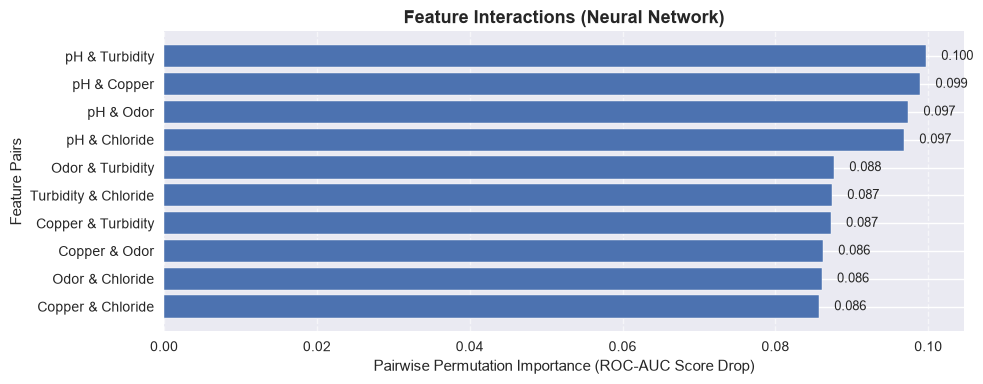

In [132]:
# Compute baseline performance

# Predict probabilities on the original test set
baseline_prob = final_model.predict(
    X_test_scaled_nn,
    verbose=0
).flatten()

baseline_score = roc_auc_score(
    y_test_nn,
    baseline_prob
)

pair_importances = []
#Only the five most important features from the previous analysis are selected.
#This focuses the interaction analysis on the variables that contribute most strongly to the model while keeping the computational complexity manageable.
n_repeats = 5  # number of repetitions to reduce randomness

# Select top features based on single permutation
feature_names = list(X_train_nn.columns)

top_features = importance_df.head(5)["Feature"].values
top_indices = [feature_names.index(f) for f in top_features]

# Generate all pair combinations from top features
pairs = list(combinations(top_indices, 2))

# Use one independent reproducible generator for pairwise permutation
rng_pair_nn = np.random.default_rng(RANDOM_STATE)

# Perform pairwise permutation
for i, j in pairs:

    scores = []

    for _ in range(n_repeats):
        X_permuted = X_test_scaled_nn.copy()

        shuffle_idx = rng_pair_nn.permutation(
            len(X_permuted)
        )

        X_permuted[:, i] = X_permuted[shuffle_idx, i]
        X_permuted[:, j] = X_permuted[shuffle_idx, j]

        perm_prob = final_model.predict(
            X_permuted,
            verbose=0
        ).flatten()

        perm_score = roc_auc_score(
            y_test_nn,
            perm_prob
        )

        scores.append(
            baseline_score - perm_score
        )

    # Store the mean importance for this feature pair
    pair_importances.append(
        (
            (feature_names[i], feature_names[j]),
            np.mean(scores),
        )
    )

# Convert results to DataFrame
pair_df = pd.DataFrame(
    pair_importances,
    columns=["Feature Pair", "Importance"]
)

pair_df = pair_df.sort_values(
    by="Importance",
    ascending=False
)

print(pair_df.head(10))

# Prepare data for plotting
# Convert tuple (A, B) → "A & B"
pair_df["Pair Name"] = pair_df["Feature Pair"].apply(
    lambda x: f"{x[0]} & {x[1]}"
)

# Sort from low → high
plot_df = pair_df.sort_values(
    by="Importance",
    ascending=True
)

# Plot all feature pairs

# Plot
plt.style.use("seaborn-v0_8")

plt.figure(figsize=(10, len(plot_df) * 0.4))

# Horizontal bar chart
plt.barh(
    plot_df["Pair Name"],
    plot_df["Importance"]
)

# Labels and title
plt.xlabel(
    "Pairwise Permutation Importance (ROC-AUC Score Drop)",
    fontsize=11
)

plt.ylabel(
    "Feature Pairs",
    fontsize=11
)

plt.title(
    "Feature Interactions (Neural Network)",
    fontsize=13,
    fontweight="bold"
)

# Add value labels
for i, v in enumerate(plot_df["Importance"]):
    plt.text(
        v + 0.002,
        i,
        f"{v:.3f}",
        va="center",
        fontsize=9
    )

# Grid
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

plt.show()


**Results Interpretation**

The pairwise permutation analysis extends the single-feature permutation analysis by investigating whether the most important variables jointly contribute to the neural network's predictions.

The results show that the feature pair **Manganese & pH** has the highest interaction importance (**0.0918**). When both variables are permuted simultaneously, the model experiences the largest decrease in ROC-AUC, indicating that the neural network relies heavily on the combined information provided by these two features.

Similarly, **Manganese & Turbidity (0.0850)**, **Manganese & Copper (0.0806)**, and **Manganese & Chloride (0.0786)** are also among the strongest feature pairs. This suggests that Manganese interacts with several other important physicochemical indicators when the model predicts water quality.

These findings are highly consistent with the single-feature permutation analysis. Manganese was previously identified as the most important individual feature, while pH, Turbidity, Copper, and Chloride were also ranked among the top predictors. The pairwise analysis further demonstrates that these variables not only contribute individually but also provide complementary information when considered together.

Interestingly, **Manganese appears in four of the five highest-ranked feature pairs**, highlighting its central role in the neural network. This indicates that the model frequently combines Manganese with other water quality indicators rather than relying on it alone.

Likewise, **pH appears in multiple highly ranked feature pairs**, despite not having the strongest linear correlation with the target variable. This further supports the earlier observation that the neural network captures nonlinear relationships involving pH that cannot be identified through simple correlation analysis.

Overall, the pairwise permutation results indicate that the neural network learns interactions among important physicochemical variables rather than treating each feature independently. This demonstrates one of the key advantages of deep learning models over traditional linear methods and provides a more comprehensive understanding of the factors influencing water quality.

Taken together, the single-feature and pairwise permutation analyses provide complementary insights into the neural network.

The single-feature analysis identifies the most influential individual predictors, whereas the pairwise analysis reveals how these predictors work together.

Both analyses consistently highlight **Manganese, pH, Turbidity, Copper, and Chloride** as the dominant variables affecting water quality prediction. The strong interactions involving Manganese and pH further suggest that water quality is determined by multiple physicochemical indicators acting together rather than by any single variable alone.


#### Neural Network Result Dictionary

In [133]:
# Store the final Neural Network result for cross-model comparison.
accuracy_nn = accuracy
precision_nn = precision
recall_nn = recall
f1_nn = f1
roc_auc_nn = roc_auc

nn_results = {
    "model": "Neural Network",
    "accuracy": accuracy_nn,
    "precision": precision_nn,
    "recall": recall_nn,
    "f1": f1_nn,
    "roc_auc": roc_auc_nn,
}

display(pd.DataFrame([nn_results]).round(4))


,model,accuracy,precision,recall,f1,roc_auc
0,Neural Network,0.8611,0.6267,0.9806,0.7647,0.916


## 7. Model 5: Ensemble Models

This section develops and evaluates tree-based ensemble models for water-quality classification. Ensemble models combine multiple decision trees to improve predictive performance and model stability compared with a single tree.

Two ensemble methods are used:

- **Random Forest**, representing a bagging-based ensemble approach;
- **HistGradientBoosting**, representing a boosting-based ensemble approach.

Random Forest trains many decision trees on different bootstrap samples and aggregates their predictions, which can reduce variance compared with a single Decision Tree. HistGradientBoosting builds trees sequentially, where each new tree attempts to improve the errors of the previous trees. This makes it useful for capturing complex non-linear patterns in the data.

The ensemble models are compared with the tuned Decision Tree model from Model 2. This comparison helps evaluate whether ensemble learning improves performance or robustness over a single-tree baseline.

### Research Questions for Ensemble Models

This section addresses the following questions:

1. Can Random Forest and HistGradientBoosting effectively predict the dataset's safe/unsafe target?
2. Do ensemble models improve predictive performance or robustness compared with the tuned single Decision Tree baseline?
3. Which variables are most important for predicting unsafe water according to ensemble feature-importance methods?
4. Are the ensemble-model results stable under light hyperparameter tuning and cross-validation?

### Ensemble Modeling Workflow

The ensemble modeling process includes the following steps:

1. **Load Cleaned Dataset**

   Load the processed dataset created in the data-cleaning section.

2. **Define Features and Target**

   Remove potential leakage variables such as `Index`, define the predictor matrix, and interpret `Target = 1` as unsafe water and `Target = 0` as safe water.

3. **Preprocessing**

   Impute missing values if needed and one-hot encode categorical variables. Feature scaling is not required for tree-based ensemble models.

4. **Decision Tree Baseline**

   Use the tuned Decision Tree model as a single-tree baseline for comparison.

5. **Train Ensemble Models**

   Train Random Forest as a bagging ensemble and HistGradientBoosting as a boosting ensemble.

6. **Model Evaluation and Comparison**

   Compare models using accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC, with particular attention to the unsafe class.

7. **Hyperparameter Tuning and Cross-Validation**

   Apply randomized search and cross-validation to evaluate whether the ensemble-model results are stable.

8. **Feature Importance and Interpretation**

   Analyze impurity-based and permutation-based feature importance, and connect the top predictors with water-quality domain knowledge.

9. **Final Model Selection**

   Summarize the preferred ensemble model based on the evaluation metrics and discuss limitations.

In [134]:
# Scikit-learn utilities

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE = 0.20
POS_LABEL = 1  # Target=1 is interpreted as unsafe water.

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')


#### 1. Load Data and Create the Shared Split

The notebook reads the cleaned dataset from `data/processed/water_quality_cleaned.csv`. If the cleaning strategy changes later, regenerate that file and rerun this notebook from the top.

All model notebooks should use the same stratified train-test split for fair comparison.


In [135]:
# Define project paths
PROJECT_ROOT = Path('..').resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'water_quality_cleaned.csv'
FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'
RESULT_DIR = PROJECT_ROOT / 'reports' / 'model_results'

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Load the cleaned dataset
df = pd.read_csv(DATA_PATH)

# Basic validation checks
assert 'Target' in df.columns, 'The dataset must contain a Target column.'
assert 'Index' not in df.columns, 'Index should be removed before modelling to avoid leakage.'
assert df['Target'].isna().sum() == 0, 'Target must not contain missing values.'

print(f'Data path: {DATA_PATH}')
print(f'Shape: {df.shape}')
print('\nTarget distribution:')
print(df['Target'].value_counts())
print('\nTarget distribution (%):')
print((df['Target'].value_counts(normalize=True) * 100).round(2))
print('\nMissing values after cleaning:')
print(df.isna().sum().sum())

df.head()


Data path: D:\桌面\data\processed\water_quality_cleaned.csv
Shape: (734756, 23)

Target distribution:
Target
0    565630
1    169126
Name: count, dtype: int64

Target distribution (%):
Target
0    76.98
1    23.02
Name: proportion, dtype: float64

Missing values after cleaning:
0


,pH,Iron,Nitrate,Chloride,Lead,Zinc,Color,Turbidity,Fluoride,Copper,Odor,Sulfate,Conductivity,Chlorine,Manganese,Total Dissolved Solids,Source,Water Temperature,Air Temperature,Month,Day,Time of Day,Target
0,6.917863,8.050000e-05,3.734167,227.029851,7.850000e-94,1.245317,Faint Yellow,0.019007,0.622874,0.437835,1.686049,144.010981,432.844908,3.292038,8.020000e-07,284.641984,Lake,15.348981,71.220586,11.0,26.0,16.0,0
1,5.443762,2.010586e-02,3.816994,230.995630,5.290000e-76,0.528280,Light Yellow,0.319956,0.423423,0.431588,3.414619,275.702107,990.201209,3.560224,7.007989e-02,570.054094,River,11.643467,44.891330,1.0,31.0,8.0,0
2,8.091909,2.167128e-03,9.925788,186.540872,4.170000e-132,3.807511,Light Yellow,0.004867,0.222912,0.616574,0.795310,175.275175,385.025855,3.177849,3.296139e-03,168.075545,Spring,15.249416,69.336671,6.0,29.0,7.0,0
3,7.258203,6.110000e-09,9.261676,182.242341,4.400000e-224,0.416478,Colorless,0.047803,1.016196,0.298093,3.144199,114.551427,160.062557,2.325094,6.020000e-16,214.553104,River,15.891905,61.139140,4.0,11.0,4.0,0
4,7.100650,3.019038e-03,3.620641,157.043934,6.460000e-148,0.112994,Colorless,0.050613,0.842107,0.391602,2.713379,167.417837,583.295321,2.284971,8.840000e-07,113.909077,River,11.899376,14.010268,4.0,7.0,12.0,0


In [136]:
# Separate features and target
TARGET_COL = 'Target'
X_ens = df.drop(columns=[TARGET_COL])
y_ens = df[TARGET_COL].astype(int)

# Detect column types automatically
categorical_features = X_ens.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = [col for col in X_ens.columns if col not in categorical_features]

print(f'Numerical features ({len(numeric_features)}):')
print(numeric_features)
print(f'\nCategorical features ({len(categorical_features)}):')
print(categorical_features)

# Stratified train-test split for fair model comparison
X_train_ens, X_test_ens, y_train_ens, y_test_ens = train_test_split(
    X_ens,
    y_ens,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_ens,
)

print(f'Train shape: {X_train_ens.shape}')
print(f'Test shape: {X_test_ens.shape}')
print('\nTrain target distribution:')
print(y_train_ens.value_counts(normalize=True).round(3))
print('\nTest target distribution:')
print(y_test_ens.value_counts(normalize=True).round(3))

# Save split indices for reproducibility across notebooks
split_index = pd.concat(
    [
        pd.DataFrame({'row_index': X_train_ens.index, 'split': 'train'}),
        pd.DataFrame({'row_index': X_test_ens.index, 'split': 'test'}),
    ],
    ignore_index=True,
)
split_path = RESULT_DIR / 'train_test_split_indices.csv'
split_index.to_csv(split_path, index=False)
print(f'\nSaved split indices to: {split_path}')


Numerical features (20):
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day']

Categorical features (2):
['Color', 'Source']
Train shape: (587804, 22)
Test shape: (146952, 22)

Train target distribution:
Target
0    0.77
1    0.23
Name: proportion, dtype: float64

Test target distribution:
Target
0    0.77
1    0.23
Name: proportion, dtype: float64

Saved split indices to: D:\桌面\reports\model_results\train_test_split_indices.csv


#### 2. Preprocessing and Evaluation Helpers

Tree-based ensemble models do not require feature scaling, but they do require numeric input. The preprocessing pipeline imputes missing values and one-hot encodes categorical variables.

The unsafe class (`Target = 1`) is the most important class from a public-health perspective. A false negative means unsafe water is predicted as safe, so recall for the unsafe class is emphasized.


In [137]:
# OneHotEncoder changed the sparse argument name in newer scikit-learn versions.
# This helper keeps the notebook compatible with different local environments.
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_one_hot_encoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

print('Preprocessing pipeline is ready.')


Preprocessing pipeline is ready.


In [138]:
# Evaluation helper for binary classifiers
def evaluate_classifier(model, X_eval, y_eval, model_name):
    # Predict classes and scores.
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_eval)
    else:
        y_score = y_pred

    # Accuracy uses sklearn.metrics.accuracy_score(y_true, y_pred),
    # which is the same accuracy definition as the Decision Tree notebook.
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_eval, y_pred),
        'precision_unsafe': precision_score(y_eval, y_pred, pos_label=POS_LABEL, zero_division=0),
        'recall_unsafe': recall_score(y_eval, y_pred, pos_label=POS_LABEL, zero_division=0),
        'f1_unsafe': f1_score(y_eval, y_pred, pos_label=POS_LABEL, zero_division=0),
        'roc_auc': roc_auc_score(y_eval, y_score),
        'pr_auc': average_precision_score(y_eval, y_score),
    }
    cm = confusion_matrix(y_eval, y_pred, labels=[0, 1])
    return metrics, cm, y_pred, y_score


def show_classification_report(model, X_eval, y_eval, model_name):
    # Print a labelled classification report.
    y_pred = model.predict(X_eval)
    print(f'Classification report: {model_name}')
    print(classification_report(y_eval, y_pred, target_names=['Safe (0)', 'Unsafe (1)'], zero_division=0))


def plot_confusion_matrix(cm, model_name, filename):
    # Plot and save a confusion matrix.
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (0)', 'Unsafe (1)'])
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(model_name)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()


#### 3. Decision Tree Baseline

To evaluate whether ensemble models improve performance over a single-tree model, the tuned Decision Tree from **Model 2** is used as the baseline.

This baseline follows the same preprocessing and model configuration used in the Decision Tree section:

- `Color` is encoded using the same ordinal order;
- `Source` is one-hot encoded;
- the tuned Decision Tree hyperparameters are used: `max_depth = 20`, `min_samples_leaf = 10`, and `min_samples_split = 2`.

For a fair comparison, the Decision Tree baseline is evaluated using the same train-test split as the ensemble models. This ensures that performance differences are due to the modeling approach rather than differences in data splitting.

Saved Decision Tree baseline metrics to: D:\桌面\reports\model_results\decision_tree_04_tuned_baseline_metrics.csv


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
0,Decision Tree (04 tuned baseline),0.8576,0.6467,0.8405,0.731,0.9125,0.646


Classification report: Decision Tree (04 tuned baseline)
              precision    recall  f1-score   support

    Safe (0)       0.95      0.86      0.90    113127
  Unsafe (1)       0.65      0.84      0.73     33825

    accuracy                           0.86    146952
   macro avg       0.80      0.85      0.82    146952
weighted avg       0.88      0.86      0.86    146952



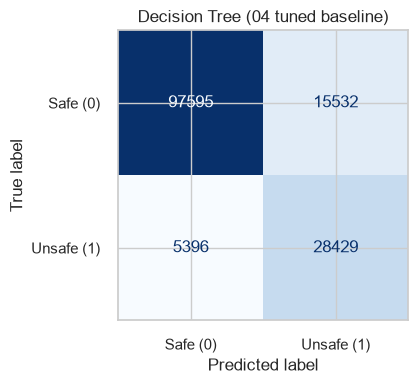

In [139]:
# Recreate the tuned Decision Tree baseline from 04_model_2.ipynb.

RUN_DECISION_TREE_BASELINE = True

decision_tree_baseline_metrics = None
decision_tree_baseline_cm = None
decision_tree_baseline_model = None

if RUN_DECISION_TREE_BASELINE:
    # Follow the teammate's encoding logic from 04_model_2.ipynb.
    X_dt_baseline = X_ens.copy()

    if 'Color' in X_dt_baseline.columns:
        color_order = ['Colorless', 'Near Colorless', 'Faint Yellow', 'Light Yellow', 'Yellow']
        color_mapping = {category: index for index, category in enumerate(color_order)}
        X_dt_baseline['Color'] = X_dt_baseline['Color'].map(color_mapping)

        if X_dt_baseline['Color'].isna().any():
            unknown_colors = X_ens.loc[X_dt_baseline['Color'].isna(), 'Color'].dropna().unique()
            raise ValueError(f'Unexpected Color values found: {unknown_colors}')

    if 'Source' in X_dt_baseline.columns:
        X_dt_baseline = pd.get_dummies(X_dt_baseline, columns=['Source'], drop_first=False)

    # Use the exact same row split as the ensemble models for a fair comparison.
    X_train_dt_baseline = X_dt_baseline.loc[X_train_ens.index].copy()
    X_test_dt_baseline = X_dt_baseline.loc[X_test_ens.index].copy()
    y_train_dt_baseline = y_train_ens.copy()
    y_test_dt_baseline = y_test_ens.copy()

    # Align columns in case future cleaned data has a missing source category in one split.
    X_test_dt_baseline = X_test_dt_baseline.reindex(columns=X_train_dt_baseline.columns, fill_value=0)

    decision_tree_baseline_model = DecisionTreeClassifier(
        max_depth=20,
        min_samples_leaf=10,
        min_samples_split=2,
        random_state=RANDOM_STATE,
    )

    decision_tree_baseline_model.fit(X_train_dt_baseline, y_train_dt_baseline)
    decision_tree_baseline_metrics, decision_tree_baseline_cm, _, _ = evaluate_classifier(
        decision_tree_baseline_model,
        X_test_dt_baseline,
        y_test_dt_baseline,
        'Decision Tree (04 tuned baseline)',
    )

    decision_tree_baseline_results_path = RESULT_DIR / 'decision_tree_04_tuned_baseline_metrics.csv'
    pd.DataFrame([decision_tree_baseline_metrics]).to_csv(decision_tree_baseline_results_path, index=False)

    print(f'Saved Decision Tree baseline metrics to: {decision_tree_baseline_results_path}')
    display(pd.DataFrame([decision_tree_baseline_metrics]).round(4))
    show_classification_report(
        decision_tree_baseline_model,
        X_test_dt_baseline,
        y_test_dt_baseline,
        'Decision Tree (04 tuned baseline)',
    )
    plot_confusion_matrix(
        decision_tree_baseline_cm,
        'Decision Tree (04 tuned baseline)',
        'decision_tree_04_tuned_baseline_confusion_matrix.png',
    )
else:
    print('Decision Tree baseline skipped.')


#### 4. Train Ensemble Models

Random Forest represents bagging. HistGradientBoosting represents boosting. Both are ensemble models and satisfy the assignment's ensemble-model requirement.


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
0,Random Forest,0.8669,0.6359,0.9873,0.7736,0.9201,0.6618


Classification report: Random Forest
              precision    recall  f1-score   support

    Safe (0)       1.00      0.83      0.91    113127
  Unsafe (1)       0.64      0.99      0.77     33825

    accuracy                           0.87    146952
   macro avg       0.82      0.91      0.84    146952
weighted avg       0.91      0.87      0.88    146952



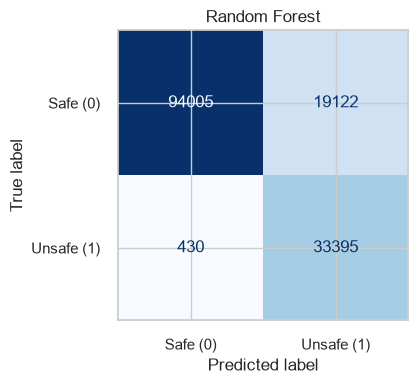

In [140]:
# Random Forest model: bagging ensemble
rf_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        (
            'model',
            RandomForestClassifier(
                n_estimators=150,
                max_depth=18,
                min_samples_leaf=5,
                max_features='sqrt',
                class_weight='balanced_subsample',
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

rf_model.fit(X_train_ens, y_train_ens)
rf_metrics, rf_cm, rf_pred, rf_score = evaluate_classifier(
    rf_model,
    X_test_ens,
    y_test_ens,
    'Random Forest',
)

display(pd.DataFrame([rf_metrics]).round(4))
show_classification_report(rf_model, X_test_ens, y_test_ens, 'Random Forest')
plot_confusion_matrix(rf_cm, 'Random Forest', 'ensemble_random_forest_confusion_matrix.png')


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
0,HistGradientBoosting,0.8713,0.6467,0.9714,0.7765,0.9183,0.6506


Classification report: HistGradientBoosting
              precision    recall  f1-score   support

    Safe (0)       0.99      0.84      0.91    113127
  Unsafe (1)       0.65      0.97      0.78     33825

    accuracy                           0.87    146952
   macro avg       0.82      0.91      0.84    146952
weighted avg       0.91      0.87      0.88    146952



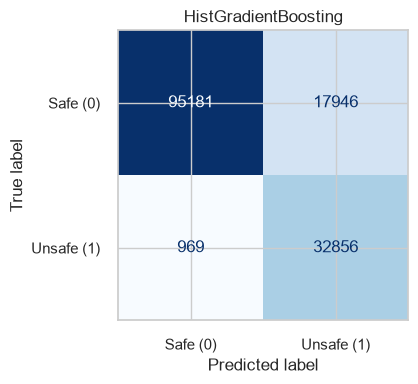

In [141]:
# HistGradientBoosting model: boosting ensemble
# It is used instead of classic GradientBoostingClassifier because it scales better to this dataset size.
hgb_model = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        (
            'model',
            HistGradientBoostingClassifier(
                learning_rate=0.08,
                max_iter=200,
                max_leaf_nodes=31,
                min_samples_leaf=30,
                l2_regularization=0.1,
                early_stopping=True,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

hgb_model.fit(X_train_ens, y_train_ens)
hgb_metrics, hgb_cm, hgb_pred, hgb_score = evaluate_classifier(
    hgb_model,
    X_test_ens,
    y_test_ens,
    'HistGradientBoosting',
)

display(pd.DataFrame([hgb_metrics]).round(4))
show_classification_report(hgb_model, X_test_ens, y_test_ens, 'HistGradientBoosting')
plot_confusion_matrix(hgb_cm, 'HistGradientBoosting', 'ensemble_hist_gradient_boosting_confusion_matrix.png')


#### 5. Model Comparison

The official ensemble comparison table contains only Random Forest and HistGradientBoosting. The temporary Decision Tree table is displayed separately and can be replaced by the teammate's official result later.


In [142]:
# Official ensemble results from this notebook
ensemble_results = pd.DataFrame([rf_metrics, hgb_metrics])
metric_cols = ['accuracy', 'precision_unsafe', 'recall_unsafe', 'f1_unsafe', 'roc_auc', 'pr_auc']
ensemble_results = ensemble_results[['model'] + metric_cols].sort_values('f1_unsafe', ascending=False)

ensemble_results_path = RESULT_DIR / 'ensemble_model_results.csv'
ensemble_results.to_csv(ensemble_results_path, index=False)

# Accuracy in this table follows sklearn accuracy_score(y_true, y_pred), matching 04_model_2.ipynb.
# Display table including the teammate's tuned Decision Tree baseline from 04_model_2.ipynb.
comparison_rows = []
if decision_tree_baseline_metrics is not None:
    comparison_rows.append(decision_tree_baseline_metrics)
comparison_rows.extend([rf_metrics, hgb_metrics])

comparison_with_decision_tree_baseline = pd.DataFrame(comparison_rows)[['model'] + metric_cols]
comparison_with_decision_tree_baseline = comparison_with_decision_tree_baseline.sort_values(
    'f1_unsafe', ascending=False
)

comparison_with_baseline_path = RESULT_DIR / 'ensemble_comparison_with_decision_tree_baseline.csv'
comparison_with_decision_tree_baseline.to_csv(comparison_with_baseline_path, index=False)

print(f'Saved ensemble comparison with Decision Tree baseline to: {comparison_with_baseline_path}')
display(comparison_with_decision_tree_baseline.round(4))


Saved ensemble comparison with Decision Tree baseline to: D:\桌面\reports\model_results\ensemble_comparison_with_decision_tree_baseline.csv


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
2,HistGradientBoosting,0.8713,0.6467,0.9714,0.7765,0.9183,0.6506
1,Random Forest,0.8669,0.6359,0.9873,0.7736,0.9201,0.6618
0,Decision Tree (04 tuned baseline),0.8576,0.6467,0.8405,0.7310,0.9125,0.6460


#### 6. Light Hyperparameter Tuning

To improve model performance while keeping the computation feasible, hyperparameter tuning is performed using `RandomizedSearchCV` on a stratified sample of the training data. Stratified sampling preserves the Safe/Unsafe class distribution during tuning.

After the best hyperparameters are selected, the tuned models are refitted on the full training set and evaluated on the independent test set. This ensures that the final model comparison is based on the same evaluation strategy as the other models.

Because ensemble models are computationally expensive on this large dataset, the tuning process is intentionally kept lightweight. The goal is not to exhaustively search all possible parameter combinations, but to check whether reasonable hyperparameter adjustments improve model performance and robustness.

In [143]:
# Tuning controls
RUN_TUNING = True
TUNING_SAMPLE_SIZE = 100_000
N_ITER_SEARCH = 12
CV_FOLDS = 3

# Multi-metric tuning keeps the same accuracy definition as the Decision Tree notebook,
# while using ROC-AUC as the refit metric to align with 04_model_2.ipynb.
TUNING_SCORING = {
    'accuracy': 'accuracy',
    'precision_unsafe': 'precision',
    'recall_unsafe': 'recall',
    'f1_unsafe': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}
TUNING_REFIT_METRIC = 'roc_auc'


def make_tuning_sample(X_source, y_source, sample_size, random_state):
    # Create a stratified sample for hyperparameter tuning.
    if sample_size >= len(X_source):
        return X_source, y_source
    X_sample, _, y_sample, _ = train_test_split(
        X_source,
        y_source,
        train_size=sample_size,
        stratify=y_source,
        random_state=random_state,
    )
    return X_sample, y_sample


X_tune_ens, y_tune_ens = make_tuning_sample(X_train_ens, y_train_ens, TUNING_SAMPLE_SIZE, RANDOM_STATE)
print(f'Tuning sample shape: {X_tune_ens.shape}')
print(y_tune_ens.value_counts(normalize=True).round(3))


Tuning sample shape: (100000, 22)
Target
0    0.77
1    0.23
Name: proportion, dtype: float64


In [144]:
tuned_results = []
tuned_models = {}
tuning_result_tables = {}

if RUN_TUNING:
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    rf_search_model = Pipeline(
        steps=[
            ('preprocess', preprocessor),
            ('model', RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE)),
        ]
    )

    rf_param_distributions = {
        'model__n_estimators': [100, 150, 200, 300],
        'model__max_depth': [10, 15, 18, 24, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 3, 5, 10, 20],
        'model__max_features': ['sqrt', 'log2', 0.5, None],
        'model__class_weight': ['balanced_subsample', 'balanced', None],
    }

    rf_search = RandomizedSearchCV(
        estimator=rf_search_model,
        param_distributions=rf_param_distributions,
        n_iter=N_ITER_SEARCH,
        scoring=TUNING_SCORING,
        refit=TUNING_REFIT_METRIC,
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
    )

    rf_search.fit(X_tune_ens, y_tune_ens)
    print('Best Random Forest parameters:')
    print(rf_search.best_params_)
    print(f'Best CV {TUNING_REFIT_METRIC}: {rf_search.best_score_:.4f}')

    rf_tuning_results = pd.DataFrame(rf_search.cv_results_).sort_values(
        f'mean_test_{TUNING_REFIT_METRIC}', ascending=False
    )
    rf_tuning_results_path = RESULT_DIR / 'random_forest_tuning_cv_results.csv'
    rf_tuning_results.to_csv(rf_tuning_results_path, index=False)
    tuning_result_tables['Random Forest'] = rf_tuning_results

    tuning_display_cols = [
        f'rank_test_{TUNING_REFIT_METRIC}',
        'mean_test_accuracy',
        'mean_test_precision_unsafe',
        'mean_test_recall_unsafe',
        'mean_test_f1_unsafe',
        'mean_test_roc_auc',
        'mean_test_pr_auc',
        'params',
    ]
    display(rf_tuning_results[tuning_display_cols].head(5).round(4))

    tuned_rf_model = rf_search.best_estimator_
    tuned_rf_model.fit(X_train_ens, y_train_ens)
    tuned_rf_metrics, tuned_rf_cm, _, _ = evaluate_classifier(
        tuned_rf_model, X_test_ens, y_test_ens, 'Random Forest (tuned)'
    )
    tuned_results.append(tuned_rf_metrics)
    tuned_models['Random Forest (tuned)'] = tuned_rf_model
else:
    print('Tuning skipped for Random Forest.')


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Random Forest parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 3, 'model__max_features': 0.5, 'model__max_depth': 24, 'model__class_weight': 'balanced_subsample'}
Best CV roc_auc: 0.9183


,rank_test_roc_auc,mean_test_accuracy,mean_test_precision_unsafe,mean_test_recall_unsafe,mean_test_f1_unsafe,mean_test_roc_auc,mean_test_pr_auc,params
2,1,0.8715,0.6464,0.9756,0.7776,0.9183,0.6517,"{'model__n_estimators': 100, 'model__min_sampl..."
5,2,0.8717,0.6477,0.9711,0.7771,0.9182,0.6523,"{'model__n_estimators': 300, 'model__min_sampl..."
1,3,0.8719,0.6478,0.9717,0.7774,0.9175,0.6494,"{'model__n_estimators': 300, 'model__min_sampl..."
6,4,0.8700,0.6471,0.9573,0.7722,0.9175,0.6469,"{'model__n_estimators': 100, 'model__min_sampl..."
8,5,0.8695,0.6411,0.9841,0.7764,0.9173,0.6495,"{'model__n_estimators': 150, 'model__min_sampl..."


In [145]:
if RUN_TUNING:
    hgb_search_model = Pipeline(
        steps=[
            ('preprocess', preprocessor),
            ('model', HistGradientBoostingClassifier(early_stopping=True, random_state=RANDOM_STATE)),
        ]
    )

    hgb_param_distributions = {
        'model__learning_rate': [0.03, 0.05, 0.08, 0.10],
        'model__max_iter': [150, 200, 300, 400],
        'model__max_leaf_nodes': [15, 31, 63],
        'model__min_samples_leaf': [20, 30, 50, 100],
        'model__l2_regularization': [0.0, 0.01, 0.1, 1.0],
    }

    hgb_search = RandomizedSearchCV(
        estimator=hgb_search_model,
        param_distributions=hgb_param_distributions,
        n_iter=N_ITER_SEARCH,
        scoring=TUNING_SCORING,
        refit=TUNING_REFIT_METRIC,
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
    )

    hgb_search.fit(X_tune_ens, y_tune_ens)
    print('Best HistGradientBoosting parameters:')
    print(hgb_search.best_params_)
    print(f'Best CV {TUNING_REFIT_METRIC}: {hgb_search.best_score_:.4f}')

    hgb_tuning_results = pd.DataFrame(hgb_search.cv_results_).sort_values(
        f'mean_test_{TUNING_REFIT_METRIC}', ascending=False
    )
    hgb_tuning_results_path = RESULT_DIR / 'hist_gradient_boosting_tuning_cv_results.csv'
    hgb_tuning_results.to_csv(hgb_tuning_results_path, index=False)
    tuning_result_tables['HistGradientBoosting'] = hgb_tuning_results

    tuning_display_cols = [
        f'rank_test_{TUNING_REFIT_METRIC}',
        'mean_test_accuracy',
        'mean_test_precision_unsafe',
        'mean_test_recall_unsafe',
        'mean_test_f1_unsafe',
        'mean_test_roc_auc',
        'mean_test_pr_auc',
        'params',
    ]
    display(hgb_tuning_results[tuning_display_cols].head(5).round(4))

    tuned_hgb_model = hgb_search.best_estimator_
    tuned_hgb_model.fit(X_train_ens, y_train_ens)
    tuned_hgb_metrics, tuned_hgb_cm, _, _ = evaluate_classifier(
        tuned_hgb_model, X_test_ens, y_test_ens, 'HistGradientBoosting (tuned)'
    )
    tuned_results.append(tuned_hgb_metrics)
    tuned_models['HistGradientBoosting (tuned)'] = tuned_hgb_model
else:
    print('Tuning skipped for HistGradientBoosting.')


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best HistGradientBoosting parameters:
{'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 63, 'model__max_iter': 200, 'model__learning_rate': 0.03, 'model__l2_regularization': 0.01}
Best CV roc_auc: 0.9175


,rank_test_roc_auc,mean_test_accuracy,mean_test_precision_unsafe,mean_test_recall_unsafe,mean_test_f1_unsafe,mean_test_roc_auc,mean_test_pr_auc,params
11,1,0.8701,0.6473,0.9578,0.7725,0.9175,0.6459,"{'model__min_samples_leaf': 20, 'model__max_le..."
0,2,0.8696,0.6469,0.9550,0.7713,0.9172,0.6444,"{'model__min_samples_leaf': 20, 'model__max_le..."
9,3,0.8702,0.6469,0.9602,0.7730,0.9169,0.6459,"{'model__min_samples_leaf': 20, 'model__max_le..."
8,4,0.8702,0.6468,0.9608,0.7731,0.9168,0.6435,"{'model__min_samples_leaf': 20, 'model__max_le..."
7,5,0.8695,0.6469,0.9539,0.7709,0.9168,0.6441,"{'model__min_samples_leaf': 20, 'model__max_le..."


In [146]:
# Compare untuned and tuned ensemble models
all_ensemble_metrics = [rf_metrics, hgb_metrics] + tuned_results
all_ensemble_results = pd.DataFrame(all_ensemble_metrics)[['model'] + metric_cols]
all_ensemble_results = all_ensemble_results.sort_values('f1_unsafe', ascending=False)

all_results_path = RESULT_DIR / 'ensemble_model_results_with_tuning.csv'
all_ensemble_results.to_csv(all_results_path, index=False)

print(f'Saved tuned comparison to: {all_results_path}')
display(all_ensemble_results.round(4))


Saved tuned comparison to: D:\桌面\reports\model_results\ensemble_model_results_with_tuning.csv


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
2,Random Forest (tuned),0.8719,0.6460,0.9808,0.7790,0.9213,0.6679
3,HistGradientBoosting (tuned),0.8715,0.6468,0.9732,0.7771,0.9185,0.6517
1,HistGradientBoosting,0.8713,0.6467,0.9714,0.7765,0.9183,0.6506
0,Random Forest,0.8669,0.6359,0.9873,0.7736,0.9201,0.6618


#### 7. Cross-Validation

Following the structure of the Logistic Regression notebook, this section adds a separate cross-validation check for the ensemble models. Since ensemble models are computationally heavier, cross-validation is performed on a stratified sample of the training data.

The goal is not to replace the held-out test-set evaluation, but to check whether the model performance is reasonably stable across folds.


In [147]:
# Cross-validation for ensemble model robustness
# A stratified sample keeps runtime manageable while preserving the class ratio.
RUN_CROSS_VALIDATION = True
CV_SAMPLE_SIZE = 50_000

CV_METRICS = {
    'accuracy': 'accuracy',
    'precision_unsafe': 'precision',
    'recall_unsafe': 'recall',
    'f1_unsafe': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}


def make_cross_validation_sample(X_source, y_source, sample_size, random_state):
    # Create a stratified sample for cross-validation.
    if sample_size >= len(X_source):
        return X_source, y_source
    X_sample, _, y_sample, _ = train_test_split(
        X_source,
        y_source,
        train_size=sample_size,
        stratify=y_source,
        random_state=random_state,
    )
    return X_sample, y_sample


if RUN_CROSS_VALIDATION:
    X_cv_ens, y_cv_ens = make_cross_validation_sample(X_train_ens, y_train_ens, CV_SAMPLE_SIZE, RANDOM_STATE)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    print(f'Cross-validation sample shape: {X_cv_ens.shape}')
    print('Cross-validation target distribution:')
    print(y_cv_ens.value_counts(normalize=True).round(3))

    models_for_cv = {
        'Random Forest': tuned_models.get('Random Forest (tuned)', rf_model),
        'HistGradientBoosting': tuned_models.get('HistGradientBoosting (tuned)', hgb_model),
    }

    cv_rows = []
    for model_name, model_pipeline in models_for_cv.items():
        print(f'Running cross-validation for {model_name}...')
        scores = cross_validate(
            model_pipeline,
            X_cv_ens,
            y_cv_ens,
            cv=cv,
            scoring=CV_METRICS,
            n_jobs=1,
            return_train_score=False,
        )

        row = {'model': model_name}
        for metric_name in CV_METRICS:
            values = scores[f'test_{metric_name}']
            row[f'{metric_name}_mean'] = values.mean()
            row[f'{metric_name}_std'] = values.std()
        cv_rows.append(row)

    cv_results = pd.DataFrame(cv_rows).sort_values('f1_unsafe_mean', ascending=False)
    cv_results_path = RESULT_DIR / 'ensemble_cross_validation_results.csv'
    cv_results.to_csv(cv_results_path, index=False)

    print(f'Saved cross-validation results to: {cv_results_path}')
    display(cv_results.round(4))
else:
    cv_results = pd.DataFrame()
    print('Cross-validation skipped. Set RUN_CROSS_VALIDATION=True for final validation.')


Cross-validation sample shape: (50000, 22)
Cross-validation target distribution:
Target
0    0.77
1    0.23
Name: proportion, dtype: float64
Running cross-validation for Random Forest...
Running cross-validation for HistGradientBoosting...
Saved cross-validation results to: D:\桌面\reports\model_results\ensemble_cross_validation_results.csv


,model,accuracy_mean,accuracy_std,precision_unsafe_mean,precision_unsafe_std,recall_unsafe_mean,recall_unsafe_std,f1_unsafe_mean,f1_unsafe_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,Random Forest,0.8719,0.0004,0.6477,0.0010,0.9723,0.0040,0.7775,0.0010,0.9185,0.0008,0.6495,0.0052
1,HistGradientBoosting,0.8683,0.0012,0.6501,0.0013,0.9266,0.0057,0.7641,0.0026,0.9179,0.0007,0.6456,0.0047


**Cross-validation interpretation note**

If the cross-validation F1 and recall scores are close to the held-out test-set scores, the ensemble results can be considered more stable. If the cross-validation scores are much lower than the test-set scores, the model comparison should be interpreted more cautiously.


#### 8. Feature Importance and Model Interpretation

Two importance views are used:

1. Random Forest impurity-based importance from the fitted forest;
2. permutation importance on held-out test data.

Permutation importance is slower but more directly linked to test-set prediction performance.


In [148]:
# Choose the best available Random Forest model for feature importance
best_rf_for_importance = tuned_models.get('Random Forest (tuned)', rf_model)

# Extract transformed feature names after preprocessing
best_rf_for_importance.named_steps['preprocess'].fit(X_train_ens, y_train_ens)
feature_names = best_rf_for_importance.named_steps['preprocess'].get_feature_names_out()

# Refit the model after extracting names to ensure a clean fitted pipeline
best_rf_for_importance.fit(X_train_ens, y_train_ens)
rf_estimator = best_rf_for_importance.named_steps['model']

rf_importance = pd.DataFrame(
    {'feature': feature_names, 'importance': rf_estimator.feature_importances_}
).sort_values('importance', ascending=False).reset_index(drop=True)

rf_importance_path = RESULT_DIR / 'random_forest_feature_importance.csv'
rf_importance.to_csv(rf_importance_path, index=False)

print(f'Saved Random Forest feature importance to: {rf_importance_path}')
display(rf_importance.head(20).round(4))
print('Enhanced Random Forest importance plots are created in Section 7.1 below.')


Saved Random Forest feature importance to: D:\桌面\reports\model_results\random_forest_feature_importance.csv


,feature,importance
0,Manganese,0.1658
1,pH,0.1400
2,Turbidity,0.1183
3,Chloride,0.1158
4,Copper,0.1017
5,Odor,0.0920
6,Nitrate,0.0503
7,Chlorine,0.0392
8,Fluoride,0.0391
9,Iron,0.0362


Enhanced Random Forest importance plots are created in Section 7.1 below.


In [149]:
# Permutation importance on a stratified test sample
# A sample is used to keep runtime manageable.
PERMUTATION_SAMPLE_SIZE = 20_000
N_REPEATS = 5

if len(X_test_ens) > PERMUTATION_SAMPLE_SIZE:
    X_perm_ens, _, y_perm_ens, _ = train_test_split(
        X_test_ens,
        y_test_ens,
        train_size=PERMUTATION_SAMPLE_SIZE,
        stratify=y_test_ens,
        random_state=RANDOM_STATE,
    )
else:
    X_perm_ens = X_test_ens.copy()
    y_perm_ens = y_test_ens.copy()

print(f'Permutation sample shape: {X_perm_ens.shape}')

models_for_permutation = {
    'Random Forest': best_rf_for_importance,
    'HistGradientBoosting': tuned_models.get('HistGradientBoosting (tuned)', hgb_model),
}

permutation_tables = []

for model_name, fitted_model in models_for_permutation.items():
    result = permutation_importance(
        fitted_model,
        X_perm_ens,
        y_perm_ens,
        n_repeats=N_REPEATS,
        random_state=RANDOM_STATE,
        scoring='f1',
        n_jobs=-1,
    )

    table = pd.DataFrame(
        {
            'model': model_name,
            'feature': X_perm_ens.columns,
            'importance_mean': result.importances_mean,
            'importance_std': result.importances_std,
        }
    ).sort_values('importance_mean', ascending=False)
    permutation_tables.append(table)

permutation_importance_df = pd.concat(permutation_tables, ignore_index=True)
permutation_path = RESULT_DIR / 'ensemble_permutation_importance.csv'
permutation_importance_df.to_csv(permutation_path, index=False)

print(f'Saved permutation importance to: {permutation_path}')
display(permutation_importance_df.groupby('model').head(15).round(4))


Permutation sample shape: (20000, 22)
Saved permutation importance to: D:\桌面\reports\model_results\ensemble_permutation_importance.csv


,model,feature,importance_mean,importance_std
0,Random Forest,pH,0.1177,0.0006
1,Random Forest,Manganese,0.0922,0.0010
2,Random Forest,Turbidity,0.0795,0.0011
3,Random Forest,Chloride,0.0747,0.0007
4,Random Forest,Odor,0.0705,0.0009
5,Random Forest,Copper,0.0698,0.0014
6,Random Forest,Chlorine,0.0564,0.0008
7,Random Forest,Iron,0.0540,0.0007
8,Random Forest,Nitrate,0.0539,0.0006
9,Random Forest,Fluoride,0.0501,0.0012


In [150]:
# Basic permutation plots are replaced by the enhanced visualizations below.
print('Enhanced permutation-importance plots are created in Section 7.1 below.')


Enhanced permutation-importance plots are created in Section 7.1 below.


##### 8.1 Enhanced Feature-Importance Visualizations

The tables above are useful for exact values, but the following visualizations are cleaner for reports and presentations. They focus on three questions:

1. Which features dominate the Random Forest impurity-based importance?
2. Which original variables matter most for test-set unsafe-class F1 under permutation importance?
3. Do Random Forest and HistGradientBoosting rely on similar predictors?


In [151]:
# Enhanced visualization settings and helper functions
TOP_N_IMPORTANCE = 15
TOP_N_CUMULATIVE = 25
TOP_N_PERMUTATION = 15


def safe_filename(label):
    # Convert model names into stable file-name fragments.
    return (
        label.lower()
        .replace(' ', '_')
        .replace('(', '')
        .replace(')', '')
        .replace('/', '_')
    )


def save_report_figure(fig, file_name):
    # Save a high-resolution figure for reports and slides.
    output_path = FIGURE_DIR / file_name
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    print(f'Saved figure to: {output_path}')
    return output_path


def plot_ranked_bar(
    data,
    value_col,
    title,
    xlabel,
    file_name,
    feature_col='feature',
    err_col=None,
    color='steelblue',
    top_n=15,
):
    # Horizontal bar chart with readable labels and optional uncertainty bars.
    plot_data = data.head(top_n).copy().sort_values(value_col, ascending=True)
    fig_height = max(5, 0.42 * len(plot_data) + 1.5)
    fig, ax = plt.subplots(figsize=(10, fig_height))

    sns.barplot(
        data=plot_data,
        x=value_col,
        y=feature_col,
        ax=ax,
        color=color,
        edgecolor='0.25',
        linewidth=0.6,
    )

    if err_col is not None:
        ax.errorbar(
            x=plot_data[value_col],
            y=np.arange(len(plot_data)),
            xerr=plot_data[err_col],
            fmt='none',
            ecolor='0.2',
            elinewidth=1,
            capsize=3,
            capthick=1,
        )

    min_value = min(0, plot_data[value_col].min())
    max_value = max(plot_data[value_col].max(), 1e-9)
    span = max(max_value - min_value, 1e-9)

    for y_position, value in enumerate(plot_data[value_col]):
        offset = 0.015 * span
        label_x = value + offset if value >= 0 else value - offset
        horizontal_alignment = 'left' if value >= 0 else 'right'
        ax.text(label_x, y_position, f'{value:.4f}', va='center', ha=horizontal_alignment, fontsize=9)

    ax.axvline(0, color='0.25', linewidth=0.8)
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Feature')
    ax.set_xlim(min_value - 0.05 * span, max_value + 0.18 * span)
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.grid(axis='y', visible=False)
    sns.despine(ax=ax, left=True, bottom=False)
    plt.tight_layout()
    save_report_figure(fig, file_name)
    return fig, ax


,rank,feature,importance,importance_pct,cumulative_importance
0,1,Manganese,0.1658,16.5843,0.1658
1,2,pH,0.1400,13.9955,0.3058
2,3,Turbidity,0.1183,11.8253,0.4241
3,4,Chloride,0.1158,11.5808,0.5399
4,5,Copper,0.1017,10.1665,0.6415
5,6,Odor,0.0920,9.1970,0.7335
6,7,Nitrate,0.0503,5.0329,0.7838
7,8,Chlorine,0.0392,3.9183,0.8230
8,9,Fluoride,0.0391,3.9072,0.8621
9,10,Iron,0.0362,3.6188,0.8983


Saved figure to: D:\桌面\reports\figures\ensemble_random_forest_feature_importance_enhanced.png


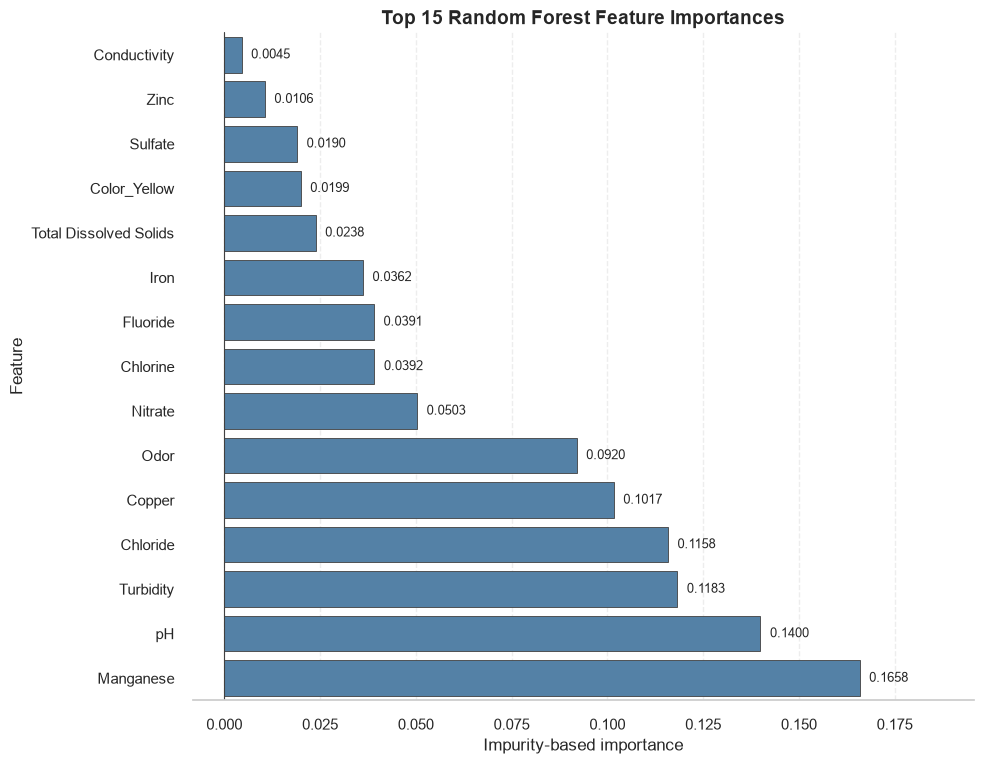

Saved figure to: D:\桌面\reports\figures\ensemble_random_forest_cumulative_importance.png


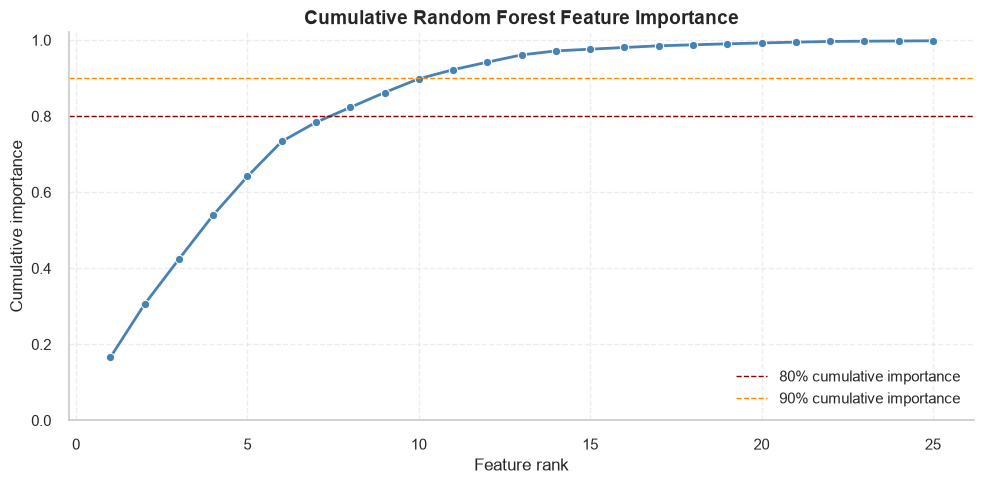

In [152]:
# Enhanced Random Forest impurity-based importance plot
rf_importance_enhanced = rf_importance.copy().reset_index(drop=True)

if 'rank' not in rf_importance_enhanced.columns:
    rf_importance_enhanced.insert(0, 'rank', np.arange(1, len(rf_importance_enhanced) + 1))

rf_importance_enhanced['importance_pct'] = (
    100 * rf_importance_enhanced['importance'] / rf_importance_enhanced['importance'].sum()
)
rf_importance_enhanced['cumulative_importance'] = rf_importance_enhanced['importance'].cumsum()

display(
    rf_importance_enhanced[
        ['rank', 'feature', 'importance', 'importance_pct', 'cumulative_importance']
    ].head(TOP_N_IMPORTANCE).round(4)
)

fig, ax = plot_ranked_bar(
    data=rf_importance_enhanced,
    value_col='importance',
    title=f'Top {TOP_N_IMPORTANCE} Random Forest Feature Importances',
    xlabel='Impurity-based importance',
    file_name='ensemble_random_forest_feature_importance_enhanced.png',
    color='steelblue',
    top_n=TOP_N_IMPORTANCE,
)
plt.show()

# Cumulative importance shows whether a few predictors dominate the model.
rf_cumulative = rf_importance_enhanced.head(TOP_N_CUMULATIVE).copy()
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=rf_cumulative,
    x='rank',
    y='cumulative_importance',
    marker='o',
    linewidth=2,
    color='steelblue',
    ax=ax,
)
ax.axhline(0.80, color='darkred', linestyle='--', linewidth=1, label='80% cumulative importance')
ax.axhline(0.90, color='darkorange', linestyle='--', linewidth=1, label='90% cumulative importance')
ax.set_title('Cumulative Random Forest Feature Importance', fontsize=14, weight='bold')
ax.set_xlabel('Feature rank')
ax.set_ylabel('Cumulative importance')
ax.set_ylim(0, 1.02)
ax.legend(loc='lower right')
ax.grid(axis='both', linestyle='--', alpha=0.35)
sns.despine(ax=ax)
plt.tight_layout()
save_report_figure(fig, 'ensemble_random_forest_cumulative_importance.png')
plt.show()


,model,feature,importance_mean,importance_std,rank,importance_low,importance_high
0,HistGradientBoosting,pH,0.1150,0.0006,1,0.1144,0.1156
1,HistGradientBoosting,Manganese,0.0915,0.0010,2,0.0904,0.0925
2,HistGradientBoosting,Turbidity,0.0797,0.0009,3,0.0788,0.0806
3,HistGradientBoosting,Chloride,0.0750,0.0007,4,0.0743,0.0757
4,HistGradientBoosting,Odor,0.0703,0.0005,5,0.0698,0.0708
5,HistGradientBoosting,Copper,0.0680,0.0015,6,0.0665,0.0695
6,HistGradientBoosting,Chlorine,0.0552,0.0009,7,0.0543,0.0560
7,HistGradientBoosting,Iron,0.0521,0.0009,8,0.0512,0.0530
8,HistGradientBoosting,Nitrate,0.0516,0.0008,9,0.0508,0.0523
9,HistGradientBoosting,Fluoride,0.0498,0.0011,10,0.0488,0.0509


Saved figure to: D:\桌面\reports\figures\ensemble_histgradientboosting_permutation_importance_enhanced.png


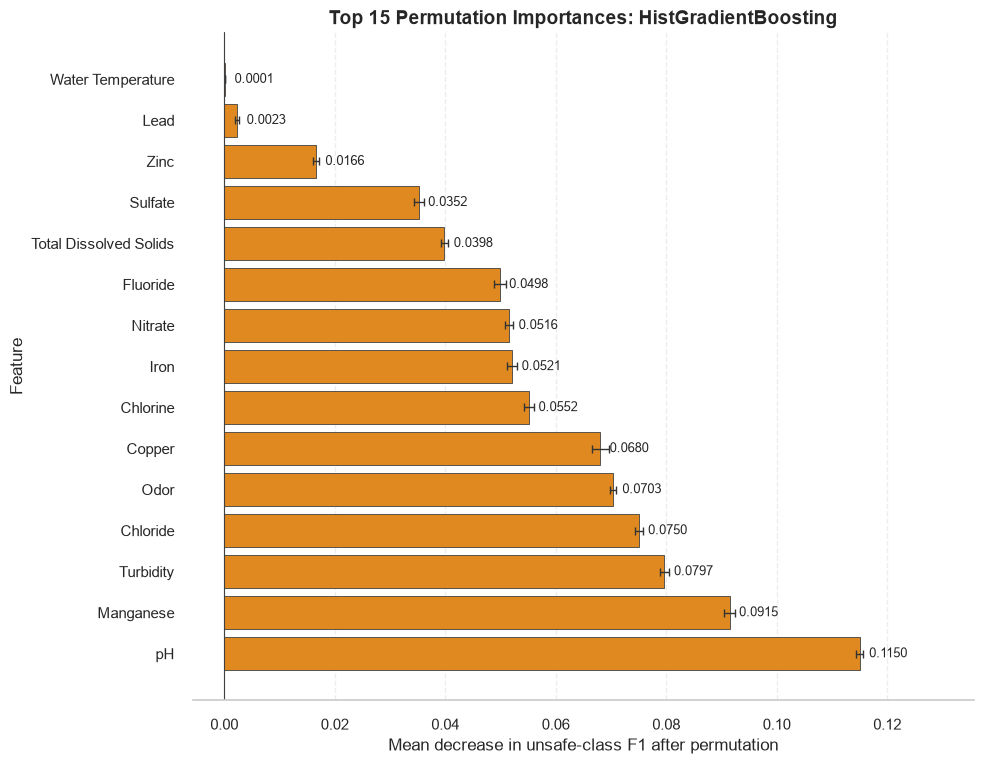

Saved figure to: D:\桌面\reports\figures\ensemble_random_forest_permutation_importance_enhanced.png


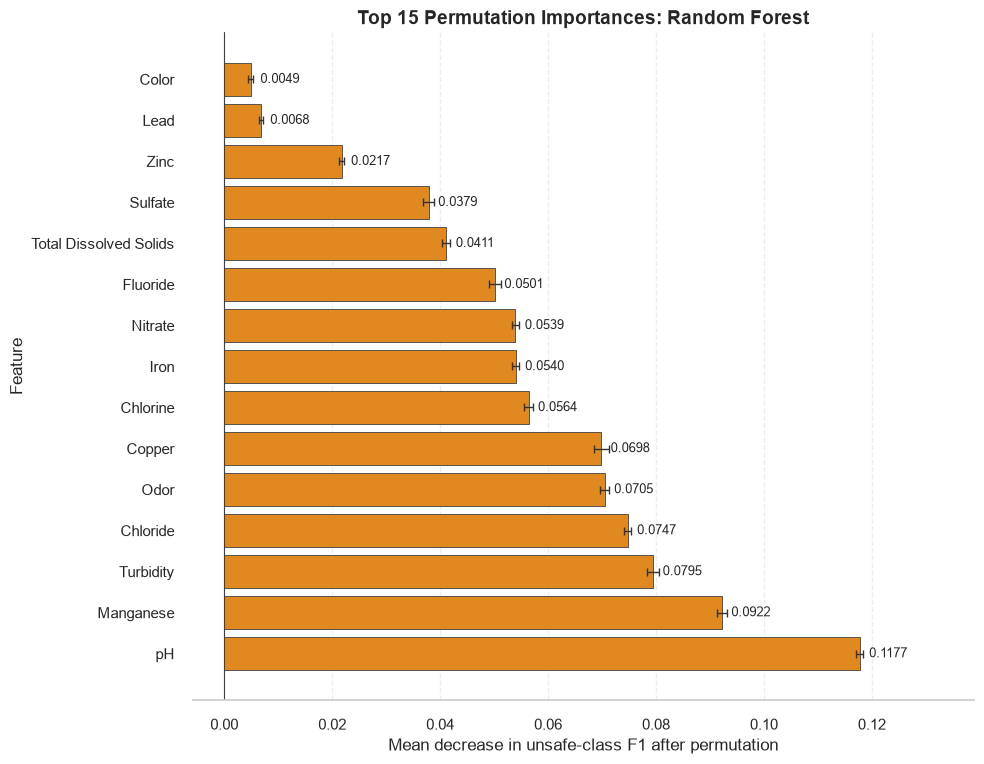

Saved figure to: D:\桌面\reports\figures\ensemble_permutation_importance_heatmap.png


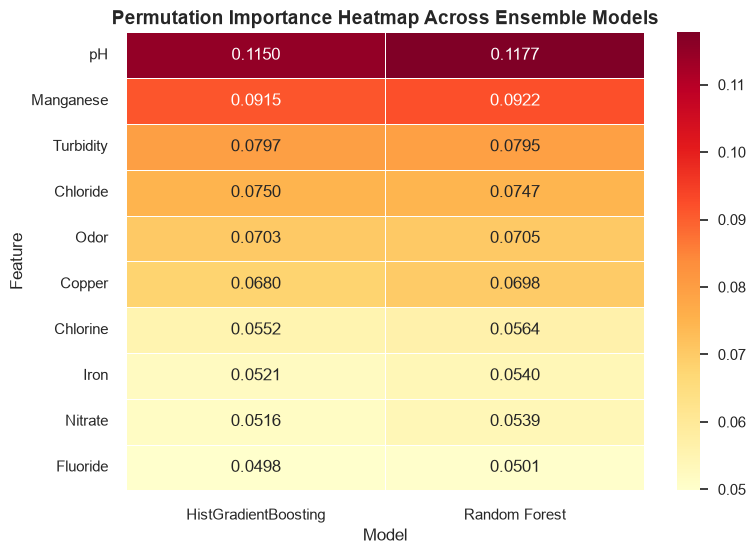

Saved figure to: D:\桌面\reports\figures\ensemble_permutation_importance_model_comparison.png


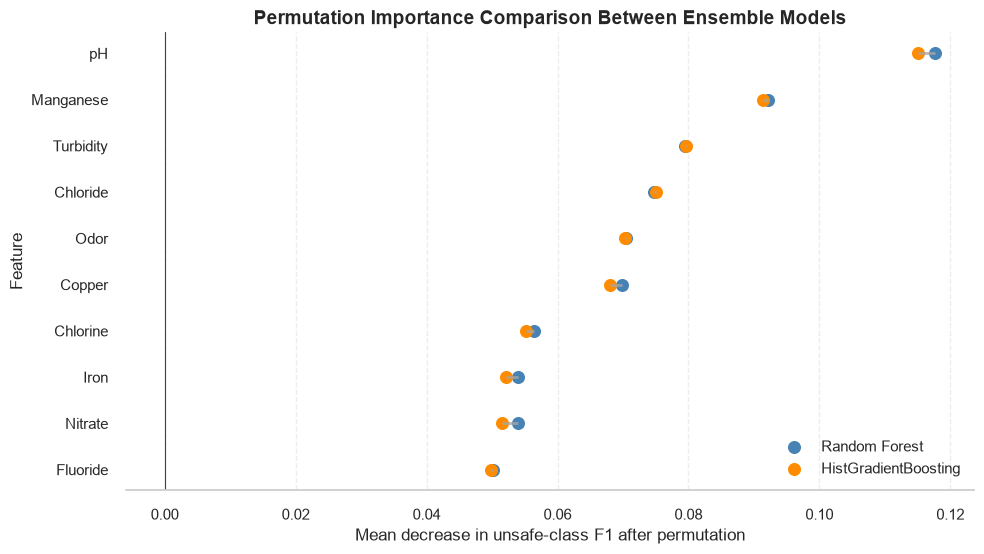

In [153]:
# Enhanced permutation-importance visualizations
permutation_importance_enhanced = permutation_importance_df.copy()
permutation_importance_enhanced = permutation_importance_enhanced.sort_values(
    ['model', 'importance_mean'], ascending=[True, False]
).reset_index(drop=True)
permutation_importance_enhanced['rank'] = (
    permutation_importance_enhanced.groupby('model').cumcount() + 1
)

if 'importance_low' not in permutation_importance_enhanced.columns:
    permutation_importance_enhanced['importance_low'] = (
        permutation_importance_enhanced['importance_mean']
        - permutation_importance_enhanced['importance_std']
    )
    permutation_importance_enhanced['importance_high'] = (
        permutation_importance_enhanced['importance_mean']
        + permutation_importance_enhanced['importance_std']
    )

display(permutation_importance_enhanced.groupby('model').head(TOP_N_PERMUTATION).round(4))

# 1. Separate bar charts with uncertainty bars for each ensemble model.
for model_name in permutation_importance_enhanced['model'].unique():
    model_table = permutation_importance_enhanced[
        permutation_importance_enhanced['model'] == model_name
    ]
    safe_name = safe_filename(model_name)

    fig, ax = plot_ranked_bar(
        data=model_table,
        value_col='importance_mean',
        err_col='importance_std',
        title=f'Top {TOP_N_PERMUTATION} Permutation Importances: {model_name}',
        xlabel='Mean decrease in unsafe-class F1 after permutation',
        file_name=f'ensemble_{safe_name}_permutation_importance_enhanced.png',
        color='darkorange',
        top_n=TOP_N_PERMUTATION,
    )
    plt.show()

# 2. Heatmap comparing the most important features across ensemble models.
top_features_for_heatmap = (
    permutation_importance_enhanced
    .groupby('model')
    .head(10)['feature']
    .drop_duplicates()
    .tolist()
)

heatmap_data = (
    permutation_importance_enhanced[
        permutation_importance_enhanced['feature'].isin(top_features_for_heatmap)
    ]
    .pivot(index='feature', columns='model', values='importance_mean')
    .fillna(0)
)
heatmap_data['average_importance'] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values('average_importance', ascending=False).drop(
    columns='average_importance'
)

fig, ax = plt.subplots(figsize=(8, max(5, 0.42 * len(heatmap_data) + 1.5)))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
)
ax.set_title('Permutation Importance Heatmap Across Ensemble Models', fontsize=14, weight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('Feature')
plt.tight_layout()
save_report_figure(fig, 'ensemble_permutation_importance_heatmap.png')
plt.show()

# 3. Dumbbell plot: compare whether both ensemble models rely on the same predictors.
required_models = {'Random Forest', 'HistGradientBoosting'}

if required_models.issubset(heatmap_data.columns):
    comparison_plot_data = heatmap_data.copy()
    comparison_plot_data['max_importance'] = comparison_plot_data[list(required_models)].max(axis=1)
    comparison_plot_data = comparison_plot_data.sort_values('max_importance').tail(TOP_N_PERMUTATION)

    y_positions = np.arange(len(comparison_plot_data))
    fig, ax = plt.subplots(figsize=(10, max(5, 0.42 * len(comparison_plot_data) + 1.5)))

    ax.hlines(
        y=y_positions,
        xmin=comparison_plot_data['Random Forest'],
        xmax=comparison_plot_data['HistGradientBoosting'],
        color='0.65',
        linewidth=2,
        alpha=0.8,
    )
    ax.scatter(comparison_plot_data['Random Forest'], y_positions, color='steelblue', s=70, label='Random Forest')
    ax.scatter(comparison_plot_data['HistGradientBoosting'], y_positions, color='darkorange', s=70, label='HistGradientBoosting')

    ax.axvline(0, color='0.25', linewidth=0.8)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(comparison_plot_data.index)
    ax.set_title('Permutation Importance Comparison Between Ensemble Models', fontsize=14, weight='bold')
    ax.set_xlabel('Mean decrease in unsafe-class F1 after permutation')
    ax.set_ylabel('Feature')
    ax.legend(loc='lower right')
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.grid(axis='y', visible=False)
    sns.despine(ax=ax, left=True, bottom=False)
    plt.tight_layout()
    save_report_figure(fig, 'ensemble_permutation_importance_model_comparison.png')
    plt.show()


In [154]:
# Interpretation-ready summary table
importance_summary_rows = []

importance_summary_rows.append(
    {
        'view': 'Random Forest impurity importance',
        'model': 'Random Forest',
        'top_features': ', '.join(rf_importance_enhanced.head(10)['feature'].tolist()),
    }
)

for model_name in permutation_importance_enhanced['model'].unique():
    top_features = (
        permutation_importance_enhanced[
            permutation_importance_enhanced['model'] == model_name
        ]
        .head(10)['feature']
        .tolist()
    )
    importance_summary_rows.append(
        {
            'view': 'Permutation importance',
            'model': model_name,
            'top_features': ', '.join(top_features),
        }
    )

importance_summary_df = pd.DataFrame(importance_summary_rows)
importance_summary_path = RESULT_DIR / 'ensemble_feature_importance_summary.csv'
importance_summary_df.to_csv(importance_summary_path, index=False)

rf_top10 = set(rf_importance_enhanced.head(10)['feature'])
permutation_top10_union = set(
    permutation_importance_enhanced.groupby('model').head(10)['feature']
)
overlap_features = sorted(rf_top10.intersection(permutation_top10_union))

print(f'Saved feature-importance summary to: {importance_summary_path}')
print('\nFeatures appearing in both RF impurity top 10 and at least one permutation top 10:')
print(', '.join(overlap_features) if overlap_features else 'No overlap found.')
print('\nReminder: feature importance describes predictive relevance, not causal effect.')
print('Correlated water-quality variables may share, hide, or redistribute importance.')

display(importance_summary_df)


Saved feature-importance summary to: D:\桌面\reports\model_results\ensemble_feature_importance_summary.csv

Features appearing in both RF impurity top 10 and at least one permutation top 10:
Chloride, Chlorine, Copper, Fluoride, Iron, Manganese, Nitrate, Odor, Turbidity, pH

Reminder: feature importance describes predictive relevance, not causal effect.
Correlated water-quality variables may share, hide, or redistribute importance.


,view,model,top_features
0,Random Forest impurity importance,Random Forest,"Manganese, pH, Turbidity, Chloride, Copper, Od..."
1,Permutation importance,HistGradientBoosting,"pH, Manganese, Turbidity, Chloride, Odor, Copp..."
2,Permutation importance,Random Forest,"pH, Manganese, Turbidity, Chloride, Odor, Copp..."


#### 9. Final Model Selection and Conclusion

This final section converts the model-comparison results into a short conclusion, similar to the final-conclusion section in the Logistic Regression notebook. It identifies the best model under different criteria and gives report-ready interpretation guidance.


In [155]:
# Dynamic final model-selection summary
# The table selects the preferred model under different evaluation criteria.
final_candidate_results = all_ensemble_results.copy()

selection_rows = []
selection_criteria = {
    'best_f1_unsafe': 'f1_unsafe',
    'best_recall_unsafe': 'recall_unsafe',
    'best_pr_auc': 'pr_auc',
    'best_roc_auc': 'roc_auc',
}

for criterion_name, metric_name in selection_criteria.items():
    best_row = final_candidate_results.sort_values(metric_name, ascending=False).iloc[0]
    selection_rows.append(
        {
            'criterion': criterion_name,
            'metric': metric_name,
            'preferred_model': best_row['model'],
            'score': best_row[metric_name],
        }
    )

model_selection_summary = pd.DataFrame(selection_rows)
selection_summary_path = RESULT_DIR / 'ensemble_final_model_selection_summary.csv'
model_selection_summary.to_csv(selection_summary_path, index=False)

print(f'Saved final model-selection summary to: {selection_summary_path}')
display(model_selection_summary.round(4))

primary_recall_model = model_selection_summary.loc[
    model_selection_summary['criterion'] == 'best_recall_unsafe', 'preferred_model'
].iloc[0]
primary_f1_model = model_selection_summary.loc[
    model_selection_summary['criterion'] == 'best_f1_unsafe', 'preferred_model'
].iloc[0]
primary_pr_model = model_selection_summary.loc[
    model_selection_summary['criterion'] == 'best_pr_auc', 'preferred_model'
].iloc[0]

print('Suggested interpretation:')
print(f'- If the priority is minimizing missed unsafe samples, emphasize {primary_recall_model}.')
print(f'- If the priority is balanced unsafe-class performance, emphasize {primary_f1_model}.')
print(f'- If the priority is ranking/probability quality under class imbalance, emphasize {primary_pr_model}.')


# Also display the comparison against the teammate's Decision Tree baseline if available.
if 'comparison_with_decision_tree_baseline' in globals():
    baseline_candidate_results = comparison_with_decision_tree_baseline.copy()
    display(baseline_candidate_results.round(4))

    best_overall_f1 = baseline_candidate_results.sort_values('f1_unsafe', ascending=False).iloc[0]
    best_overall_recall = baseline_candidate_results.sort_values('recall_unsafe', ascending=False).iloc[0]

    print('\nBaseline comparison note:')
    print(
        f"- Best unsafe F1 among baseline and ensemble models: "
        f"{best_overall_f1['model']} ({best_overall_f1['f1_unsafe']:.4f})"
    )
    print(
        f"- Best unsafe recall among baseline and ensemble models: "
        f"{best_overall_recall['model']} ({best_overall_recall['recall_unsafe']:.4f})"
    )


Saved final model-selection summary to: D:\桌面\reports\model_results\ensemble_final_model_selection_summary.csv


,criterion,metric,preferred_model,score
0,best_f1_unsafe,f1_unsafe,Random Forest (tuned),0.7790
1,best_recall_unsafe,recall_unsafe,Random Forest,0.9873
2,best_pr_auc,pr_auc,Random Forest (tuned),0.6679
3,best_roc_auc,roc_auc,Random Forest (tuned),0.9213


Suggested interpretation:
- If the priority is minimizing missed unsafe samples, emphasize Random Forest.
- If the priority is balanced unsafe-class performance, emphasize Random Forest (tuned).
- If the priority is ranking/probability quality under class imbalance, emphasize Random Forest (tuned).


,model,accuracy,precision_unsafe,recall_unsafe,f1_unsafe,roc_auc,pr_auc
2,HistGradientBoosting,0.8713,0.6467,0.9714,0.7765,0.9183,0.6506
1,Random Forest,0.8669,0.6359,0.9873,0.7736,0.9201,0.6618
0,Decision Tree (04 tuned baseline),0.8576,0.6467,0.8405,0.7310,0.9125,0.6460



Baseline comparison note:
- Best unsafe F1 among baseline and ensemble models: HistGradientBoosting (0.7765)
- Best unsafe recall among baseline and ensemble models: Random Forest (0.9873)


**Conclusion**

Compared with the tuned Decision Tree baseline from `04_model_2.ipynb`, the ensemble models provide a stronger or more stable non-linear modeling approach because they aggregate multiple trees or boosting steps instead of relying on a single tree structure. This is appropriate for the dataset because many water-quality indicators may affect safety in non-linear ways.

For this project, the preferred ensemble model should be selected based on the unsafe class rather than accuracy alone. If public-health risk is the main concern, **unsafe recall** is especially important because false negatives mean unsafe water is incorrectly classified as safe. If balanced classification quality is preferred, **unsafe F1-score** should be emphasized. Because the dataset is class-imbalanced, **PR-AUC** is also more informative than accuracy alone.

Feature-importance results should be interpreted as predictive evidence, not causal evidence. Variables such as conductivity, total dissolved solids, chloride, and sulfate may be correlated, and correlated predictors can share or hide importance. Therefore, Random Forest importance, permutation importance, and domain knowledge should be discussed together.

#### Ensemble Result Dictionary

In [156]:
# Store the best ensemble result for cross-model comparison.
ensemble_results_table = all_ensemble_results.copy()
best_ensemble_row = ensemble_results_table.sort_values("f1_unsafe", ascending=False).iloc[0]

accuracy_ensemble = best_ensemble_row["accuracy"]
precision_ensemble = best_ensemble_row["precision_unsafe"]
recall_ensemble = best_ensemble_row["recall_unsafe"]
f1_ensemble = best_ensemble_row["f1_unsafe"]
roc_auc_ensemble = best_ensemble_row["roc_auc"]

ensemble_results = {
    "model": f"Ensemble - {best_ensemble_row['model']}",
    "accuracy": accuracy_ensemble,
    "precision": precision_ensemble,
    "recall": recall_ensemble,
    "f1": f1_ensemble,
    "roc_auc": roc_auc_ensemble,
}

display(pd.DataFrame([ensemble_results]).round(4))

,model,accuracy,precision,recall,f1,roc_auc
0,Ensemble - Random Forest (tuned),0.8719,0.646,0.9808,0.779,0.9213


## 8. Model Comparison

This final section combines the outputs from all five model sections and identifies the strongest final model for predicting unsafe water. It also connects the best model's feature-importance results back to the research question:

**Which factors are the strongest predictors of water quality?**

### 8.1 Evaluation Notes

The final comparison uses the result dictionaries created at the end of each model section:

- `lr_results` for Logistic Regression
- `dt_results` for Decision Tree
- `knn_results` for KNN
- `nn_results` for Neural Network
- `ensemble_results` for the best ensemble model

The positive class is `Target = 1`, meaning **unsafe water**. Therefore, Precision, Recall, and F1-score are interpreted for unsafe-water detection.

For KNN, the notebook reports both a 15,000-row stratified test subsample and the full test set. The final comparison uses the **full test set** result shown in the KNN section:

| Metric | Subsample (n=15k) | Full test set (n=147k) |
|---|---:|---:|
| Accuracy | 0.8414 | 0.8403 |
| Precision | 0.6620 | 0.6617 |
| Recall | 0.6354 | 0.6266 |
| F1-score | 0.6484 | 0.6437 |
| ROC-AUC | 0.8895 | 0.8893 |

The full-test KNN result is only slightly lower than the subsample result, so the subsample estimate was representative. However, the full-test result is preferred for the final model comparison.

`PR-AUC` is included only for the ensemble model because it was computed in the ensemble section. Since unsafe water accounts for about 23% of the dataset, a random classifier would have a PR-AUC around 0.23. The ensemble PR-AUC is therefore interpretable relative to this baseline.

### 8.2 Build Final Model Comparison Table

This table is built from the result dictionaries produced above, rather than manually copied from saved outputs. `PR-AUC` is kept for the ensemble model and left blank for the other models because it was not computed in their sections.

In [157]:
# Collect final model results from the dictionaries created in previous sections.
required_result_dicts = {
    "lr_results": "Model 1: Logistic Regression",
    "dt_results": "Model 2: Decision Tree",
    "knn_results": "Model 3: KNN",
    "nn_results": "Model 4: Neural Network",
    "ensemble_results": "Model 5: Ensemble",
}

missing_results = [
    f"{name} ({description})"
    for name, description in required_result_dicts.items()
    if name not in globals()
]

if missing_results:
    raise ValueError(
        "The following model result dictionaries are missing. "
        "Run the previous model sections before running Model Comparison: "
        + "; ".join(missing_results)
    )


def make_comparison_row(model_no, model_name, result_dict, final_version, evaluation_scope="Full test set", pr_auc=np.nan):
    return {
        "Model No.": model_no,
        "Model": model_name,
        "Final Version": final_version,
        "Accuracy": result_dict["accuracy"],
        "Precision": result_dict["precision"],
        "Recall": result_dict["recall"],
        "F1 Score": result_dict["f1"],
        "ROC-AUC": result_dict["roc_auc"],
        "PR-AUC": pr_auc,
        "Evaluation Scope": evaluation_scope,
    }

ensemble_pr_auc = np.nan
if "best_ensemble_row" in globals() and "pr_auc" in best_ensemble_row.index:
    ensemble_pr_auc = best_ensemble_row["pr_auc"]

final_model_results = pd.DataFrame([
    make_comparison_row("Model 1", "Logistic Regression", lr_results, "Tuned Interaction"),
    make_comparison_row("Model 2", "Decision Tree", dt_results, "Tuned Decision Tree"),
    make_comparison_row("Model 3", "KNN", knn_results, "Tuned KNN"),
    make_comparison_row("Model 4", "Neural Network", nn_results, "Tuned Neural Network"),
    make_comparison_row(
        "Model 5",
        "Ensemble",
        ensemble_results,
        ensemble_results["model"].replace("Ensemble - ", ""),
        pr_auc=ensemble_pr_auc,
    ),
])

final_model_results.round(4)


,Model No.,Model,Final Version,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Evaluation Scope
0,Model 1,Logistic Regression,Tuned Interaction,0.8159,0.6461,0.4427,0.5254,0.8716,NaN,Full test set
1,Model 2,Decision Tree,Tuned Decision Tree,0.8576,0.6467,0.8405,0.7310,0.9125,NaN,Full test set
2,Model 3,KNN,Tuned KNN,0.8403,0.6617,0.6266,0.6437,0.8893,NaN,Full test set
3,Model 4,Neural Network,Tuned Neural Network,0.8611,0.6267,0.9806,0.7647,0.9160,NaN,Full test set
4,Model 5,Ensemble,Random Forest (tuned),0.8719,0.6460,0.9808,0.7790,0.9213,0.6679,Full test set


### 8.3 Hyperparameter Tuning Summary

All five model sections include hyperparameter tuning or a documented model-selection step. The table below summarizes the tuning method and selected final configuration for each model using the tuning objects already created above.

In [158]:
def format_params(params):
    if isinstance(params, pd.Series):
        params = params.to_dict()
    return ", ".join(f"{key}={value}" for key, value in params.items())

lr_best_params_summary = format_params(grid_search.best_params_)
dt_best_params_summary = format_params(grid_search_dt.best_params_)

knn_best_params_series = search_results_df.iloc[0][["n_neighbors", "weights", "p"]]
knn_best_params_summary = format_params({
    "n_neighbors": int(knn_best_params_series["n_neighbors"]),
    "weights": knn_best_params_series["weights"],
    "p": int(knn_best_params_series["p"]),
})

nn_best_params_row = results_df.iloc[0]
nn_best_params_summary = format_params({
    "optimizer": nn_best_params_row["Optimizer"],
    "learning_rate": nn_best_params_row["Learning Rate"],
    "hidden_units": int(nn_best_params_row["Hidden Units"]),
})

best_ensemble_model_name = best_ensemble_row["model"] if "best_ensemble_row" in globals() else ensemble_results["model"]
if "Random Forest" in best_ensemble_model_name and "rf_search" in globals():
    ensemble_best_params_summary = format_params(rf_search.best_params_)
elif "HistGradientBoosting" in best_ensemble_model_name and "hgb_search" in globals():
    ensemble_best_params_summary = format_params(hgb_search.best_params_)
else:
    ensemble_best_params_summary = "Selected from all_ensemble_results by highest unsafe-class F1"

hyperparameter_tuning_summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Tuning Method": "GridSearchCV, 5-fold CV",
        "Search Metric": "ROC-AUC",
        "Final / Best Parameters": lr_best_params_summary,
    },
    {
        "Model": "Decision Tree",
        "Tuning Method": "GridSearchCV, 5-fold CV",
        "Search Metric": "ROC-AUC",
        "Final / Best Parameters": dt_best_params_summary,
    },
    {
        "Model": "KNN",
        "Tuning Method": "Elbow search + manual 3-fold grid search on subset",
        "Search Metric": "ROC-AUC",
        "Final / Best Parameters": knn_best_params_summary,
    },
    {
        "Model": "Neural Network",
        "Tuning Method": "Stratified 5-fold CV",
        "Search Metric": "ROC-AUC",
        "Final / Best Parameters": nn_best_params_summary,
    },
    {
        "Model": "Ensemble",
        "Tuning Method": "RandomizedSearchCV, 3-fold CV on 100,000-row training sample",
        "Search Metric": "ROC-AUC",
        "Final / Best Parameters": ensemble_best_params_summary,
    },
])

hyperparameter_tuning_summary


,Model,Tuning Method,Search Metric,Final / Best Parameters
0,Logistic Regression,"GridSearchCV, 5-fold CV",ROC-AUC,"C=0.001, max_iter=500, penalty=l2, solver=libl..."
1,Decision Tree,"GridSearchCV, 5-fold CV",ROC-AUC,"max_depth=20, min_samples_leaf=10, min_samples..."
2,KNN,Elbow search + manual 3-fold grid search on su...,ROC-AUC,"n_neighbors=15, weights=distance, p=2"
3,Neural Network,Stratified 5-fold CV,ROC-AUC,"optimizer=Adam, learning_rate=0.001, hidden_un..."
4,Ensemble,"RandomizedSearchCV, 3-fold CV on 100,000-row t...",ROC-AUC,"model__n_estimators=100, model__min_samples_sp..."


### 8.4 Metric Tables and Ranked Results

Accuracy measures overall correctness, while Precision, Recall, and F1-score focus on the unsafe-water class. Since failing to detect unsafe water is a high-risk error, Recall and F1-score are especially important for final model selection.

In [159]:
metric_table = final_model_results.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"
]]

metric_table.round(4)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.8159,0.6461,0.4427,0.5254,0.8716,NaN
Decision Tree,0.8576,0.6467,0.8405,0.7310,0.9125,NaN
KNN,0.8403,0.6617,0.6266,0.6437,0.8893,NaN
Neural Network,0.8611,0.6267,0.9806,0.7647,0.9160,NaN
Ensemble,0.8719,0.6460,0.9808,0.7790,0.9213,0.6679


In [160]:
key_metric_ranking = pd.concat(
    [
        final_model_results[["Model", metric]]
        .sort_values(metric, ascending=False)
        .assign(Rank=lambda df: range(1, len(df) + 1), Metric=metric)
        .rename(columns={metric: "Score"})[["Metric", "Rank", "Model", "Score"]]
        for metric in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
    ],
    ignore_index=True,
)

key_metric_ranking.round(4)


,Metric,Rank,Model,Score
0,Accuracy,1,Ensemble,0.8719
1,Accuracy,2,Neural Network,0.8611
2,Accuracy,3,Decision Tree,0.8576
3,Accuracy,4,KNN,0.8403
4,Accuracy,5,Logistic Regression,0.8159
5,Precision,1,KNN,0.6617
6,Precision,2,Decision Tree,0.6467
7,Precision,3,Logistic Regression,0.6461
8,Precision,4,Ensemble,0.6460
9,Precision,5,Neural Network,0.6267


### 8.5 PR-AUC Interpretation

PR-AUC is especially useful when the positive class is less frequent. In this project, the positive class is `Target = 1`, meaning unsafe water. A random classifier's PR-AUC is approximately equal to the positive-class rate. Therefore, the ensemble PR-AUC should be interpreted relative to the unsafe-water proportion observed in the dataset.

In [161]:
positive_class_rate = np.nan
if "df" in globals() and "Target" in df.columns:
    positive_class_rate = df["Target"].mean()

pr_auc_summary = pd.DataFrame([
    {
        "Item": "Unsafe water proportion / random PR-AUC baseline",
        "Value": positive_class_rate,
        "Interpretation": "Approximate PR-AUC expected from a random classifier",
    },
    {
        "Item": "Best ensemble PR-AUC",
        "Value": ensemble_pr_auc,
        "Interpretation": "Precision-recall ranking quality of the best ensemble model",
    },
    {
        "Item": "Improvement over random baseline",
        "Value": ensemble_pr_auc - positive_class_rate,
        "Interpretation": "How much the ensemble improves over the positive-class baseline",
    },
])

pr_auc_summary.round(4)


,Item,Value,Interpretation
0,Unsafe water proportion / random PR-AUC baseline,0.2302,Approximate PR-AUC expected from a random clas...
1,Best ensemble PR-AUC,0.6679,Precision-recall ranking quality of the best e...
2,Improvement over random baseline,0.4377,How much the ensemble improves over the positi...


### 8.6 Final Interpretation

The final model comparison shows that the **Ensemble model**, specifically the tuned Random Forest selected in the ensemble section, provides the strongest overall performance.

It achieves the best or strongest overall results across the most important metrics, especially unsafe-water Recall, F1-score, ROC-AUC, and PR-AUC. This is important because the project focuses on identifying unsafe water samples, where false negatives are more costly than false positives.

KNN performs reasonably well as a distance-based benchmark. Its full-test performance is very close to the 15,000-row subsample result, confirming that the subsample evaluation was representative. However, KNN still performs below the ensemble model on the main final-selection metrics.

Therefore, the tuned ensemble model should be treated as the final preferred predictive model for this project.

In [162]:
best_accuracy = final_model_results.sort_values("Accuracy", ascending=False).iloc[0]
best_f1 = final_model_results.sort_values("F1 Score", ascending=False).iloc[0]
best_recall = final_model_results.sort_values("Recall", ascending=False).iloc[0]
best_roc_auc = final_model_results.sort_values("ROC-AUC", ascending=False).iloc[0]

print("Final model comparison summary:")
print(f"- Best accuracy: {best_accuracy['Model']} - {best_accuracy['Final Version']} ({best_accuracy['Accuracy']:.4f}).")
print(f"- Best unsafe-water recall: {best_recall['Model']} - {best_recall['Final Version']} ({best_recall['Recall']:.4f}).")
print(f"- Best balanced unsafe-class performance by F1-score: {best_f1['Model']} - {best_f1['Final Version']} ({best_f1['F1 Score']:.4f}).")
print(f"- Best probability-ranking performance by ROC-AUC: {best_roc_auc['Model']} - {best_roc_auc['Final Version']} ({best_roc_auc['ROC-AUC']:.4f}).")

if not np.isnan(ensemble_pr_auc):
    print(f"- The ensemble PR-AUC is {ensemble_pr_auc:.4f}, compared with a random baseline of approximately {positive_class_rate:.4f} based on the unsafe-water proportion.")

print("- Overall, the ensemble model is the strongest final candidate for this project.")


Final model comparison summary:
- Best accuracy: Ensemble - Random Forest (tuned) (0.8719).
- Best unsafe-water recall: Ensemble - Random Forest (tuned) (0.9808).
- Best balanced unsafe-class performance by F1-score: Ensemble - Random Forest (tuned) (0.7790).
- Best probability-ranking performance by ROC-AUC: Ensemble - Random Forest (tuned) (0.9213).
- The ensemble PR-AUC is 0.6679, compared with a random baseline of approximately 0.2302 based on the unsafe-water proportion.
- Overall, the ensemble model is the strongest final candidate for this project.


### 8.7 Feature Importance Validation

Because the tuned ensemble model achieved the strongest overall predictive performance, its feature-importance results are used as the primary evidence for answering the research question:

**Which factors are the strongest predictors of water quality?**

The tables below verify whether the ensemble top predictors are consistent with EDA correlation analysis and the other model interpretation results. They use the feature-importance and correlation objects already created above, rather than manually re-entering the numeric values.

In [163]:
def ranked_feature_frame(source_name, data, feature_col, score_col, top_n=10):
    table = data[[feature_col, score_col]].head(top_n).copy()
    table = table.rename(
        columns={
            feature_col: "Feature",
            score_col: "Score",
        }
    )
    table.insert(0, "Source", source_name)
    table["Rank"] = range(1, len(table) + 1)

    return table[
        ["Source", "Feature", "Rank", "Score"]
    ]


feature_evidence_tables = []


# EDA correlation results
eda_correlation_frame = (
    target_corr
    .reset_index(name="Score")
    .rename(columns={"index": "Feature"})
)

feature_evidence_tables.append(
    ranked_feature_frame(
        source_name="EDA correlation",
        data=eda_correlation_frame,
        feature_col="Feature",
        score_col="Score",
        top_n=10,
    )
)


# Logistic Regression feature importance
if "original_features" in globals():
    feature_evidence_tables.append(
        ranked_feature_frame(
            source_name="Logistic Regression coefficients",
            data=original_features,
            feature_col="Feature",
            score_col="Absolute Coefficient",
            top_n=10,
        )
    )


# Decision Tree feature importance
feature_evidence_tables.append(
    ranked_feature_frame(
        source_name="Decision Tree importance",
        data=feature_importance_dt,
        feature_col="Feature",
        score_col="Importance",
        top_n=10,
    )
)


# KNN selected correlation features
if "correlations" in globals():
    knn_correlation_frame = (
        correlations
        .reset_index(name="Score")
        .rename(columns={"index": "Feature"})
    )

    feature_evidence_tables.append(
        ranked_feature_frame(
            source_name="KNN selected correlation features",
            data=knn_correlation_frame,
            feature_col="Feature",
            score_col="Score",
            top_n=10,
        )
    )


# Neural Network permutation importance
if (
    "importance_df" in globals()
    and {"Feature", "Importance"}.issubset(importance_df.columns)
):
    feature_evidence_tables.append(
        ranked_feature_frame(
            source_name="Neural Network permutation",
            data=importance_df,
            feature_col="Feature",
            score_col="Importance",
            top_n=10,
        )
    )


# Ensemble Random Forest impurity importance
if "rf_importance_enhanced" in globals():
    feature_evidence_tables.append(
        ranked_feature_frame(
            source_name="Ensemble RF impurity",
            data=rf_importance_enhanced,
            feature_col="feature",
            score_col="importance",
            top_n=10,
        )
    )

elif "rf_importance" in globals():
    feature_evidence_tables.append(
        ranked_feature_frame(
            source_name="Ensemble RF impurity",
            data=rf_importance,
            feature_col="feature",
            score_col="importance",
            top_n=10,
        )
    )


# Ensemble permutation importance
if "permutation_importance_enhanced" in globals():
    for model_name, model_table in permutation_importance_enhanced.groupby(
        "model"
    ):
        feature_evidence_tables.append(
            ranked_feature_frame(
                source_name=f"Ensemble permutation - {model_name}",
                data=model_table.sort_values(
                    "importance_mean",
                    ascending=False,
                ),
                feature_col="feature",
                score_col="importance_mean",
                top_n=10,
            )
        )

elif "permutation_importance_df" in globals():
    for model_name, model_table in permutation_importance_df.groupby(
        "model"
    ):
        feature_evidence_tables.append(
            ranked_feature_frame(
                source_name=f"Ensemble permutation - {model_name}",
                data=model_table.sort_values(
                    "importance_mean",
                    ascending=False,
                ),
                feature_col="feature",
                score_col="importance_mean",
                top_n=10,
            )
        )

feature_evidence = pd.concat(
    feature_evidence_tables,
    ignore_index=True,
)

# Merge engineered pH features back to the original variable
# for cross-model evidence comparison.
feature_evidence["Feature"] = feature_evidence["Feature"].replace({
    "pH_centered": "pH",
    "pH_centered_squared": "pH"
})

display(
    feature_evidence.head(20).round(4)
)

,Source,Feature,Rank,Score
0,EDA correlation,Turbidity,1,0.2380
1,EDA correlation,Copper,2,0.2255
2,EDA correlation,Chloride,3,0.2123
3,EDA correlation,Manganese,4,0.1980
4,EDA correlation,Iron,5,0.1796
5,EDA correlation,Fluoride,6,0.1765
6,EDA correlation,Nitrate,7,0.1731
7,EDA correlation,Odor,8,0.1625
8,EDA correlation,Chlorine,9,0.1491
9,EDA correlation,Sulfate,10,0.1316


In [164]:
ensemble_rf_perm_source = "Ensemble permutation - Random Forest"
if ensemble_rf_perm_source in set(feature_evidence["Source"]):
    ensemble_top10 = set(
        feature_evidence[feature_evidence["Source"] == ensemble_rf_perm_source]
        .sort_values("Rank")
        .head(10)["Feature"]
    )
else:
    ensemble_top10 = set(
        feature_evidence[feature_evidence["Source"].str.startswith("Ensemble")]
        .sort_values(["Source", "Rank"])
        .groupby("Source")
        .head(10)["Feature"]
    )

support_summary = (
    feature_evidence
    .groupby("Feature")
    .agg(
        Evidence_Count=("Source", "nunique"),
        Best_Rank=("Rank", "min"),
        Average_Rank=("Rank", "mean"),
        Sources=("Source", lambda s: "; ".join(sorted(set(s)))),
    )
    .reset_index()
)

support_summary["In_Ensemble_Top10"] = support_summary["Feature"].isin(ensemble_top10)

validated_predictors = (
    support_summary[support_summary["In_Ensemble_Top10"]]
    .sort_values(["Evidence_Count", "Best_Rank", "Average_Rank"], ascending=[False, True, True])
    .reset_index(drop=True)
)

validated_predictors[["Feature", "Evidence_Count", "Best_Rank", "Average_Rank", "Sources"]].round(2)


,Feature,Evidence_Count,Best_Rank,Average_Rank,Sources
0,Turbidity,8,1,2.62,Decision Tree importance; EDA correlation; Ens...
1,Manganese,8,1,3.12,Decision Tree importance; EDA correlation; Ens...
2,Copper,8,2,4.25,Decision Tree importance; EDA correlation; Ens...
3,Chloride,8,3,4.12,Decision Tree importance; EDA correlation; Ens...
4,Odor,8,3,6.12,Decision Tree importance; EDA correlation; Ens...
5,Fluoride,8,6,8.75,Decision Tree importance; EDA correlation; Ens...
6,Nitrate,8,7,8.00,Decision Tree importance; EDA correlation; Ens...
7,Iron,7,5,7.86,Decision Tree importance; EDA correlation; Ens...
8,Chlorine,7,7,8.29,Decision Tree importance; EDA correlation; Ens...
9,pH,6,1,2.71,Decision Tree importance; Ensemble RF impurity...


In [165]:
cross_method_matrix = (
    feature_evidence
    .assign(Present="Yes")
    .pivot_table(index="Feature", columns="Source", values="Present", aggfunc="first", fill_value="")
)

feature_order = validated_predictors["Feature"].tolist() + [
    feature for feature in support_summary.sort_values("Evidence_Count", ascending=False)["Feature"]
    if feature not in validated_predictors["Feature"].tolist()
]

cross_method_matrix = cross_method_matrix.reindex(feature_order)
cross_method_matrix


Source,Decision Tree importance,EDA correlation,Ensemble RF impurity,Ensemble permutation - HistGradientBoosting,Ensemble permutation - Random Forest,KNN selected correlation features,Logistic Regression coefficients,Neural Network permutation
Feature,,,,,,,,
Turbidity,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
Manganese,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
Copper,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
Chloride,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
Odor,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
Fluoride,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
Nitrate,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
Iron,Yes,Yes,Yes,Yes,Yes,Yes,,Yes
Chlorine,Yes,Yes,Yes,Yes,Yes,Yes,,Yes


### 8.8 Feature Importance Validation Conclusion

The feature importance results are highly consistent across EDA and multiple machine learning models. Different feature selection and interpretation methods repeatedly identify the same set of important variables, indicating that the findings are robust rather than model-specific.

Turbidity, Manganese, Copper, Chloride, Odor, Fluoride, and Nitrate appear in all eight evidence sources, while Iron and Chlorine appear in seven of eight sources. This strong agreement across different methods increases confidence in the identified predictors.

One important observation is pH. Although it appears in only six of eight evidence sources, it is consistently ranked among the most important features in the Decision Tree, Ensemble, and Neural Network models. This suggests that pH mainly influences water quality through nonlinear relationships that cannot be fully captured by simple linear correlation.

Another observation is Color. It is selected by Logistic Regression and KNN but is not consistently identified by tree-based or permutation-based importance analyses. This suggests that chemical and physicochemical indicators provide stronger predictive information than visual appearance alone.

Therefore, to answer the research question, the strongest and most robust predictors of water quality are Turbidity, Manganese, Copper, Chloride, Odor, Fluoride, Nitrate, Iron, Chlorine, and pH.